# Elo Merchant Category Recommendation

Цель - спрогнозировать показатель лояльности клиента по характеристикам карты и истории транзакций.

Метрика качества RMSE

## Импорты и настройки

Зададим пути проекта, случайное состояние и параметры DuckDB.

Готовый Parquet-кэш используется повторно. Для его пересборки предусмотрен параметр `REBUILD_TRANSACTION_CACHE`

In [1]:
import json
from pathlib import Path
from time import perf_counter

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import (
    LGBMRegressor,
    early_stopping,
    log_evaluation,
)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [2]:
RANDOM_STATE = 42
REBUILD_TRANSACTION_CACHE = False

DATA_DIR = Path("data")
CACHE_DIR = Path("cache")
SUBMISSIONS_DIR = Path("submissions")
IMAGES_DIR = Path("images")

OUTPUT_DIRECTORIES = [
    CACHE_DIR,
    SUBMISSIONS_DIR,
    IMAGES_DIR,
]

for output_directory in OUTPUT_DIRECTORIES:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

REQUIRED_DATA_FILES = [
    "train.csv",
    "test.csv",
    "sample_submission.csv",
    "historical_transactions.csv",
    "new_merchant_transactions.csv",
    "merchants.csv",
]

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        "Папка data не найдена: "
        f"{DATA_DIR.resolve()}"
    )

missing_data_files = [
    file_name
    for file_name in REQUIRED_DATA_FILES
    if not (DATA_DIR / file_name).is_file()
]

if missing_data_files:
    raise FileNotFoundError(
        "В папке data отсутствуют файлы: "
        f"{missing_data_files}"
    )

In [3]:
def assert_boolean_checks(
    checks: pd.Series,
    check_name: str,
) -> None:
    """Прерывает выполнение при неуспешной проверке."""
    normalized_checks = (
        checks.fillna(False).astype(bool)
    )

    failed_checks = normalized_checks.index[
        ~normalized_checks
    ].tolist()

    if failed_checks:
        raise ValueError(
            f"Не пройдена проверка «{check_name}»: "
            f"{failed_checks}"
        )


def assert_zero_counts(
    counts: pd.Series,
    check_name: str,
) -> None:
    """Проверяет отсутствие найденных нарушений."""
    invalid_counts = counts.loc[
        counts.fillna(0).ne(0)
    ]

    if not invalid_counts.empty:
        raise ValueError(
            f"Обнаружены нарушения «{check_name}»: "
            f"{invalid_counts.to_dict()}"
        )

## Загрузка данных

In [4]:
data_files = sorted(
    file_path
    for file_path in DATA_DIR.iterdir()
    if file_path.is_file()
)

files_overview = pd.DataFrame(
    {
        "file_name": [file_path.name for file_path in data_files],
        "file_type": [file_path.suffix.lower() for file_path in data_files],
        "size_mb": [
            round(file_path.stat().st_size / 1024**2, 2)
            for file_path in data_files
        ],
    }
).sort_values(
    "size_mb",
    ascending=False,
    ignore_index=True,
)

files_overview

,file_name,file_type,size_mb
0,historical_transactions.csv,.csv,2714.08
1,new_merchant_transactions.csv,.csv,181.43
2,merchants.csv,.csv,47.72
3,train.csv,.csv,8.00
4,test.csv,.csv,3.54
5,sample_submission.csv,.csv,2.12
6,Data_Dictionary.xlsx,.xlsx,0.02


Таблица `historical_transactions.csv` занимает около 2,7 ГБ, поэтому её будем обрабатывать частями и сохранять в Parquet.

Небольшие таблицы загрузим полностью

In [5]:
train_full = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(
    DATA_DIR / "sample_submission.csv"
)

historical_sample = pd.read_csv(
    DATA_DIR / "historical_transactions.csv",
    nrows=5,
)
new_transactions_sample = pd.read_csv(
    DATA_DIR / "new_merchant_transactions.csv",
    nrows=5,
)
merchants_sample = pd.read_csv(
    DATA_DIR / "merchants.csv",
    nrows=5,
)

## Первичный осмотр данных

### Размер и структура основных таблиц

In [6]:
main_tables_overview = pd.DataFrame(
    {
        "table": [
            "train_full",
            "test",
            "sample_submission",
        ],
        "rows": [
            train_full.shape[0],
            test.shape[0],
            sample_submission.shape[0],
        ],
        "columns": [
            train_full.shape[1],
            test.shape[1],
            sample_submission.shape[1],
        ],
    }
)

main_tables_overview

,table,rows,columns
0,train_full,201917,6
1,test,123623,5
2,sample_submission,123623,2


In [7]:
display(train_full.head())
display(test.head())
display(sample_submission.head())

,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749


,first_active_month,card_id,feature_1,feature_2,feature_3
0,2017-04,C_ID_0ab67a22ab,3,3,1
1,2017-01,C_ID_130fd0cbdd,2,3,0
2,2017-08,C_ID_b709037bc5,5,1,1
3,2017-12,C_ID_d27d835a9f,2,1,0
4,2015-12,C_ID_2b5e3df5c2,5,1,1


,card_id,target
0,C_ID_0ab67a22ab,0
1,C_ID_130fd0cbdd,0
2,C_ID_b709037bc5,0
3,C_ID_d27d835a9f,0
4,C_ID_2b5e3df5c2,0


Обучающая выборка содержит 201 917 карт, тестовая - 123 623. Одна строка соответствует одной карте.

Исходные признаки совпадают, `target` есть только в обучающей выборке. Размер `sample_submission` соответствует тестовой выборке

### Качество основных таблиц

In [8]:
main_tables_quality = pd.DataFrame(
    {
        "table": ["train_full", "test"],
        "rows": [
            len(train_full),
            len(test),
        ],
        "missing_values": [
            train_full.isna().sum().sum(),
            test.isna().sum().sum(),
        ],
        "duplicate_rows": [
            train_full.duplicated().sum(),
            test.duplicated().sum(),
        ],
        "unique_card_ids": [
            train_full["card_id"].nunique(),
            test["card_id"].nunique(),
        ],
    }
)

main_tables_quality

,table,rows,missing_values,duplicate_rows,unique_card_ids
0,train_full,201917,0,0,201917
1,test,123623,1,0,123623


In [9]:
def build_columns_overview(
    data: pd.DataFrame,
    table_name: str,
) -> pd.DataFrame:
    """Формирует краткую сводку по столбцам таблицы."""
    overview = pd.DataFrame(
        {
            "table": table_name,
            "column": data.columns,
            "dtype": data.dtypes.astype(str).values,
            "missing": data.isna().sum().values,
            "unique_non_null": data.nunique().values,
        }
    )

    return overview


main_columns_overview = pd.concat(
    [
        build_columns_overview(
            train_full,
            "train_full",
        ),
        build_columns_overview(
            test,
            "test",
        ),
    ],
    ignore_index=True,
)

main_columns_overview

,table,column,dtype,missing,unique_non_null
0,train_full,first_active_month,str,0,75
1,train_full,card_id,str,0,201917
2,train_full,feature_1,int64,0,5
3,train_full,feature_2,int64,0,3
4,train_full,feature_3,int64,0,2
5,train_full,target,float64,0,197110
6,test,first_active_month,str,1,75
7,test,card_id,str,0,123623
8,test,feature_1,int64,0,5
9,test,feature_2,int64,0,3


### Проверка ключей и совместимости

In [10]:
train_test_card_overlap = len(
    set(train_full["card_id"])
    & set(test["card_id"])
)

main_tables_checks = pd.Series(
    {
        "card_id уникален в train_full": (
            train_full["card_id"].is_unique
        ),
        "card_id уникален в test": (
            test["card_id"].is_unique
        ),
        "Пересечение card_id отсутствует": (
            train_test_card_overlap == 0
        ),
        "Структура признаков train_full и test совпадает": (
            train_full.drop(
                columns="target"
            ).columns.tolist()
            == test.columns.tolist()
        ),
        "Порядок card_id в test и sample_submission совпадает": (
            sample_submission["card_id"].equals(
                test["card_id"]
            )
        ),
        "Столбцы sample_submission корректны": (
            sample_submission.columns.tolist()
            == ["card_id", "target"]
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=main_tables_checks,
    check_name="структура основных таблиц",
)

main_tables_checks.to_frame()

,Значение
card_id уникален в train_full,True
card_id уникален в test,True
Пересечение card_id отсутствует,True
Структура признаков train_full и test совпадает,True
Порядок card_id в test и sample_submission совпадает,True
Столбцы sample_submission корректны,True


Полных дубликатов нет. `card_id` уникален, пересечений между обучающей и тестовой выборками нет.

В обучающей выборке пропусков нет. В тестовой есть один пропуск в `first_active_month`.

`feature_1`, `feature_2` и `feature_3` рассматриваются как категориальные признаки. Структура `sample_submission` соответствует тестовой выборке.

### Структура дополнительных таблиц

In [11]:
additional_tables_overview = pd.DataFrame(
    {
        "table": [
            "historical_transactions",
            "new_merchant_transactions",
            "merchants",
        ],
        "columns": [
            historical_sample.shape[1],
            new_transactions_sample.shape[1],
            merchants_sample.shape[1],
        ],
        "link_key": [
            "card_id",
            "card_id",
            "merchant_id",
        ],
    }
)

additional_tables_overview

,table,columns,link_key
0,historical_transactions,14,card_id
1,new_merchant_transactions,14,card_id
2,merchants,22,merchant_id


In [12]:
print(
    "Структура historical и new совпадает:",
    historical_sample.columns.tolist()
    == new_transactions_sample.columns.tolist(),
)

print("\nСтолбцы транзакционных таблиц:")
print(historical_sample.columns.tolist())

print("\nСтолбцы таблицы продавцов:")
print(merchants_sample.columns.tolist())

Структура historical и new совпадает: True

Столбцы транзакционных таблиц:
['authorized_flag', 'card_id', 'city_id', 'category_1', 'installments', 'category_3', 'merchant_category_id', 'merchant_id', 'month_lag', 'purchase_amount', 'purchase_date', 'category_2', 'state_id', 'subsector_id']

Столбцы таблицы продавцов:
['merchant_id', 'merchant_group_id', 'merchant_category_id', 'subsector_id', 'numerical_1', 'numerical_2', 'category_1', 'most_recent_sales_range', 'most_recent_purchases_range', 'avg_sales_lag3', 'avg_purchases_lag3', 'active_months_lag3', 'avg_sales_lag6', 'avg_purchases_lag6', 'active_months_lag6', 'avg_sales_lag12', 'avg_purchases_lag12', 'active_months_lag12', 'category_4', 'city_id', 'state_id', 'category_2']


Одна строка в таблицах транзакций соответствует одной операции. Для моделирования данные нужно агрегировать до уровня `card_id`.

Таблица продавцов связывается с транзакциями по `merchant_id`.

## Формирование обучающей и отложенной выборок

До EDA разделим `train_full` на две части:

- `train_modeling` для анализа, разработки признаков и выбора моделей
- `train_holdout` для одной финальной проверки выбранного решения

При разделении отдельно учитывается группа с минимальным `target`. Остальные значения разбиваются на интервалы.

После проверки размера и распределения страт `train_holdout` не используется до финальной оценки.

In [13]:
HOLDOUT_SIZE = 0.20
TARGET_STRATIFICATION_BINS = 10

extreme_target_value = train_full["target"].min()
extreme_target_mask = train_full["target"].eq(
    extreme_target_value
)

stratification_group = pd.Series(
    index=train_full.index,
    dtype="object",
)

stratification_group.loc[
    extreme_target_mask
] = "extreme_target"

stratification_group.loc[
    ~extreme_target_mask
] = (
    pd.qcut(
        train_full.loc[
            ~extreme_target_mask,
            "target",
        ],
        q=TARGET_STRATIFICATION_BINS,
        duplicates="drop",
    )
    .astype(str)
    .values
)

In [14]:
train_modeling, train_holdout = train_test_split(
    train_full,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratification_group,
)

train_modeling = (
    train_modeling
    .sort_index()
    .reset_index(drop=True)
)

train_holdout = (
    train_holdout
    .sort_index()
    .reset_index(drop=True)
)

train_modeling_card_ids = set(
    train_modeling["card_id"]
)

train_holdout_card_ids = set(
    train_holdout["card_id"]
)

In [15]:
def summarize_train_part(
    data: pd.DataFrame,
    sample_name: str,
) -> dict[str, float | int | str]:
    """Формирует сводку по части обучающей выборки."""
    extreme_mask = data["target"].eq(
        extreme_target_value
    )

    return {
        "sample": sample_name,
        "rows": len(data),
        "target_mean": data["target"].mean(),
        "target_median": data["target"].median(),
        "target_std": data["target"].std(),
        "extreme_count": extreme_mask.sum(),
        "extreme_share_pct": (
            extreme_mask.mean() * 100
        ),
    }


split_overview = pd.DataFrame(
    [
        summarize_train_part(
            train_full,
            "train_full",
        ),
        summarize_train_part(
            train_modeling,
            "train_modeling",
        ),
        summarize_train_part(
            train_holdout,
            "train_holdout",
        ),
    ]
)

split_overview

,sample,rows,target_mean,target_median,target_std,extreme_count,extreme_share_pct
0,train_full,201917,-0.393636,-0.023437,3.850500,2207,1.093023
1,train_modeling,161533,-0.393287,-0.023438,3.848876,1765,1.092656
2,train_holdout,40384,-0.395034,-0.023419,3.857036,442,1.094493


In [16]:
split_checks = pd.Series(
    {
        "Суммарное число строк сохранено": (
            len(train_modeling)
            + len(train_holdout)
            == len(train_full)
        ),
        "card_id уникален в train_modeling": (
            train_modeling["card_id"].is_unique
        ),
        "card_id уникален в train_holdout": (
            train_holdout["card_id"].is_unique
        ),
        "Пересечение карт отсутствует": (
            len(
                train_modeling_card_ids
                & train_holdout_card_ids
            )
            == 0
        ),
        "Все карты train_full распределены": (
            train_modeling_card_ids
            | train_holdout_card_ids
            == set(train_full["card_id"])
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=split_checks,
    check_name="разделение modeling и holdout",
)

split_checks.to_frame()

,Значение
Суммарное число строк сохранено,True
card_id уникален в train_modeling,True
card_id уникален в train_holdout,True
Пересечение карт отсутствует,True
Все карты train_full распределены,True


В `train_modeling` вошло 161 533 карты, в `train_holdout` 40 384.

Распределение `target` и доля минимального значения сохранились. Пересечений и потерянных строк нет.

Дальнейшая разработка выполняется только на `train_modeling`.

## Исследовательский анализ данных

EDA проводится только на `train_modeling`. Проверим целевую переменную, исходные признаки карты и транзакционные данные.

### Распределение целевой переменной

Проверим распределение `target` и отдельную группу с минимальным значением.

In [17]:
target = train_modeling["target"]

extreme_target_mask = target.eq(
    extreme_target_value
)
left_tail_mask = target.lt(-5)

target_summary = pd.Series(
    {
        "Количество наблюдений": len(target),
        "Среднее": target.mean(),
        "Медиана": target.median(),
        "Стандартное отклонение": target.std(),
        "Минимум": target.min(),
        "Максимум": target.max(),
        "Наблюдений ниже -5": left_tail_mask.sum(),
        "Доля наблюдений ниже -5, %": (
            left_tail_mask.mean() * 100
        ),
        "Размер экстремальной группы": (
            extreme_target_mask.sum()
        ),
        "Доля экстремальной группы, %": (
            extreme_target_mask.mean() * 100
        ),
    },
    name="Значение",
).to_frame()

target_summary

,Значение
Количество наблюдений,161533.000000
Среднее,-0.393287
Медиана,-0.023438
Стандартное отклонение,3.848876
Минимум,-33.219281
Максимум,17.965068
Наблюдений ниже -5,3232.000000
"Доля наблюдений ниже -5, %",2.000830
Размер экстремальной группы,1765.000000
"Доля экстремальной группы, %",1.092656


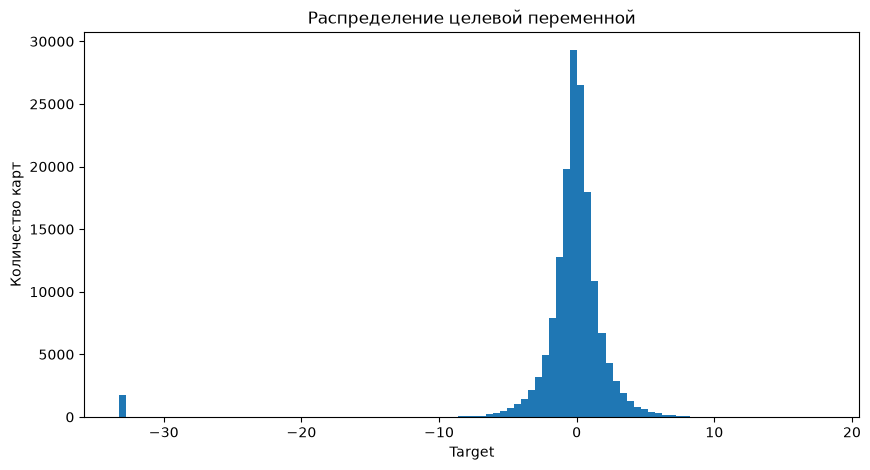

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(
    target,
    bins=100,
)

plt.title("Распределение целевой переменной")
plt.xlabel("Target")
plt.ylabel("Количество карт")
plt.show()

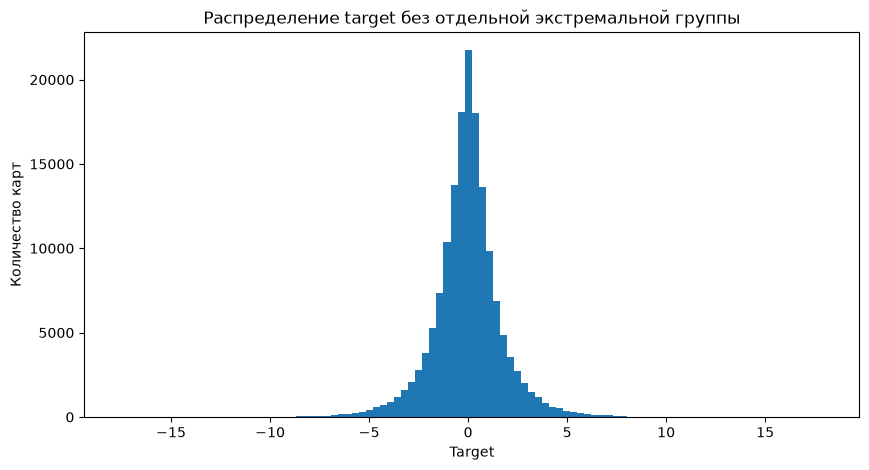

In [19]:
target_without_extreme_group = target.loc[
    ~extreme_target_mask
]

plt.figure(figsize=(10, 5))
plt.hist(
    target_without_extreme_group,
    bins=100,
)

plt.title(
    "Распределение target без отдельной экстремальной группы"
)
plt.xlabel("Target")
plt.ylabel("Количество карт")
plt.show()

Распределение сосредоточено около нуля, но имеет длинный левый хвост. Среднее равно `-0,393`, медиана `-0,023`.

У 1 765 карт значение `target` равно `-33,219281`. Это около 1,09% выборки. Всего значение ниже `-5` имеют 3 232 карты, поэтому левый хвост не ограничивается этой группой.

Экстремальные значения не удаляются. RMSE чувствительна к крупным ошибкам, поэтому долю этой группы нужно сохранять между CV-фолдами

### Исходные категориальные признаки карты

`feature_1`, `feature_2` и `feature_3` - анонимизированные категориальные признаки

Сравним размер категорий, значения `target` и долю экстремальной группы

In [20]:
FEATURE_COLUMNS = [
    "feature_1",
    "feature_2",
    "feature_3",
]


def summarize_categorical_features(
    data: pd.DataFrame,
    feature_columns: list[str],
) -> pd.DataFrame:
    """Формирует сводку по категориальным признакам карты."""
    feature_summaries = []

    for feature_column in feature_columns:
        feature_summary = (
            data.groupby(
                feature_column,
                dropna=False,
            )
            .agg(
                count=("target", "size"),
                target_mean=("target", "mean"),
                target_median=("target", "median"),
                extreme_count=(
                    "target",
                    lambda values: values.eq(
                        extreme_target_value
                    ).sum(),
                ),
            )
            .reset_index()
        )

        feature_summary["share_pct"] = (
            feature_summary["count"]
            / len(data)
            * 100
        )

        feature_summary["extreme_share_pct"] = (
            feature_summary["extreme_count"]
            / feature_summary["count"]
            * 100
        )

        feature_summary["category"] = (
            feature_column
            + " = "
            + feature_summary[
                feature_column
            ].astype(str)
        )

        feature_summaries.append(
            feature_summary[
                [
                    "category",
                    "count",
                    "share_pct",
                    "target_mean",
                    "target_median",
                    "extreme_share_pct",
                ]
            ]
        )

    return pd.concat(
        feature_summaries,
        ignore_index=True,
    )


categorical_feature_summary = (
    summarize_categorical_features(
        train_modeling,
        FEATURE_COLUMNS,
    )
)

categorical_feature_summary

,category,count,share_pct,target_mean,target_median,extreme_share_pct
0,feature_1 = 1,9717,6.015489,-0.315851,-0.001057,0.843882
1,feature_1 = 2,44609,27.616029,-0.345476,0.000000,1.046874
2,feature_1 = 3,58851,36.432803,-0.374713,-0.039430,1.034817
3,feature_1 = 4,15951,9.874762,-0.409553,0.000000,1.084572
4,feature_1 = 5,32405,20.060916,-0.508050,-0.057072,1.339299
5,feature_2 = 1,71510,44.269592,-0.400101,-0.000184,1.142498
6,feature_2 = 2,59932,37.102016,-0.337276,-0.049109,0.891010
7,feature_2 = 3,30091,18.628392,-0.488650,-0.034113,1.375827
8,feature_3 = 0,70277,43.506280,-0.355923,0.000000,1.027363
9,feature_3 = 1,91256,56.493720,-0.422061,-0.047003,1.142939


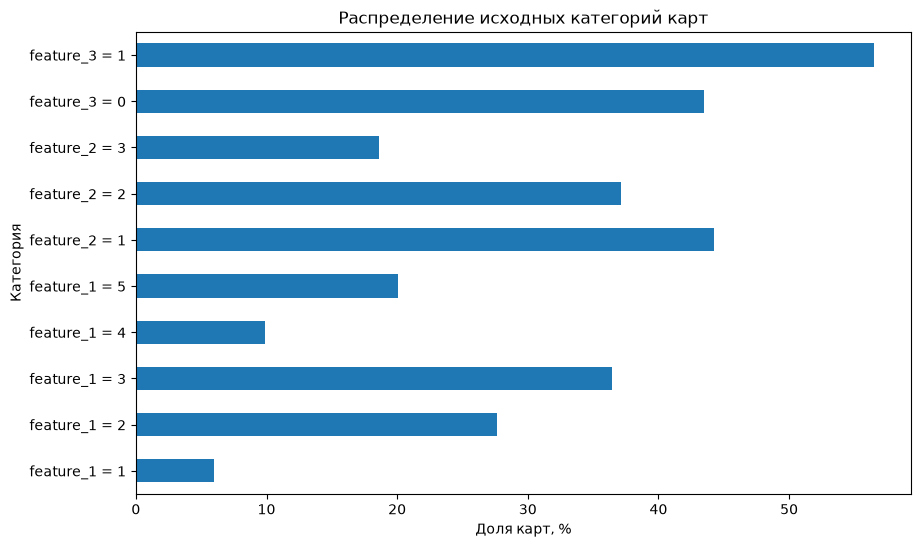

In [21]:
(
    categorical_feature_summary
    .set_index("category")["share_pct"]
    .plot(
        kind="barh",
        figsize=(10, 6),
    )
)

plt.title("Распределение исходных категорий карт")
plt.xlabel("Доля карт, %")
plt.ylabel("Категория")
plt.show()

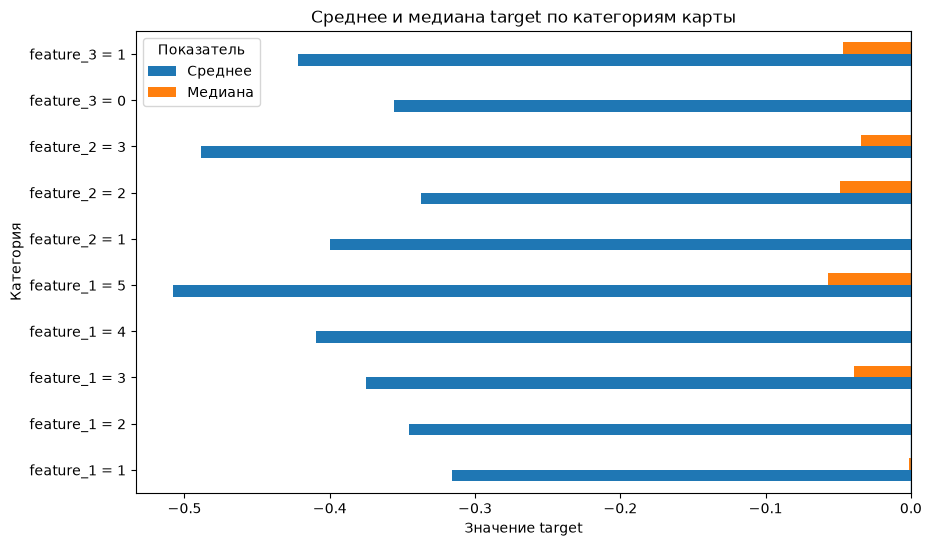

In [22]:
target_by_category = (
    categorical_feature_summary
    .set_index("category")[
        [
            "target_mean",
            "target_median",
        ]
    ]
    .rename(
        columns={
            "target_mean": "Среднее",
            "target_median": "Медиана",
        }
    )
)

target_by_category.plot(
    kind="barh",
    figsize=(10, 6),
)

plt.axvline(
    0,
    linewidth=1,
    label="_nolegend_",
)

plt.title("Среднее и медиана target по категориям карты")
plt.xlabel("Значение target")
plt.ylabel("Категория")
plt.legend(title="Показатель")
plt.show()

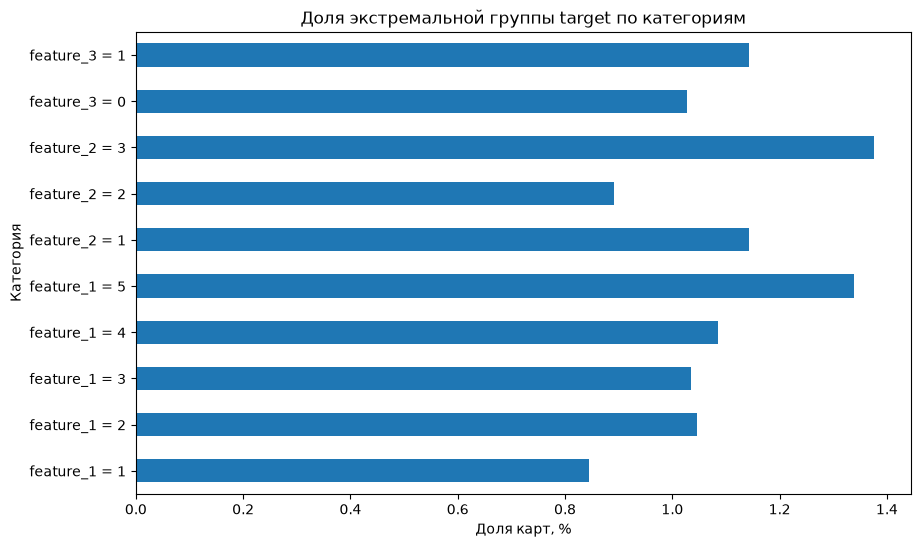

In [23]:
(
    categorical_feature_summary
    .set_index("category")[
        "extreme_share_pct"
    ]
    .plot(
        kind="barh",
        figsize=(10, 6),
    )
)

plt.title(
    "Доля экстремальной группы target по категориям"
)
plt.xlabel("Доля карт, %")
plt.ylabel("Категория")
plt.show()

Категории представлены неравномерно, но очень редких значений нет.

Наиболее заметные различия видны у `feature_1` и `feature_2`. У `feature_3` связь с `target` слабее. Часть различий в средних значениях объясняется разной долей экстремальной группы.

Все три признака сохраняются как категориальные. Их значения являются кодами и не задают порядок категорий.

### Дата первой активности карты

Проверим распределение карт по времени и связь года первой активности с `target`.

Из даты позже создадим год, месяц и длительность активности карты.

In [24]:
active_month_data = train_modeling[
    [
        "first_active_month",
        "target",
    ]
].copy()

active_month_data["first_active_month"] = pd.to_datetime(
    active_month_data["first_active_month"],
    format="%Y-%m",
)

active_month_data["first_active_year"] = (
    active_month_data["first_active_month"].dt.year
)

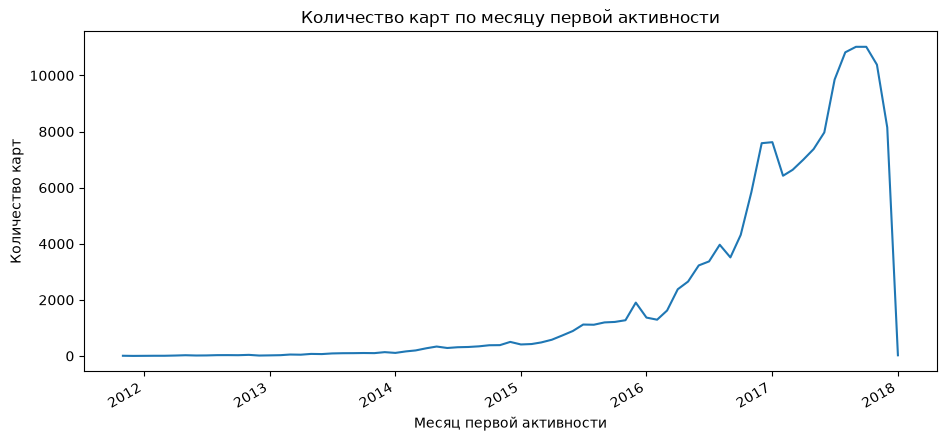

In [25]:
monthly_card_count = (
    active_month_data["first_active_month"]
    .value_counts()
    .sort_index()
)

monthly_card_count.plot(
    figsize=(11, 5),
)

plt.title("Количество карт по месяцу первой активности")
plt.xlabel("Месяц первой активности")
plt.ylabel("Количество карт")
plt.show()

In [26]:
active_year_summary = (
    active_month_data
    .groupby("first_active_year")
    .agg(
        card_count=("target", "size"),
        target_mean=("target", "mean"),
        target_median=("target", "median"),
        extreme_count=(
            "target",
            lambda values: values.eq(
                extreme_target_value
            ).sum(),
        ),
    )
    .reset_index()
)

active_year_summary["extreme_share_pct"] = (
    active_year_summary["extreme_count"]
    / active_year_summary["card_count"]
    * 100
)

active_year_summary

,first_active_year,card_count,target_mean,target_median,extreme_count,extreme_share_pct
0,2011,9,-0.371175,0.135538,0,0.000000
1,2012,230,-1.612183,-0.051402,11,4.782609
2,2013,915,-0.727136,-0.095198,17,1.857923
3,2014,3606,-0.727322,-0.000519,81,2.246256
4,2015,11333,-0.652462,-0.017220,208,1.835348
5,2016,41134,-0.585315,-0.057366,671,1.631254
6,2017,104282,-0.272349,-0.011255,777,0.745095
7,2018,24,0.213947,0.000000,0,0.000000


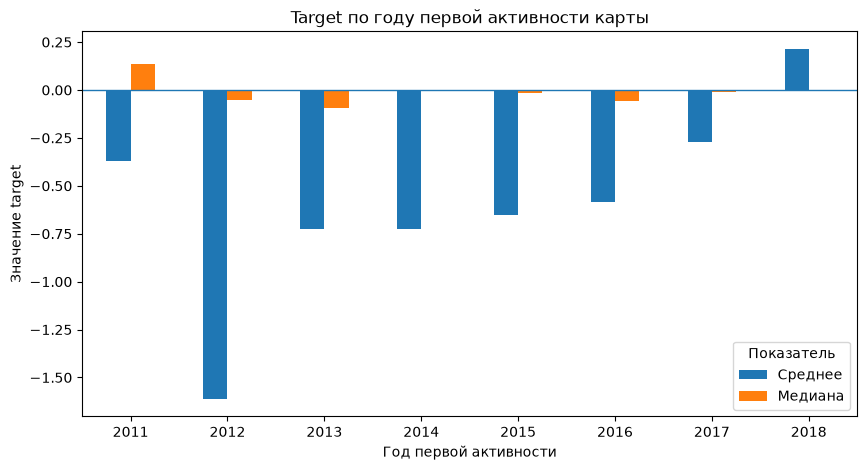

In [27]:
target_by_active_year = (
    active_year_summary
    .set_index("first_active_year")[
        [
            "target_mean",
            "target_median",
        ]
    ]
    .rename(
        columns={
            "target_mean": "Среднее",
            "target_median": "Медиана",
        }
    )
)

target_by_active_year.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.axhline(
    0,
    linewidth=1,
    label="_nolegend_",
)

plt.title("Target по году первой активности карты")
plt.xlabel("Год первой активности")
plt.ylabel("Значение target")
plt.xticks(rotation=0)
plt.legend(title="Показатель")
plt.show()

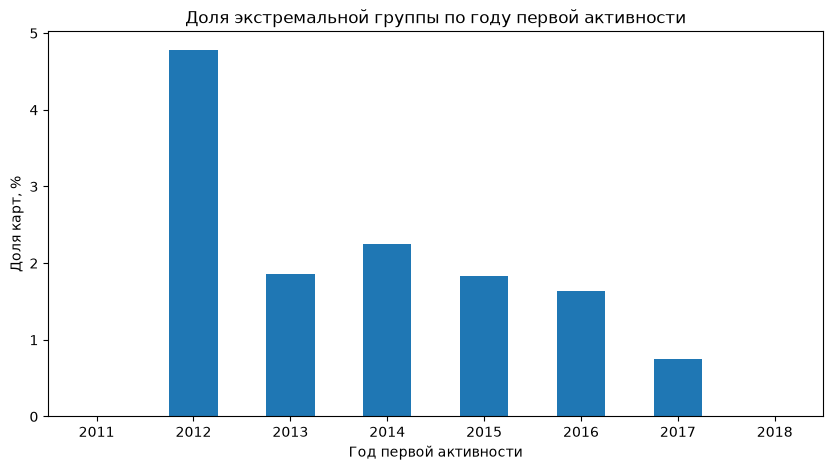

In [28]:
(
    active_year_summary
    .set_index("first_active_year")[
        "extreme_share_pct"
    ]
    .plot(
        kind="bar",
        figsize=(10, 5),
    )
)

plt.title(
    "Доля экстремальной группы по году первой активности"
)
plt.xlabel("Год первой активности")
plt.ylabel("Доля карт, %")
plt.xticks(rotation=0)
plt.show()

Большинство карт впервые активировались в 2016–2017 годах.

Данные за 2011 и 2018 годы слишком малочисленны для выводов. Кроме того, 2018 год представлен не полностью.

У карт с более ранней датой активности средний `target` ниже, но медианы крупных групп остаются близкими к нулю. Часть различий связана с долей экстремальных значений.

Дата первой активности может быть полезна модели, поэтому из неё будут созданы календарные признаки и длительность активности.

### Покрытие карт транзакциями

Проверим, есть ли у карт исторические и новые операции и сколько транзакций приходится на одну карту

In [29]:
TRANSACTION_CHUNK_SIZE = 1_000_000


def count_transactions_by_card(
    file_path: Path,
    selected_card_ids: set[str],
) -> pd.Series:
    """Подсчитывает число транзакций для выбранных карт."""
    transaction_counts = pd.Series(dtype="int64")

    for chunk in pd.read_csv(
        file_path,
        usecols=["card_id"],
        dtype={"card_id": "string"},
        chunksize=TRANSACTION_CHUNK_SIZE,
    ):
        selected_transactions = chunk.loc[
            chunk["card_id"].isin(selected_card_ids),
            "card_id",
        ]

        chunk_counts = selected_transactions.value_counts()

        transaction_counts = transaction_counts.add(
            chunk_counts,
            fill_value=0,
        )

    return transaction_counts.astype("int64")


historical_transaction_counts = count_transactions_by_card(
    DATA_DIR / "historical_transactions.csv",
    train_modeling_card_ids,
)

new_transaction_counts = count_transactions_by_card(
    DATA_DIR / "new_merchant_transactions.csv",
    train_modeling_card_ids,
)

In [30]:
historical_count_per_card = (
    train_modeling["card_id"]
    .map(historical_transaction_counts)
    .fillna(0)
    .astype("int32")
)

new_count_per_card = (
    train_modeling["card_id"]
    .map(new_transaction_counts)
    .fillna(0)
    .astype("int32")
)

In [31]:
def summarize_transaction_coverage(
    transaction_counts: pd.Series,
    period_name: str,
) -> dict[str, float | int | str]:
    """Формирует сводку по покрытию карт транзакциями."""
    cards_with_transactions = (
        transaction_counts.gt(0).sum()
    )

    return {
        "period": period_name,
        "total_transactions": int(
            transaction_counts.sum()
        ),
        "cards_with_transactions": int(
            cards_with_transactions
        ),
        "cards_without_transactions": int(
            transaction_counts.eq(0).sum()
        ),
        "coverage_pct": (
            cards_with_transactions
            / len(transaction_counts)
            * 100
        ),
        "median_transactions": (
            transaction_counts.median()
        ),
        "transactions_q95": (
            transaction_counts.quantile(0.95)
        ),
        "max_transactions": int(
            transaction_counts.max()
        ),
    }


transaction_coverage_summary = pd.DataFrame(
    [
        summarize_transaction_coverage(
            historical_count_per_card,
            "historical",
        ),
        summarize_transaction_coverage(
            new_count_per_card,
            "new",
        ),
    ]
)

transaction_coverage_summary

,period,total_transactions,cards_with_transactions,cards_without_transactions,coverage_pct,median_transactions,transactions_q95,max_transactions
0,historical,14431990,161533,0,100.000000,55.0,290.0,2912
1,new,975602,144026,17507,89.161967,4.0,19.0,109


Все карты из `train_modeling` имеют исторические транзакции.

Новые транзакции есть у 89,16% карт. У остальных 10,84% операций в новом периоде нет, поэтому добавим отдельный признак их наличия.

Исторический период содержит 14,43 млн операций, новый - 975,6 тыс. Медианное число операций на карту составляет 55 и 4 соответственно. Периоды отличаются по длительности, поэтому прямое сравнение количества транзакций дополним относительными признаками.

### Распределение количества транзакций

In [32]:
transaction_count_data = train_modeling[
    [
        "card_id",
        "target",
    ]
].copy()

transaction_count_data[
    "historical_transaction_count"
] = historical_count_per_card.to_numpy()

transaction_count_data[
    "new_transaction_count"
] = new_count_per_card.to_numpy()

transaction_count_data[
    "total_transaction_count"
] = (
    transaction_count_data[
        "historical_transaction_count"
    ]
    + transaction_count_data[
        "new_transaction_count"
    ]
)

transaction_count_data[
    "has_new_transactions"
] = (
    transaction_count_data[
        "new_transaction_count"
    ].gt(0)
)

In [33]:
transaction_count_summary = (
    transaction_count_data[
        [
            "historical_transaction_count",
            "new_transaction_count",
            "total_transaction_count",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

transaction_count_summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
historical_transaction_count,161533.0,89.343911,104.665283,2.0,26.0,55.0,111.0,205.0,290.0,514.0,2912.0
new_transaction_count,161533.0,6.039645,6.655952,0.0,2.0,4.0,8.0,14.0,19.0,31.0,109.0
total_transaction_count,161533.0,95.383556,106.953828,2.0,31.0,60.0,118.0,214.0,300.0,526.0,2915.0


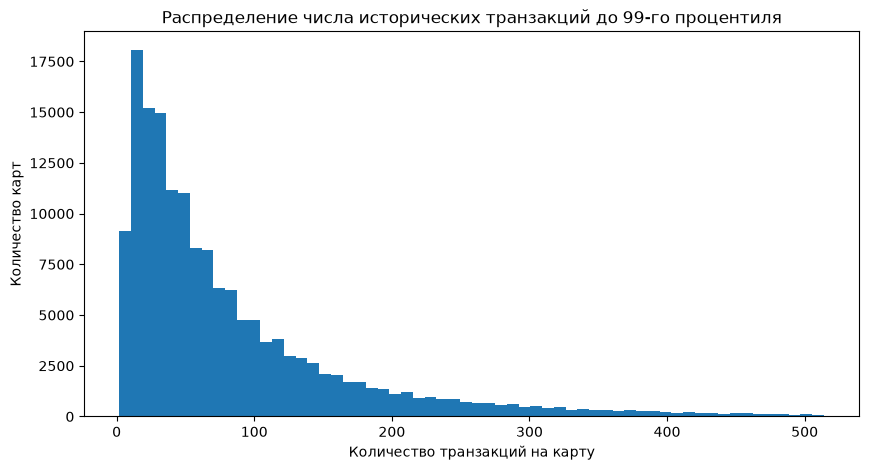

In [34]:
historical_count_limit = (
    transaction_count_data[
        "historical_transaction_count"
    ]
    .quantile(0.99)
)

historical_count_for_plot = transaction_count_data.loc[
    transaction_count_data[
        "historical_transaction_count"
    ].le(historical_count_limit),
    "historical_transaction_count",
]

plt.figure(figsize=(10, 5))

plt.hist(
    historical_count_for_plot,
    bins=60,
)

plt.title(
    "Распределение числа исторических транзакций "
    "до 99-го процентиля"
)
plt.xlabel("Количество транзакций на карту")
plt.ylabel("Количество карт")
plt.show()

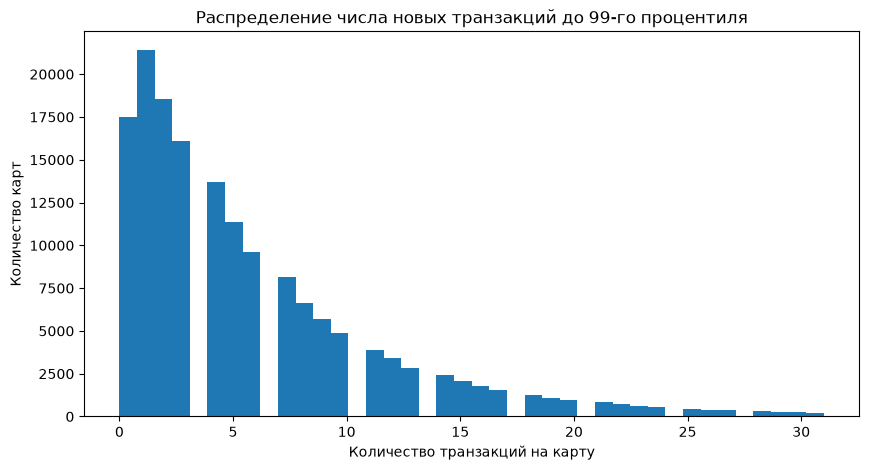

In [35]:
new_count_limit = (
    transaction_count_data[
        "new_transaction_count"
    ]
    .quantile(0.99)
)

new_count_for_plot = transaction_count_data.loc[
    transaction_count_data[
        "new_transaction_count"
    ].le(new_count_limit),
    "new_transaction_count",
]

plt.figure(figsize=(10, 5))

plt.hist(
    new_count_for_plot,
    bins=40,
)

plt.title(
    "Распределение числа новых транзакций "
    "до 99-го процентиля"
)
plt.xlabel("Количество транзакций на карту")
plt.ylabel("Количество карт")
plt.show()

В обоих периодах распределение имеет длинный правый хвост.

В исторических данных медиана равна 55 операциям, 99-й процентиль - 514, максимум - 2 912. В новых данных медиана равна 4, 99-й процентиль - 31, максимум - 109.

Редкие карты с высокой активностью не удаляем: они могут отражать реальное поведение клиентов.

### Связь числа транзакций с target

Сравним `target` и долю экстремальных значений в группах с разным числом операций.

In [36]:
transaction_count_data[
    "historical_count_group"
] = pd.qcut(
    transaction_count_data[
        "historical_transaction_count"
    ],
    q=10,
    duplicates="drop",
)

NEW_TRANSACTION_BINS = [
    -1,
    0,
    2,
    5,
    10,
    20,
    float("inf"),
]

NEW_TRANSACTION_LABELS = [
    "0",
    "1–2",
    "3–5",
    "6–10",
    "11–20",
    "21+",
]

transaction_count_data[
    "new_count_group"
] = pd.cut(
    transaction_count_data[
        "new_transaction_count"
    ],
    bins=NEW_TRANSACTION_BINS,
    labels=NEW_TRANSACTION_LABELS,
    ordered=True,
)

In [37]:
def summarize_target_by_group(
    data: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    """Сравнивает target между группами наблюдений."""
    summary = (
        data.groupby(
            group_column,
            observed=True,
            dropna=False,
        )
        .agg(
            card_count=("target", "size"),
            target_mean=("target", "mean"),
            target_median=("target", "median"),
            extreme_count=(
                "target",
                lambda values: values.eq(
                    extreme_target_value
                ).sum(),
            ),
        )
        .reset_index()
    )

    summary["extreme_share_pct"] = (
        summary["extreme_count"]
        / summary["card_count"]
        * 100
    )

    return summary

In [38]:
historical_count_target_summary = (
    summarize_target_by_group(
        transaction_count_data,
        "historical_count_group",
    )
)

historical_count_target_summary

,historical_count_group,card_count,target_mean,target_median,extreme_count,extreme_share_pct
0,"(1.999, 14.0]",17086,-0.093302,0.043491,114,0.667213
1,"(14.0, 22.0]",16227,-0.246921,0.049341,172,1.059962
2,"(22.0, 31.0]",16131,-0.350713,0.010906,194,1.202653
3,"(31.0, 42.0]",16469,-0.401557,-0.010485,193,1.171899
4,"(42.0, 55.0]",15796,-0.397580,-0.014818,177,1.120537
5,"(55.0, 72.0]",16000,-0.471066,-0.047843,202,1.262500
6,"(72.0, 95.0]",15707,-0.569929,-0.070889,231,1.470682
7,"(95.0, 131.0]",15923,-0.519968,-0.089195,192,1.205803
8,"(131.0, 205.0]",16077,-0.474363,-0.086872,170,1.057411
9,"(205.0, 2912.0]",16117,-0.433232,-0.106905,120,0.744555


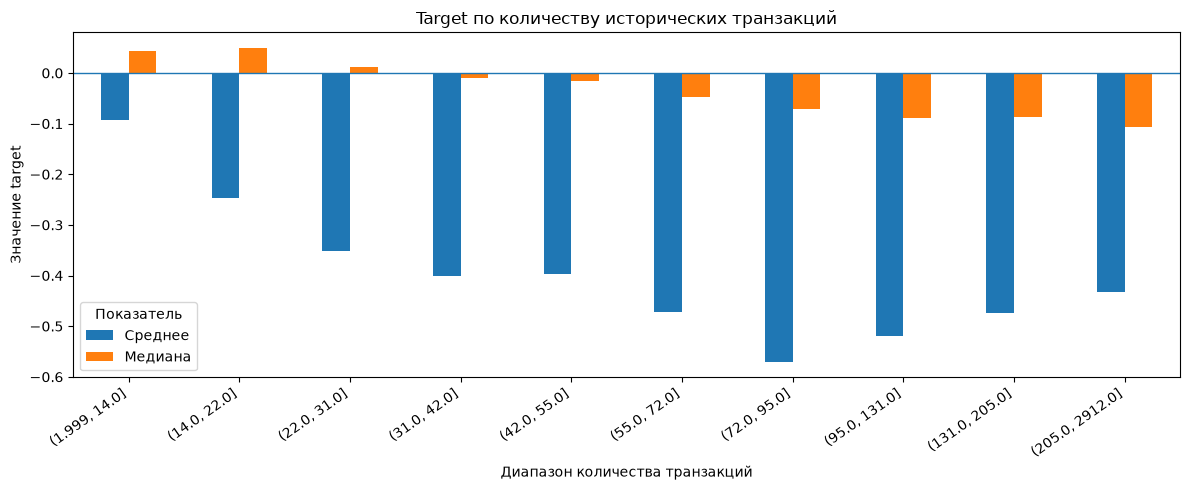

In [39]:
historical_target_plot = (
    historical_count_target_summary
    .set_index("historical_count_group")[
        [
            "target_mean",
            "target_median",
        ]
    ]
    .rename(
        columns={
            "target_mean": "Среднее",
            "target_median": "Медиана",
        }
    )
)

historical_target_plot.plot(
    kind="bar",
    figsize=(12, 5),
)

plt.axhline(
    0,
    linewidth=1,
    label="_nolegend_",
)

plt.title(
    "Target по количеству исторических транзакций"
)
plt.xlabel("Диапазон количества транзакций")
plt.ylabel("Значение target")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Показатель")
plt.tight_layout()
plt.show()

In [40]:
new_count_target_summary = (
    summarize_target_by_group(
        transaction_count_data,
        "new_count_group",
    )
)

new_count_target_summary

,new_count_group,card_count,target_mean,target_median,extreme_count,extreme_share_pct
0,0,17507,-0.008689,0.518445,468,2.673216
1,1–2,39959,-0.140204,0.270726,589,1.474011
2,3–5,41206,-0.466911,-0.041461,367,0.890647
3,6–10,35027,-0.559215,-0.193349,211,0.602392
4,11–20,21273,-0.682293,-0.313088,115,0.540591
5,21+,6561,-0.675613,-0.398392,15,0.228624


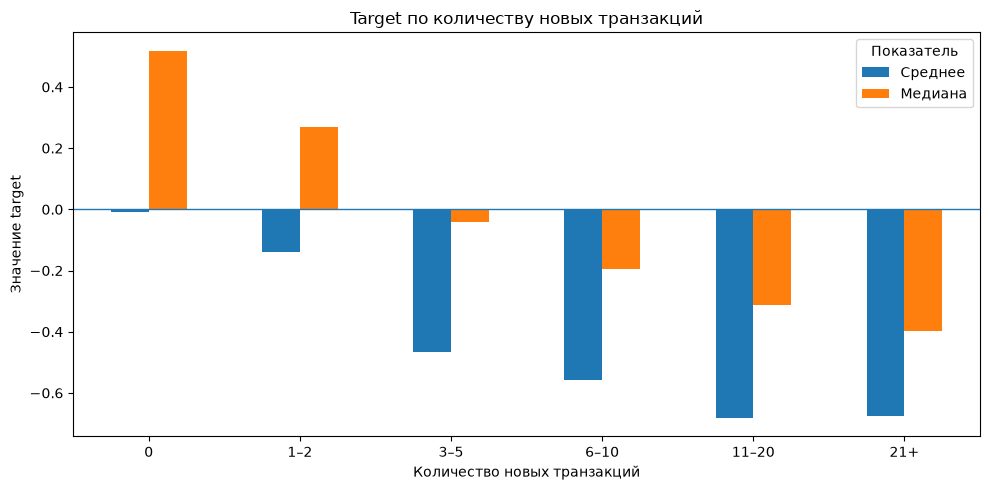

In [41]:
new_target_plot = (
    new_count_target_summary
    .set_index("new_count_group")[
        [
            "target_mean",
            "target_median",
        ]
    ]
    .rename(
        columns={
            "target_mean": "Среднее",
            "target_median": "Медиана",
        }
    )
)

new_target_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.axhline(
    0,
    linewidth=1,
    label="_nolegend_",
)

plt.title(
    "Target по количеству новых транзакций"
)
plt.xlabel("Количество новых транзакций")
plt.ylabel("Значение target")
plt.xticks(rotation=0)
plt.legend(title="Показатель")
plt.tight_layout()
plt.show()

С ростом числа исторических транзакций медиана `target` в целом снижается. Для новых транзакций связь выражена сильнее: медиана меняется от `0,518` у карт без новых операций до `-0,398` у карт с 21 и более операциями.

Одновременно доля минимального значения `target` снижается с 2,67% до 0,23%. Поэтому карты без новых операций образуют неоднородную группу: у большинства `target` сравнительно высокий, но экстремальные значения встречаются чаще.

В признаки включим количество операций, наличие новых транзакций и частоту операций с учётом длительности периода.

### Качество транзакционных данных

Проверим пропуски, специальные значения и основные характеристики транзакций. Анализ проводится только для карт из `train_modeling`.

In [42]:
TRANSACTION_COLUMNS = [
    "authorized_flag",
    "card_id",
    "city_id",
    "category_1",
    "installments",
    "category_3",
    "merchant_category_id",
    "merchant_id",
    "month_lag",
    "purchase_amount",
    "purchase_date",
    "category_2",
    "state_id",
    "subsector_id",
]

TRANSACTION_DTYPES = {
    "authorized_flag": "category",
    "card_id": "string",
    "city_id": "int16",
    "category_1": "category",
    "installments": "int16",
    "category_3": "category",
    "merchant_category_id": "int16",
    "merchant_id": "string",
    "month_lag": "int8",
    "purchase_amount": "float64",
    "category_2": "float32",
    "state_id": "int16",
    "subsector_id": "int16",
}

MINUS_ONE_COLUMNS = [
    "city_id",
    "installments",
    "merchant_category_id",
    "category_2",
    "state_id",
    "subsector_id",
]

NUMERIC_TRANSACTION_COLUMNS = [
    "city_id",
    "installments",
    "merchant_category_id",
    "month_lag",
    "purchase_amount",
    "category_2",
    "state_id",
    "subsector_id",
]

PURCHASE_AMOUNT_QUANTILES = [
    0.000,
    0.001,
    0.010,
    0.250,
    0.500,
    0.750,
    0.990,
    0.999,
    1.000,
]

PURCHASE_SAMPLE_SIZE = 100_000

In [43]:
def profile_and_aggregate_transactions(
    file_path: Path,
    selected_card_ids: set[str],
) -> dict[str, object]:
    """Проверяет транзакции и агрегирует их до уровня карты."""
    missing_counts = pd.Series(
        0,
        index=TRANSACTION_COLUMNS,
        dtype="int64",
    )
    minus_one_counts = pd.Series(
        0,
        index=MINUS_ONE_COLUMNS,
        dtype="int64",
    )
    infinite_counts = pd.Series(
        0,
        index=NUMERIC_TRANSACTION_COLUMNS,
        dtype="int64",
    )

    authorized_counts = pd.Series(dtype="int64")
    installments_counts = pd.Series(dtype="int64")
    month_lag_counts = pd.Series(dtype="int64")

    partial_card_aggregates = []
    purchase_amount_parts = []

    total_transactions = 0
    purchase_date_min = pd.NaT
    purchase_date_max = pd.NaT

    for chunk in pd.read_csv(
        file_path,
        usecols=TRANSACTION_COLUMNS,
        dtype=TRANSACTION_DTYPES,
        parse_dates=["purchase_date"],
        chunksize=TRANSACTION_CHUNK_SIZE,
    ):
        selected_transactions = chunk.loc[
            chunk["card_id"].isin(selected_card_ids)
        ].copy()

        if selected_transactions.empty:
            continue

        chunk_size = len(selected_transactions)
        total_transactions += chunk_size

        missing_counts = missing_counts.add(
            selected_transactions.isna().sum(),
            fill_value=0,
        )

        minus_one_counts = minus_one_counts.add(
            selected_transactions[
                MINUS_ONE_COLUMNS
            ].eq(-1).sum(),
            fill_value=0,
        )

        infinite_counts = infinite_counts.add(
            np.isinf(
                selected_transactions[
                    NUMERIC_TRANSACTION_COLUMNS
                ]
            ).sum(),
            fill_value=0,
        )

        authorized_counts = authorized_counts.add(
            selected_transactions[
                "authorized_flag"
            ]
            .astype("string")
            .fillna("Пропуск")
            .value_counts(),
            fill_value=0,
        )

        installments_counts = installments_counts.add(
            selected_transactions[
                "installments"
            ].value_counts(),
            fill_value=0,
        )

        month_lag_counts = month_lag_counts.add(
            selected_transactions[
                "month_lag"
            ].value_counts(),
            fill_value=0,
        )

        purchase_amount = (
            selected_transactions["purchase_amount"]
            .to_numpy(
               dtype="float64",
                copy=True,
            )
        )

        purchase_amount_parts.append(
            purchase_amount
        )

        chunk_date_min = selected_transactions[
            "purchase_date"
        ].min()
        chunk_date_max = selected_transactions[
            "purchase_date"
        ].max()

        if pd.isna(purchase_date_min):
            purchase_date_min = chunk_date_min
            purchase_date_max = chunk_date_max
        else:
            purchase_date_min = min(
                purchase_date_min,
                chunk_date_min,
            )
            purchase_date_max = max(
                purchase_date_max,
                chunk_date_max,
            )

        selected_transactions[
            "_purchase_amount"
        ] = selected_transactions[
            "purchase_amount"
        ].astype("float64")

        selected_transactions[
            "_purchase_amount_squared"
        ] = selected_transactions[
            "_purchase_amount"
        ].pow(2)

        selected_transactions[
            "_is_authorized"
        ] = selected_transactions[
            "authorized_flag"
        ].eq("Y").astype("int8")

        selected_transactions[
            "_merchant_id_missing"
        ] = selected_transactions[
            "merchant_id"
        ].isna().astype("int8")

        chunk_card_aggregates = (
            selected_transactions.groupby(
                "card_id",
                sort=False,
            )
            .agg(
                transaction_count=(
                    "_purchase_amount",
                    "size",
                ),
                purchase_amount_sum=(
                    "_purchase_amount",
                    "sum",
                ),
                purchase_amount_min=(
                    "_purchase_amount",
                    "min",
                ),
                purchase_amount_max=(
                    "_purchase_amount",
                    "max",
                ),
                purchase_amount_sumsq=(
                    "_purchase_amount_squared",
                    "sum",
                ),
                authorized_count=(
                    "_is_authorized",
                    "sum",
                ),
                merchant_id_missing_count=(
                    "_merchant_id_missing",
                    "sum",
                ),
                month_lag_sum=(
                    "month_lag",
                    "sum",
                ),
                month_lag_min=(
                    "month_lag",
                    "min",
                ),
                month_lag_max=(
                    "month_lag",
                    "max",
                ),
                purchase_date_min=(
                    "purchase_date",
                    "min",
                ),
                purchase_date_max=(
                    "purchase_date",
                    "max",
                ),
            )
        )

        partial_card_aggregates.append(
            chunk_card_aggregates
        )

    combined_card_aggregates = pd.concat(
        partial_card_aggregates
    )

    card_aggregates = (
        combined_card_aggregates
        .groupby(level=0)
        .agg(
            transaction_count=(
                "transaction_count",
                "sum",
            ),
            purchase_amount_sum=(
                "purchase_amount_sum",
                "sum",
            ),
            purchase_amount_min=(
                "purchase_amount_min",
                "min",
            ),
            purchase_amount_max=(
                "purchase_amount_max",
                "max",
            ),
            purchase_amount_sumsq=(
                "purchase_amount_sumsq",
                "sum",
            ),
            authorized_count=(
                "authorized_count",
                "sum",
            ),
            merchant_id_missing_count=(
                "merchant_id_missing_count",
                "sum",
            ),
            month_lag_sum=(
                "month_lag_sum",
                "sum",
            ),
            month_lag_min=(
                "month_lag_min",
                "min",
            ),
            month_lag_max=(
                "month_lag_max",
                "max",
            ),
            purchase_date_min=(
                "purchase_date_min",
                "min",
            ),
            purchase_date_max=(
                "purchase_date_max",
                "max",
            ),
        )
    )

    card_aggregates[
        "purchase_amount_mean"
    ] = (
        card_aggregates["purchase_amount_sum"]
        / card_aggregates["transaction_count"]
    )

    variance_numerator = (
        card_aggregates["purchase_amount_sumsq"]
        - (
            card_aggregates[
                "purchase_amount_sum"
            ].pow(2)
            / card_aggregates["transaction_count"]
        )
    )

    card_aggregates[
        "purchase_amount_std"
    ] = np.sqrt(
        (
            variance_numerator
            / (
                card_aggregates[
                    "transaction_count"
                ]
                - 1
            )
        ).clip(lower=0)
    )

    card_aggregates.loc[
        card_aggregates[
            "transaction_count"
        ].eq(1),
        "purchase_amount_std",
    ] = np.nan

    card_aggregates[
        "authorized_share"
    ] = (
        card_aggregates["authorized_count"]
        / card_aggregates["transaction_count"]
    )

    card_aggregates[
        "merchant_id_missing_share"
    ] = (
        card_aggregates[
            "merchant_id_missing_count"
        ]
        / card_aggregates["transaction_count"]
    )

    card_aggregates[
        "month_lag_mean"
    ] = (
        card_aggregates["month_lag_sum"]
        / card_aggregates["transaction_count"]
    )

    card_aggregates[
        "transaction_period_days"
    ] = (
        card_aggregates["purchase_date_max"]
        - card_aggregates["purchase_date_min"]
    ).dt.days

    all_purchase_amounts = np.concatenate(
        purchase_amount_parts
    )

    purchase_amount_sample = (
        pd.Series(
            all_purchase_amounts,
            name="purchase_amount",
        )
        .sample(
            n=min(
                PURCHASE_SAMPLE_SIZE,
                len(all_purchase_amounts),
            ),
            random_state=RANDOM_STATE,
        )
        .reset_index(drop=True)
    )

    purchase_amount_quantiles = pd.Series(
        np.quantile(
            all_purchase_amounts,
            PURCHASE_AMOUNT_QUANTILES,
        ),
        index=PURCHASE_AMOUNT_QUANTILES,
        name="purchase_amount",
    ).rename_axis("quantile").to_frame()

    missing_summary = pd.DataFrame(
        {
            "missing_count": missing_counts,
            "missing_share_pct": (
                missing_counts
                / total_transactions
                * 100
            ),
        }
    )

    missing_summary = missing_summary.loc[
        missing_summary["missing_count"].gt(0)
    ]

    special_values_summary = pd.DataFrame(
        {
            "minus_one_count": minus_one_counts,
            "minus_one_share_pct": (
                minus_one_counts
                / total_transactions
                * 100
            ),
        }
    )

    infinite_summary = pd.DataFrame(
        {
            "infinite_count": infinite_counts,
            "infinite_share_pct": (
                infinite_counts
                / total_transactions
                * 100
            ),
        }
    )

    infinite_summary = infinite_summary.loc[
        infinite_summary["infinite_count"].gt(0)
    ]

    overview = pd.Series(
        {
            "transactions": total_transactions,
            "cards": len(card_aggregates),
            "purchase_date_min": purchase_date_min,
            "purchase_date_max": purchase_date_max,
        },
        name="value",
    ).to_frame()

    return {
        "overview": overview,
        "missing_summary": missing_summary,
        "special_values_summary": (
            special_values_summary
        ),
        "infinite_summary": infinite_summary,
        "authorized_counts": (
            authorized_counts
            .astype("int64")
            .sort_index()
            .rename("count")
            .to_frame()
        ),
        "installments_counts": (
            installments_counts
            .astype("int64")
            .sort_index()
            .rename("count")
            .to_frame()
        ),
        "month_lag_counts": (
            month_lag_counts
            .astype("int64")
            .sort_index()
            .rename("count")
            .to_frame()
        ),
        "purchase_amount_quantiles": (
            purchase_amount_quantiles
        ),
        "purchase_amount_sample": purchase_amount_sample,
        "card_aggregates": card_aggregates,
    }

In [44]:
historical_transaction_profile = (
    profile_and_aggregate_transactions(
        DATA_DIR / "historical_transactions.csv",
        train_modeling_card_ids,
    )
)

new_transaction_profile = (
    profile_and_aggregate_transactions(
        DATA_DIR / "new_merchant_transactions.csv",
        train_modeling_card_ids,
    )
)

In [45]:
display(
    historical_transaction_profile["overview"]
)
display(
    new_transaction_profile["overview"]
)

display(
    historical_transaction_profile[
        "missing_summary"
    ]
)
display(
    new_transaction_profile[
        "missing_summary"
    ]
)

display(
    historical_transaction_profile[
        "special_values_summary"
    ]
)
display(
    new_transaction_profile[
        "special_values_summary"
    ]
)

transaction_infinite_check = pd.DataFrame(
    {
        "period": [
            "historical",
            "new",
        ],
        "infinite_count": [
            historical_transaction_profile[
                "infinite_summary"
            ]["infinite_count"].sum(),
            new_transaction_profile[
                "infinite_summary"
            ]["infinite_count"].sum(),
        ],
    }
)

display(transaction_infinite_check)

display(
    historical_transaction_profile[
        "purchase_amount_quantiles"
    ]
)
display(
    new_transaction_profile[
        "purchase_amount_quantiles"
    ]
)

,value
transactions,14431990
cards,161533
purchase_date_min,2017-01-01 00:00:08
purchase_date_max,2018-02-28 23:59:51


,value
transactions,975602
cards,144026
purchase_date_min,2017-03-01 03:24:51
purchase_date_max,2018-04-30 23:59:15


,missing_count,missing_share_pct
category_3,88454,0.612902
merchant_id,68953,0.477779
category_2,1310955,9.083675


,missing_count,missing_share_pct
category_3,27870,2.856698
merchant_id,12961,1.328513
category_2,55243,5.662453


,minus_one_count,minus_one_share_pct
city_id,1225760,8.493354
installments,88454,0.612902
merchant_category_id,1134,0.007858
category_2,0,0.000000
state_id,1310955,9.083675
subsector_id,1134,0.007858


,minus_one_count,minus_one_share_pct
city_id,49227,5.045808
installments,27870,2.856698
merchant_category_id,9,0.000923
category_2,0,0.000000
state_id,55243,5.662453
subsector_id,9,0.000923


,period,infinite_count
0,historical,0
1,new,0


,purchase_amount
quantile,
0.000,-7.469078e-01
0.001,-7.460062e-01
0.010,-7.432564e-01
0.250,-7.204611e-01
0.500,-6.884847e-01
0.750,-6.033595e-01
0.990,1.225657e+00
0.999,6.766348e+00
1.000,6.010604e+06


,purchase_amount
quantile,
0.000,-0.746893
0.001,-0.746156
0.010,-0.742400
0.250,-0.716810
0.500,-0.675081
0.750,-0.581766
0.990,1.461989
0.999,6.821473
1.000,76.682904


Пропуски есть только в `category_2`, `category_3` и `merchant_id`.

Доля пропусков в историческом и новом периодах:

- `category_2` - 9,08% и 5,66%
- `category_3` - 0,61% и 2,86%
- `merchant_id` - 0,48% и 1,33%

Число пропусков в `category_2` и `category_3` совпадает с числом специальных значений в связанных признаках, но это не доказывает совпадение строк. Поэтому признаки обрабатываются отдельно.

В исторических данных одобрено 91,32% операций, отклонено 8,68%. Все новые операции одобрены, поэтому признаки отказов создаются только для исторического периода.

Бесконечных значений нет.

`purchase_amount` нормализован, поэтому отрицательные значения допустимы. В исторических данных есть одно крайне большое значение около 6,01 млн. Оно не удаляется, но его влияние проверяется отдельно.

Исторический и новый периоды могут пересекаться по календарным датам. Их разделяет `month_lag`, а не единая дата

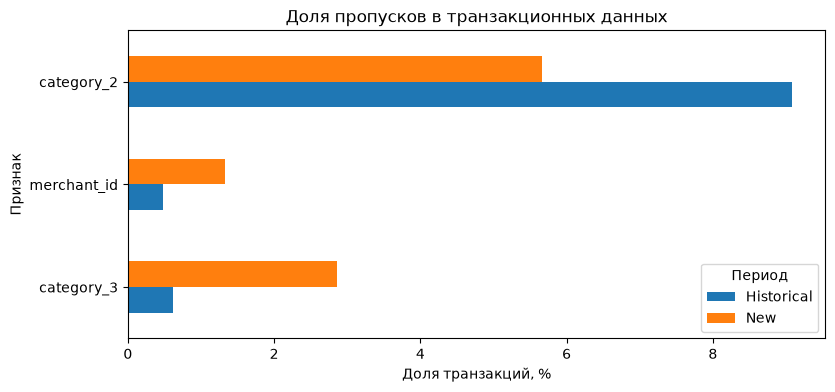

In [46]:
missing_share_comparison = pd.concat(
    [
        historical_transaction_profile[
            "missing_summary"
        ]["missing_share_pct"].rename("Historical"),
        new_transaction_profile[
            "missing_summary"
        ]["missing_share_pct"].rename("New"),
    ],
    axis=1,
).fillna(0)

missing_share_comparison.plot(
    kind="barh",
    figsize=(9, 4),
)

plt.title("Доля пропусков в транзакционных данных")
plt.xlabel("Доля транзакций, %")
plt.ylabel("Признак")
plt.legend(title="Период")
plt.show()

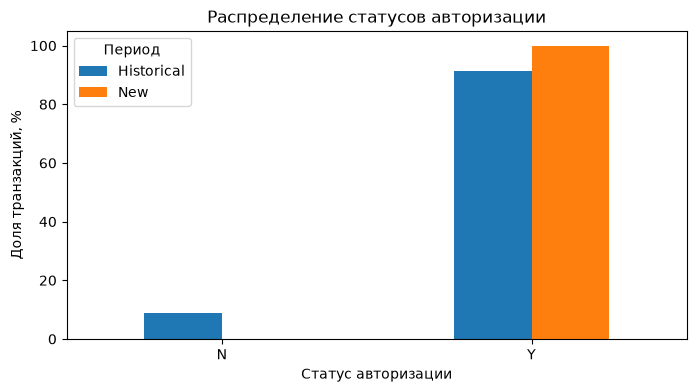

In [47]:
authorization_share = pd.concat(
    [
        historical_transaction_profile[
            "authorized_counts"
        ]["count"].rename("Historical"),
        new_transaction_profile[
            "authorized_counts"
        ]["count"].rename("New"),
    ],
    axis=1,
).fillna(0)

authorization_share = (
    authorization_share
    .div(authorization_share.sum(axis=0), axis=1)
    .mul(100)
)

authorization_share.plot(
    kind="bar",
    figsize=(8, 4),
)

plt.title("Распределение статусов авторизации")
plt.xlabel("Статус авторизации")
plt.ylabel("Доля транзакций, %")
plt.xticks(rotation=0)
plt.legend(title="Период")
plt.show()

### Month_lag и рассрочка

In [48]:
month_lag_share = pd.concat(
    [
        historical_transaction_profile[
            "month_lag_counts"
        ]["count"].rename("Historical"),
        new_transaction_profile[
            "month_lag_counts"
        ]["count"].rename("New"),
    ],
    axis=1,
).fillna(0)

month_lag_share = (
    month_lag_share
    .div(month_lag_share.sum(axis=0), axis=1)
    .mul(100)
    .sort_index()
)

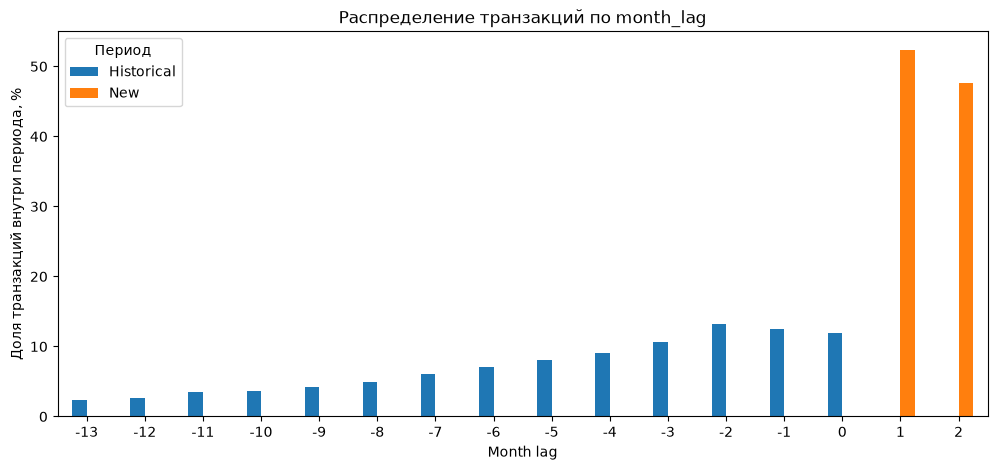

In [49]:
month_lag_share.plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Распределение транзакций по month_lag")
plt.xlabel("Month lag")
plt.ylabel("Доля транзакций внутри периода, %")
plt.xticks(rotation=0)
plt.legend(title="Период")
plt.show()

In [50]:
installments_share = pd.concat(
    [
        historical_transaction_profile[
            "installments_counts"
        ]["count"].rename("Historical"),
        new_transaction_profile[
            "installments_counts"
        ]["count"].rename("New"),
    ],
    axis=1,
).fillna(0)

installments_share = (
    installments_share
    .div(installments_share.sum(axis=0), axis=1)
    .mul(100)
    .sort_index()
)

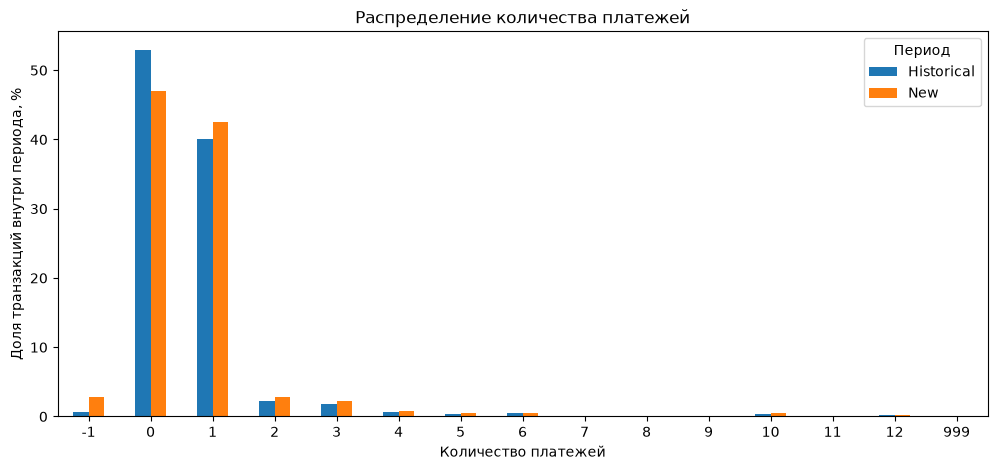

In [51]:
installments_share.plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Распределение количества платежей")
plt.xlabel("Количество платежей")
plt.ylabel("Доля транзакций внутри периода, %")
plt.xticks(rotation=0)
plt.legend(title="Период")
plt.show()

Исторические транзакции имеют `month_lag` от `-13` до `0`, новые - `1` и `2`.

Около половины исторических операций приходится на последние четыре месяца. В новом периоде операции распределены между двумя месяцами почти поровну.

Большинство покупок сделано без рассрочки или с одним платежом. Значения `-1` и `999` считаются специальными.

Для каждой карты создадим временные агрегаты и доли операций по типу рассрочки.

### Распределение суммы покупки

`purchase_amount` - нормализованный показатель с длинным правым хвостом.

Для графика ограничим диапазон 0,1-м и 99,9-м процентилями. Исходные значения при этом не удаляются.

In [52]:
historical_amount_sample = (
    historical_transaction_profile[
        "purchase_amount_sample"
    ]
)

new_amount_sample = (
    new_transaction_profile[
        "purchase_amount_sample"
    ]
)

historical_amount_limits = (
    historical_transaction_profile[
        "purchase_amount_quantiles"
    ]["purchase_amount"]
)

new_amount_limits = (
    new_transaction_profile[
        "purchase_amount_quantiles"
    ]["purchase_amount"]
)

historical_amount_for_plot = historical_amount_sample.loc[
    historical_amount_sample.between(
        historical_amount_limits.loc[0.001],
        historical_amount_limits.loc[0.999],
    )
]

new_amount_for_plot = new_amount_sample.loc[
    new_amount_sample.between(
        new_amount_limits.loc[0.001],
        new_amount_limits.loc[0.999],
    )
]

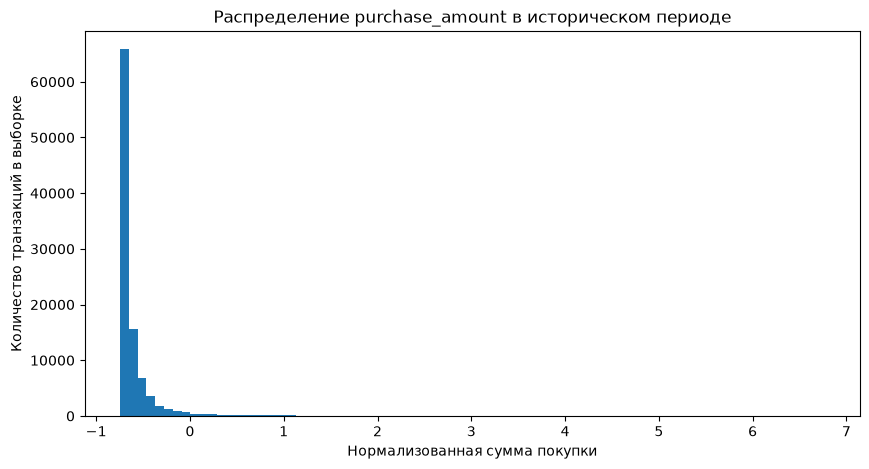

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    historical_amount_for_plot,
    bins=80,
)

plt.title(
    "Распределение purchase_amount в историческом периоде"
)
plt.xlabel("Нормализованная сумма покупки")
plt.ylabel("Количество транзакций в выборке")
plt.show()

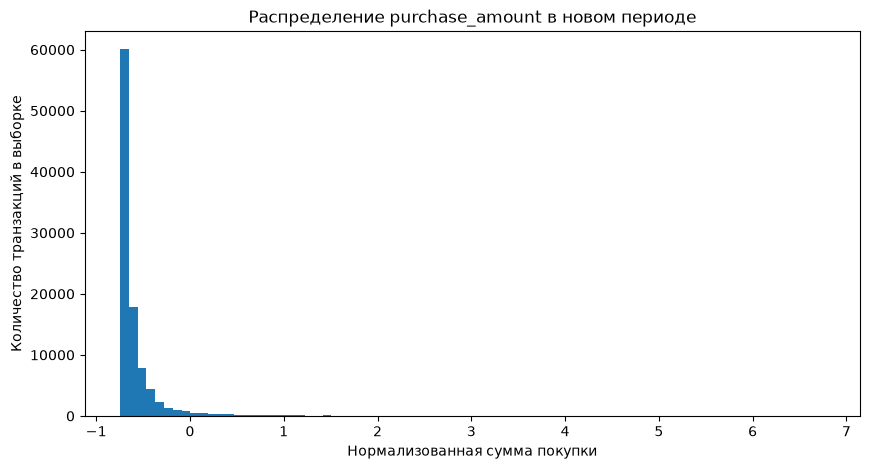

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(
    new_amount_for_plot,
    bins=80,
)

plt.title(
    "Распределение purchase_amount в новом периоде"
)
plt.xlabel("Нормализованная сумма покупки")
plt.ylabel("Количество транзакций в выборке")
plt.show()

In [55]:
historical_card_aggregates = (
    historical_transaction_profile[
        "card_aggregates"
    ]
)

new_card_aggregates = (
    new_transaction_profile[
        "card_aggregates"
    ]
)

historical_extreme_threshold = (
    historical_amount_limits.loc[0.999]
)

new_extreme_threshold = (
    new_amount_limits.loc[0.999]
)

extreme_amount_summary = pd.DataFrame(
    {
        "period": [
            "historical",
            "new",
        ],
        "transaction_threshold_99_9": [
            historical_extreme_threshold,
            new_extreme_threshold,
        ],
        "cards_above_threshold": [
            historical_card_aggregates[
                "purchase_amount_max"
            ].gt(historical_extreme_threshold).sum(),
            new_card_aggregates[
                "purchase_amount_max"
            ].gt(new_extreme_threshold).sum(),
        ],
        "maximum_transaction": [
            historical_card_aggregates[
                "purchase_amount_max"
            ].max(),
            new_card_aggregates[
                "purchase_amount_max"
            ].max(),
        ],
        "maximum_card_sum": [
            historical_card_aggregates[
                "purchase_amount_sum"
            ].max(),
            new_card_aggregates[
                "purchase_amount_sum"
            ].max(),
        ],
    }
)

extreme_amount_summary[
    "cards_above_threshold_share_pct"
] = (
    extreme_amount_summary[
        "cards_above_threshold"
    ]
    / [
        len(historical_card_aggregates),
        len(new_card_aggregates),
    ]
    * 100
)

extreme_amount_summary

,period,transaction_threshold_99_9,cards_above_threshold,maximum_transaction,maximum_card_sum,cards_above_threshold_share_pct
0,historical,6.766348,6186,6.010604e+06,6.010596e+06,3.829558
1,new,6.821473,898,7.668290e+01,1.090862e+02,0.623499


In [56]:
largest_historical_amounts = (
    historical_card_aggregates[
        "purchase_amount_max"
    ]
    .nlargest(2)
    .to_numpy()
)

historical_amount_outlier_check = pd.Series(
    {
        "Максимальное значение": (
            largest_historical_amounts[0]
        ),
        "Второе по величине значение": (
            largest_historical_amounts[1]
        ),
        "Отношение максимума ко второму значению": (
            largest_historical_amounts[0]
            / largest_historical_amounts[1]
        ),
    },
    name="Значение",
).to_frame()

historical_amount_outlier_check

,Значение
Максимальное значение,6.010604e+06
Второе по величине значение,1.652987e+05
Отношение максимума ко второму значению,3.636207e+01


В обоих периодах большинство значений `purchase_amount` сосредоточено в узком диапазоне, но есть редкие крупные операции.

Максимальное историческое значение около 6,01 млн более чем в 30 раз превышает следующее. Для одной карты такая операция почти полностью определяет денежные агрегаты.

Наблюдение не удаляем, так как нельзя уверенно считать его ошибкой. Более устойчивые денежные признаки остаются возможным направлением улучшения.

### Связь крупных операций с target

Сравним `target` у карт с разным максимальным значением `purchase_amount`. Группы используются только для EDA.

In [57]:
historical_amount_target_data = (
    train_modeling[
        [
            "card_id",
            "target",
        ]
    ]
    .merge(
        historical_card_aggregates[
            [
                "purchase_amount_sum",
                "purchase_amount_mean",
                "purchase_amount_max",
                "purchase_amount_std",
            ]
        ],
        left_on="card_id",
        right_index=True,
        how="left",
        validate="one_to_one",
    )
)

historical_amount_target_data[
    "maximum_amount_group"
] = pd.cut(
    historical_amount_target_data[
        "purchase_amount_max"
    ],
    bins=[
        float("-inf"),
        historical_amount_limits.loc[0.990],
        historical_amount_limits.loc[0.999],
        float("inf"),
    ],
    labels=[
        "До 99-го процентиля",
        "От 99-го до 99,9-го",
        "Выше 99,9-го процентиля",
    ],
    include_lowest=True,
)

In [58]:
historical_amount_target_summary = (
    historical_amount_target_data
    .groupby(
        "maximum_amount_group",
        observed=True,
    )
    .agg(
        card_count=("target", "size"),
        target_mean=("target", "mean"),
        target_median=("target", "median"),
        extreme_count=(
            "target",
            lambda values: values.eq(
                extreme_target_value
            ).sum(),
        ),
    )
    .reset_index()
)

historical_amount_target_summary[
    "extreme_share_pct"
] = (
    historical_amount_target_summary[
        "extreme_count"
    ]
    / historical_amount_target_summary[
        "card_count"
    ]
    * 100
)

historical_amount_target_summary

,maximum_amount_group,card_count,target_mean,target_median,extreme_count,extreme_share_pct
0,До 99-го процентиля,120299,-0.382040,-0.018439,1303,1.083135
1,"От 99-го до 99,9-го",35048,-0.425118,-0.041410,391,1.115613
2,"Выше 99,9-го процентиля",6186,-0.431660,-0.009970,71,1.147753


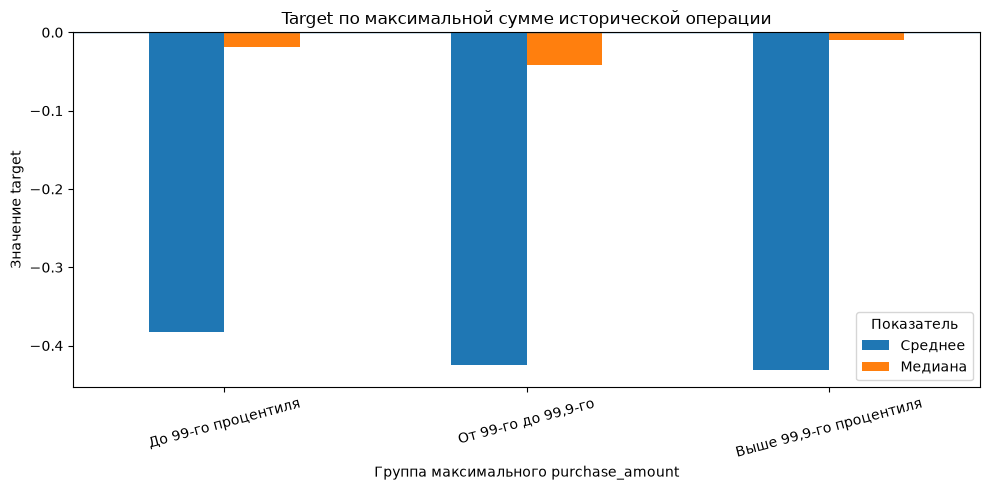

In [59]:
amount_target_plot = (
    historical_amount_target_summary
    .set_index("maximum_amount_group")[
        [
            "target_mean",
            "target_median",
        ]
    ]
    .rename(
        columns={
            "target_mean": "Среднее",
            "target_median": "Медиана",
        }
    )
)

amount_target_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.axhline(
    0,
    linewidth=1,
    label="_nolegend_",
)

plt.title(
    "Target по максимальной сумме исторической операции"
)
plt.xlabel("Группа максимального purchase_amount")
plt.ylabel("Значение target")
plt.xticks(rotation=15)
plt.legend(title="Показатель")
plt.tight_layout()
plt.show()

Максимальная сумма операции слабо связана с `target`: медианы групп близки к нулю, а доля минимального значения почти не меняется.

Главная проблема крупных операций - их сильное влияние на сумму, среднее, максимум и стандартное отклонение.

Жёсткие группы по процентилям в модель не добавляем. Позже проверим медиану, квантили и преобразованные денежные признаки

### Временные характеристики транзакций

Проверим длительность активности карты и давность последних операций.

In [60]:
historical_temporal_features = (
    historical_card_aggregates[
        [
            "month_lag_min",
            "month_lag_max",
            "month_lag_mean",
            "transaction_period_days",
        ]
    ]
    .add_prefix("historical_")
)

new_temporal_features = (
    new_card_aggregates[
        [
            "month_lag_min",
            "month_lag_max",
            "month_lag_mean",
            "transaction_period_days",
        ]
    ]
    .add_prefix("new_")
)

temporal_feature_data = (
    train_modeling[
        [
            "card_id",
            "target",
        ]
    ]
    .merge(
        historical_temporal_features,
        left_on="card_id",
        right_index=True,
        how="left",
        validate="one_to_one",
    )
    .merge(
        new_temporal_features,
        left_on="card_id",
        right_index=True,
        how="left",
        validate="one_to_one",
    )
)

In [61]:
temporal_columns = [
    "historical_month_lag_min",
    "historical_month_lag_max",
    "historical_month_lag_mean",
    "historical_transaction_period_days",
    "new_month_lag_min",
    "new_month_lag_max",
    "new_month_lag_mean",
    "new_transaction_period_days",
]

temporal_feature_summary = (
    temporal_feature_data[
        temporal_columns
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

temporal_feature_summary["missing"] = (
    temporal_feature_data[
        temporal_columns
    ]
    .isna()
    .sum()
)

temporal_feature_summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing
historical_month_lag_min,161533.0,-7.880743,3.845598,-13.000000,-12.000000,-8.000000,-4.000000,-3.000000,-2.000000,-2.000,-1.000000,0
historical_month_lag_max,161533.0,-0.166740,0.640597,-11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0
historical_month_lag_mean,161533.0,-3.842982,2.123653,-12.452381,-5.525424,-3.574627,-2.037975,-1.212121,-0.916667,-0.525,-0.022222,0
historical_transaction_period_days,161533.0,243.755654,118.371538,1.000000,138.000000,233.000000,361.000000,409.000000,417.000000,422.000,423.000000,0
new_month_lag_min,144026.0,1.158721,0.365417,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000,2.000000,17507
new_month_lag_max,144026.0,1.815040,0.388266,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000,2.000000,17507
new_month_lag_mean,144026.0,1.476478,0.330962,1.000000,1.230769,1.500000,1.714286,2.000000,2.000000,2.000,2.000000,17507
new_transaction_period_days,144026.0,29.029029,20.079172,0.000000,8.000000,32.000000,47.000000,55.000000,57.000000,59.000,61.000000,17507


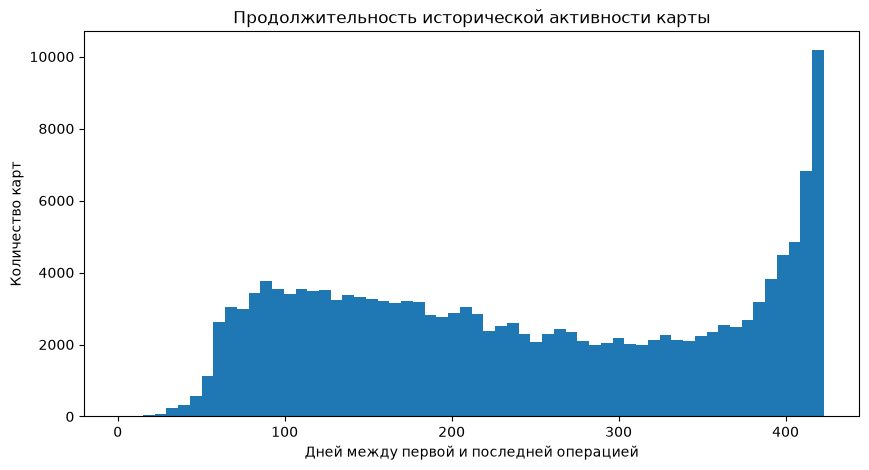

In [62]:
plt.figure(figsize=(10, 5))

plt.hist(
    temporal_feature_data[
        "historical_transaction_period_days"
    ],
    bins=60,
)

plt.title(
    "Продолжительность исторической активности карты"
)
plt.xlabel("Дней между первой и последней операцией")
plt.ylabel("Количество карт")
plt.show()

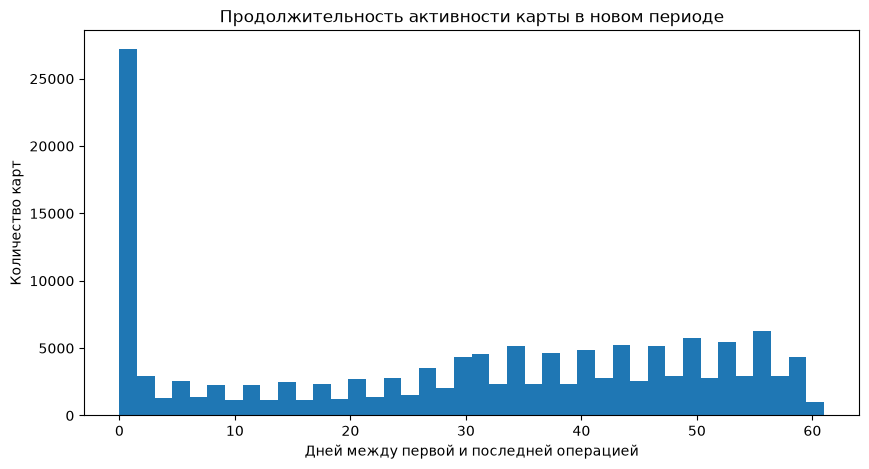

In [63]:
new_period_days = temporal_feature_data[
    "new_transaction_period_days"
].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    new_period_days,
    bins=40,
)

plt.title(
    "Продолжительность активности карты в новом периоде"
)
plt.xlabel("Дней между первой и последней операцией")
plt.ylabel("Количество карт")
plt.show()

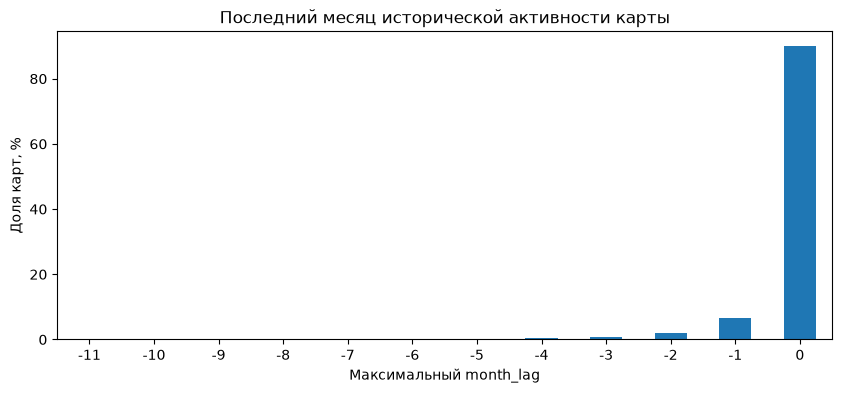

In [64]:
historical_latest_month_share = (
    temporal_feature_data[
        "historical_month_lag_max"
    ]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

historical_latest_month_share.plot(
    kind="bar",
    figsize=(10, 4),
)

plt.title(
    "Последний месяц исторической активности карты"
)
plt.xlabel("Максимальный month_lag")
plt.ylabel("Доля карт, %")
plt.xticks(rotation=0)
plt.show()

Продолжительность исторической активности заметно различается между картами. Медиана между первой и последней операцией составляет 233 дня.

У большинства карт есть операции в контрольном месяце, но часть завершает активность раньше.

У 17 507 карт новых транзакций нет. Среди остальных медианная длительность нового периода составляет 32 дня.

Нулевая длительность означает операции только в один день и не равна отсутствию новых транзакций.

В признаки добавим длительность активности, `month_lag`, давность последней операции и индикаторы активности в новых месяцах.

### Качество данных продавцов

Проверим уникальность `merchant_id`, пропуски, дубликаты и бесконечные значения.

In [65]:
merchants = pd.read_csv(
    DATA_DIR / "merchants.csv",
    low_memory=False,
)

In [66]:
duplicated_merchant_id_mask = merchants[
    "merchant_id"
].duplicated(keep=False)

merchant_quality_summary = pd.Series(
    {
        "Количество строк": len(merchants),
        "Уникальные merchant_id": (
            merchants["merchant_id"].nunique()
        ),
        "Пропуски merchant_id": (
            merchants["merchant_id"].isna().sum()
        ),
        "Полные дубликаты строк": (
            merchants.duplicated().sum()
        ),
        "Строки с повторяющимся merchant_id": (
            duplicated_merchant_id_mask.sum()
        ),
        "Повторяющиеся merchant_id": (
            merchants.loc[
                duplicated_merchant_id_mask,
                "merchant_id",
            ].nunique()
        ),
    },
    name="Значение",
).to_frame()

merchant_quality_summary

,Значение
Количество строк,334696
Уникальные merchant_id,334633
Пропуски merchant_id,0
Полные дубликаты строк,0
Строки с повторяющимся merchant_id,104
Повторяющиеся merchant_id,41


In [67]:
merchant_missing_summary = pd.DataFrame(
    {
        "missing_count": merchants.isna().sum(),
        "missing_share_pct": (
            merchants.isna().mean() * 100
        ),
    }
)

merchant_missing_summary = merchant_missing_summary.loc[
    merchant_missing_summary["missing_count"].gt(0)
].sort_values(
    "missing_share_pct",
    ascending=False,
)

merchant_missing_summary

,missing_count,missing_share_pct
category_2,11887,3.551581
avg_sales_lag3,13,0.003884
avg_sales_lag6,13,0.003884
avg_sales_lag12,13,0.003884


In [68]:
merchant_numeric_columns = merchants.select_dtypes(
    include="number"
).columns

merchant_infinite_counts = merchants[
    merchant_numeric_columns
].apply(
    lambda column: np.isinf(column).sum()
)

merchant_infinite_summary = pd.DataFrame(
    {
        "infinite_count": merchant_infinite_counts,
        "infinite_share_pct": (
            merchant_infinite_counts
            / len(merchants)
            * 100
        ),
    }
)

merchant_infinite_summary = (
    merchant_infinite_summary.loc[
        merchant_infinite_summary[
            "infinite_count"
        ].gt(0)
    ]
    .sort_values(
        "infinite_count",
        ascending=False,
    )
)

merchant_infinite_summary

,infinite_count,infinite_share_pct
avg_purchases_lag3,3,0.000896
avg_purchases_lag6,3,0.000896
avg_purchases_lag12,3,0.000896


In [69]:
merchant_rows_per_id = (
    merchants.groupby(
        "merchant_id",
        dropna=False,
    )
    .size()
    .rename("row_count")
)

distinct_merchant_rows_per_id = (
    merchants.drop_duplicates()
    .groupby(
        "merchant_id",
        dropna=False,
    )
    .size()
    .rename("distinct_row_count")
)

duplicated_merchant_id_summary = (
    pd.concat(
        [
            merchant_rows_per_id,
            distinct_merchant_rows_per_id,
        ],
        axis=1,
    )
    .fillna(0)
    .astype("int32")
)

duplicated_merchant_id_summary = (
    duplicated_merchant_id_summary.loc[
        duplicated_merchant_id_summary[
            "row_count"
        ].gt(1)
    ]
)

duplicate_type_summary = pd.Series(
    {
        "Повторяющиеся ID только с точными дублями": (
            duplicated_merchant_id_summary[
                "distinct_row_count"
            ].eq(1).sum()
        ),
        "Повторяющиеся ID с различающимися строками": (
            duplicated_merchant_id_summary[
                "distinct_row_count"
            ].gt(1).sum()
        ),
        "Максимум строк на один merchant_id": (
            duplicated_merchant_id_summary[
                "row_count"
            ].max()
        ),
        "Максимум различных строк на один merchant_id": (
            duplicated_merchant_id_summary[
                "distinct_row_count"
            ].max()
        ),
    },
    name="Значение",
).to_frame()

duplicate_type_summary

,Значение
Повторяющиеся ID только с точными дублями,0
Повторяющиеся ID с различающимися строками,41
Максимум строк на один merchant_id,4
Максимум различных строк на один merchant_id,4


В таблице 334 696 строк и 334 633 уникальных продавца.

Для 41 `merchant_id` есть несколько различающихся строк. Прямое объединение размножит транзакции, поэтому сначала приведём таблицу к одной строке на продавца.

Основные пропуски находятся в `category_2` - 3,55%. В нескольких числовых признаках также есть пропуски и бесконечные значения.

#### Повторяющиеся merchant_id

In [70]:
duplicated_merchants = (
    merchants.loc[
        duplicated_merchant_id_mask
    ]
    .sort_values("merchant_id")
    .copy()
)

duplicate_values_per_merchant = (
    duplicated_merchants
    .groupby("merchant_id")
    .nunique(dropna=False)
)

duplicate_column_variation = pd.DataFrame(
    {
        "merchant_ids_with_differences": (
            duplicate_values_per_merchant.gt(1).sum()
        ),
        "maximum_distinct_values_per_id": (
            duplicate_values_per_merchant.max()
        ),
    }
)

duplicate_column_variation = (
    duplicate_column_variation.loc[
        duplicate_column_variation[
            "merchant_ids_with_differences"
        ].gt(0)
    ]
    .sort_values(
        "merchant_ids_with_differences",
        ascending=False,
    )
)

duplicate_column_variation

,merchant_ids_with_differences,maximum_distinct_values_per_id
avg_sales_lag6,41,2
avg_sales_lag12,41,2
avg_purchases_lag3,41,2
avg_purchases_lag12,41,2
avg_purchases_lag6,41,2
avg_sales_lag3,40,2
numerical_1,34,2
most_recent_purchases_range,33,2
numerical_2,30,2
most_recent_sales_range,30,2


In [71]:
duplicate_row_count_distribution = (
    duplicated_merchants
    .groupby("merchant_id")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("rows_per_merchant_id")
    .rename("merchant_id_count")
    .to_frame()
)

duplicate_row_count_distribution

,merchant_id_count
rows_per_merchant_id,
2,30
4,11


Для 30 продавцов найдено по две строки, для 11 - по четыре. Строки различаются, поэтому нельзя просто оставить первую.

Числовые признаки объединим медианой. Категориальные значения сохраним, только если они совпадают; конфликты заменим пропусками.

Дополнительно добавим число исходных строк и признак конфликта

### Итоги EDA

Главные особенности данных:

- `target` имеет длинный левый хвост; значение `-33.219281` встречается у 1,09% карт
- у 10,84% карт нет новых транзакций
- число операций и `purchase_amount` имеют длинные правые хвосты
- одна историческая операция около 6 млн сильно влияет на денежные агрегаты
- важны частота, давность и длительность активности
- в транзакциях есть пропуски и специальные значения
- таблицу продавцов нужно привести к одной строке на `merchant_id`

На основе EDA создадим признаки карты, транзакционной активности, сумм покупок, времени, рассрочки, авторизации и разнообразия продавцов

## Разработка признаков

### Подготовка таблицы продавцов

In [72]:
merchants_clean = merchants.replace(
    [np.inf, -np.inf],
    np.nan,
)

MERCHANT_NUMERIC_COLUMNS = [
    "numerical_1",
    "numerical_2",
    "avg_sales_lag3",
    "avg_purchases_lag3",
    "active_months_lag3",
    "avg_sales_lag6",
    "avg_purchases_lag6",
    "active_months_lag6",
    "avg_sales_lag12",
    "avg_purchases_lag12",
    "active_months_lag12",
]

MERCHANT_CATEGORICAL_COLUMNS = [
    "merchant_group_id",
    "merchant_category_id",
    "subsector_id",
    "category_1",
    "most_recent_sales_range",
    "most_recent_purchases_range",
    "category_4",
    "city_id",
    "state_id",
    "category_2",
]

In [73]:
def get_consistent_value(values: pd.Series) -> object:
    """Возвращает согласованное непустое значение группы."""
    unique_values = values.dropna().unique()

    if len(unique_values) == 1:
        return unique_values[0]

    return np.nan

In [74]:
merchant_groups = merchants_clean.groupby(
    "merchant_id",
    sort=False,
)

merchant_numeric_features = merchant_groups[
    MERCHANT_NUMERIC_COLUMNS
].median()

merchant_categorical_features = merchant_groups[
    MERCHANT_CATEGORICAL_COLUMNS
].agg(get_consistent_value)

merchant_source_row_count = (
    merchant_groups
    .size()
    .rename("merchant_source_row_count")
)

merchant_conflict_count = (
    merchant_groups[
        MERCHANT_NUMERIC_COLUMNS
        + MERCHANT_CATEGORICAL_COLUMNS
    ]
    .nunique(dropna=True)
    .gt(1)
    .sum(axis=1)
    .rename("merchant_conflict_count")
)

merchants_unique = pd.concat(
    [
        merchant_numeric_features,
        merchant_categorical_features,
        merchant_source_row_count,
        merchant_conflict_count,
    ],
    axis=1,
).reset_index()

merchants_unique["merchant_has_conflict"] = (
    merchants_unique["merchant_conflict_count"].gt(0)
)

In [75]:
merchant_preparation_check = pd.Series(
    {
        "Количество строк": len(merchants_unique),
        "Уникальные merchant_id": (
            merchants_unique["merchant_id"].nunique()
        ),
        "merchant_id уникален": (
            merchants_unique["merchant_id"].is_unique
        ),
        "Продавцы с несколькими исходными строками": (
            merchants_unique[
                "merchant_source_row_count"
            ].gt(1).sum()
        ),
        "Продавцы с конфликтами": (
            merchants_unique[
                "merchant_has_conflict"
            ].sum()
        ),
        "Бесконечные значения": (
            np.isinf(
                merchants_unique.select_dtypes(
                    include="number"
                )
            ).sum().sum()
        ),
    },
    name="Значение",
).to_frame()

merchant_preparation_check

,Значение
Количество строк,334633
Уникальные merchant_id,334633
merchant_id уникален,True
Продавцы с несколькими исходными строками,41
Продавцы с конфликтами,41
Бесконечные значения,0


После обработки осталось 334 633 уникальных продавца.

Для 41 повторяющегося `merchant_id` числовые признаки объединены медианой, а конфликты в категориальных признаках заменены пропусками.

Бесконечных значений нет. Таблицу теперь можно безопасно объединять с транзакциями.

### Настройка DuckDB и кэша

DuckDB используется для работы с большими таблицами без полной загрузки в память.

Кэш и временные файлы сохраняются в локальной папке `cache`.

In [76]:
DUCKDB_DATABASE_PATH = (
    CACHE_DIR / "elo_features.duckdb"
)

DUCKDB_TEMP_DIR = (
    CACHE_DIR / "duckdb_temp"
)

DUCKDB_MEMORY_LIMIT = "6GB"
DUCKDB_THREADS = 4

DUCKDB_TEMP_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

duckdb_connection = duckdb.connect(
    database=str(DUCKDB_DATABASE_PATH),
    config={
        "memory_limit": DUCKDB_MEMORY_LIMIT,
        "threads": DUCKDB_THREADS,
        "temp_directory": str(
            DUCKDB_TEMP_DIR.resolve()
        ),
    },
)

In [77]:
duckdb_environment = (
    duckdb_connection.execute(
        """
        SELECT
            version() AS duckdb_version,
            current_setting(
                'memory_limit'
            ) AS memory_limit,
            current_setting(
                'threads'
            ) AS threads,
            current_setting(
                'temp_directory'
            ) AS temp_directory
        """
    )
    .df()
)

duckdb_environment

,duckdb_version,memory_limit,threads,temp_directory
0,v1.5.5,5.5 GiB,4,/Users/helen/Projects/elo-merchant-recommendat...


#### Кэширование исторических транзакций

Преобразуем исторические транзакции из CSV в Parquet и явно зададим типы столбцов.

Готовый кэш используется повторно.

In [78]:
HISTORICAL_CSV_PATH = (
    DATA_DIR / "historical_transactions.csv"
)

HISTORICAL_PARQUET_PATH = (
    CACHE_DIR / "historical_transactions.parquet"
)

TRANSACTION_DUCKDB_SCHEMA = {
    "authorized_flag": "VARCHAR",
    "card_id": "VARCHAR",
    "city_id": "SMALLINT",
    "category_1": "VARCHAR",
    "installments": "SMALLINT",
    "category_3": "VARCHAR",
    "merchant_category_id": "SMALLINT",
    "merchant_id": "VARCHAR",
    "month_lag": "TINYINT",
    "purchase_amount": "DOUBLE",
    "purchase_date": "TIMESTAMP",
    "category_2": "DOUBLE",
    "state_id": "SMALLINT",
    "subsector_id": "SMALLINT",
}

In [79]:
def prepare_sql_path(file_path: Path) -> str:
    """Подготавливает абсолютный путь для SQL-запроса."""
    return str(
        file_path.resolve()
    ).replace("'", "''")


def build_duckdb_columns_schema(
    columns_schema: dict[str, str],
) -> str:
    """Формирует описание столбцов для read_csv."""
    schema_items = [
        f"'{column_name}': '{column_type}'"
        for column_name, column_type
        in columns_schema.items()
    ]

    return "{" + ", ".join(schema_items) + "}"


def create_transaction_parquet_cache(
    csv_path: Path,
    parquet_path: Path,
    columns_schema: dict[str, str],
    cache_name: str,
    rebuild: bool,
) -> None:
    """Создаёт или повторно использует Parquet-кэш."""
    if parquet_path.exists() and not rebuild:
        print(
            f"Используется существующий кэш "
            f"{cache_name}:",
            parquet_path,
        )
        return

    temporary_path = parquet_path.with_name(
        f"{parquet_path.stem}.tmp"
        f"{parquet_path.suffix}"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    csv_sql_path = prepare_sql_path(csv_path)
    temporary_sql_path = prepare_sql_path(
        temporary_path
    )

    schema_sql = build_duckdb_columns_schema(
        columns_schema
    )

    try:
        duckdb_connection.execute(
            f"""
            COPY (
                SELECT *
                FROM read_csv(
                    '{csv_sql_path}',
                    header = true,
                    columns = {schema_sql}
                )
            )
            TO '{temporary_sql_path}'
            (
                FORMAT PARQUET,
                COMPRESSION ZSTD,
                ROW_GROUP_SIZE 250000
            )
            """
        )

        temporary_path.replace(parquet_path)

    except Exception:
        if temporary_path.exists():
            temporary_path.unlink()

        raise

    print(
        f"Кэш {cache_name} создан:",
        parquet_path,
    )

In [80]:
historical_parquet_sql_path = prepare_sql_path(
    HISTORICAL_PARQUET_PATH
)

create_transaction_parquet_cache(
    csv_path=HISTORICAL_CSV_PATH,
    parquet_path=HISTORICAL_PARQUET_PATH,
    columns_schema=TRANSACTION_DUCKDB_SCHEMA,
    cache_name="исторических транзакций",
    rebuild=REBUILD_TRANSACTION_CACHE,
)

Используется существующий кэш исторических транзакций: cache/historical_transactions.parquet


In [81]:
historical_cache_summary = (
    duckdb_connection.execute(
        f"""
        SELECT
            COUNT(*) AS transaction_count,
            COUNT(DISTINCT card_id) AS card_count,
            MIN(purchase_date) AS purchase_date_min,
            MAX(purchase_date) AS purchase_date_max,
            MIN(month_lag) AS month_lag_min,
            MAX(month_lag) AS month_lag_max
        FROM read_parquet(
            '{historical_parquet_sql_path}'
        )
        """
    )
    .df()
)

historical_cache_summary

,transaction_count,card_count,purchase_date_min,purchase_date_max,month_lag_min,month_lag_max
0,29112361,325540,2017-01-01 00:00:08,2018-02-28 23:59:51,-13,0


In [82]:
historical_cache_schema = (
    duckdb_connection.execute(
        f"""
        DESCRIBE
        SELECT *
        FROM read_parquet(
            '{historical_parquet_sql_path}'
        )
        """
    )
    .df()
)

historical_cache_schema

,column_name,column_type,null,key,default,extra
0,authorized_flag,VARCHAR,YES,None,None,None
1,card_id,VARCHAR,YES,None,None,None
2,city_id,SMALLINT,YES,None,None,None
3,category_1,VARCHAR,YES,None,None,None
4,installments,SMALLINT,YES,None,None,None
5,category_3,VARCHAR,YES,None,None,None
6,merchant_category_id,SMALLINT,YES,None,None,None
7,merchant_id,VARCHAR,YES,None,None,None
8,month_lag,TINYINT,YES,None,None,None
9,purchase_amount,DOUBLE,YES,None,None,None


#### Кэширование новых транзакций

Новые транзакции сохраняются в Parquet с той же схемой, что и исторические.

In [83]:
NEW_TRANSACTIONS_CSV_PATH = (
    DATA_DIR / "new_merchant_transactions.csv"
)

NEW_TRANSACTIONS_PARQUET_PATH = (
    CACHE_DIR / "new_merchant_transactions.parquet"
)

In [84]:
new_transactions_parquet_sql_path = prepare_sql_path(
    NEW_TRANSACTIONS_PARQUET_PATH
)

create_transaction_parquet_cache(
    csv_path=NEW_TRANSACTIONS_CSV_PATH,
    parquet_path=NEW_TRANSACTIONS_PARQUET_PATH,
    columns_schema=TRANSACTION_DUCKDB_SCHEMA,
    cache_name="новых транзакций",
    rebuild=REBUILD_TRANSACTION_CACHE,
)

Используется существующий кэш новых транзакций: cache/new_merchant_transactions.parquet


In [85]:
new_transactions_cache_summary = (
    duckdb_connection.execute(
        f"""
        SELECT
            COUNT(*) AS transaction_count,
            COUNT(DISTINCT card_id) AS card_count,
            MIN(purchase_date) AS purchase_date_min,
            MAX(purchase_date) AS purchase_date_max,
            MIN(month_lag) AS month_lag_min,
            MAX(month_lag) AS month_lag_max
        FROM read_parquet(
            '{new_transactions_parquet_sql_path}'
        )
        """
    )
    .df()
)

new_transactions_cache_summary

,transaction_count,card_count,purchase_date_min,purchase_date_max,month_lag_min,month_lag_max
0,1963031,290001,2017-03-01 03:24:51,2018-04-30 23:59:59,1,2


In [86]:
new_transactions_cache_schema = (
    duckdb_connection.execute(
        f"""
        DESCRIBE
        SELECT *
        FROM read_parquet(
            '{new_transactions_parquet_sql_path}'
        )
        """
    )
    .df()
)

new_transactions_cache_schema

,column_name,column_type,null,key,default,extra
0,authorized_flag,VARCHAR,YES,None,None,None
1,card_id,VARCHAR,YES,None,None,None
2,city_id,SMALLINT,YES,None,None,None
3,category_1,VARCHAR,YES,None,None,None
4,installments,SMALLINT,YES,None,None,None
5,category_3,VARCHAR,YES,None,None,None
6,merchant_category_id,SMALLINT,YES,None,None,None
7,merchant_id,VARCHAR,YES,None,None,None
8,month_lag,TINYINT,YES,None,None,None
9,purchase_amount,DOUBLE,YES,None,None,None


#### Кэширование таблицы продавцов

Сохраним подготовленную таблицу в Parquet для дальнейшего использования.

In [87]:
MERCHANTS_UNIQUE_PARQUET_PATH = (
    CACHE_DIR / "merchants_unique.parquet"
)

merchants_unique_parquet_sql_path = prepare_sql_path(
    MERCHANTS_UNIQUE_PARQUET_PATH
)

In [88]:
merchants_unique_temporary_path = (
    MERCHANTS_UNIQUE_PARQUET_PATH.with_name(
        f"{MERCHANTS_UNIQUE_PARQUET_PATH.stem}.tmp"
        f"{MERCHANTS_UNIQUE_PARQUET_PATH.suffix}"
    )
)

merchants_unique_temporary_sql_path = (
    prepare_sql_path(
        merchants_unique_temporary_path
    )
)

if merchants_unique_temporary_path.exists():
    merchants_unique_temporary_path.unlink()

duckdb_connection.register(
    "merchants_unique_df",
    merchants_unique,
)

try:
    duckdb_connection.execute(
        f"""
        COPY (
            SELECT *
            FROM merchants_unique_df
        )
        TO '{merchants_unique_temporary_sql_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    merchants_unique_temporary_path.replace(
        MERCHANTS_UNIQUE_PARQUET_PATH
    )

except Exception:
    if merchants_unique_temporary_path.exists():
        merchants_unique_temporary_path.unlink()

    raise

finally:
    duckdb_connection.unregister(
        "merchants_unique_df"
    )

print(
    "Кэш подготовленной таблицы продавцов создан:",
    MERCHANTS_UNIQUE_PARQUET_PATH,
)

Кэш подготовленной таблицы продавцов создан: cache/merchants_unique.parquet


In [89]:
merchants_cache_summary = (
    duckdb_connection.execute(
        f"""
        SELECT
            COUNT(*) AS merchant_count,
            COUNT(
                DISTINCT merchant_id
            ) AS unique_merchant_count,
            COUNT(*)
                - COUNT(
                    DISTINCT merchant_id
                ) AS duplicate_merchant_id_count,
            SUM(
                CASE
                    WHEN merchant_source_row_count > 1
                    THEN 1
                    ELSE 0
                END
            ) AS merchants_with_multiple_source_rows,
            SUM(
                CASE
                    WHEN merchant_has_conflict
                    THEN 1
                    ELSE 0
                END
            ) AS merchants_with_conflict
        FROM read_parquet(
            '{merchants_unique_parquet_sql_path}'
        )
        """
    )
    .df()
)

merchants_cache_summary

,merchant_count,unique_merchant_count,duplicate_merchant_id_count,merchants_with_multiple_source_rows,merchants_with_conflict
0,334633,334633,0,41.0,41.0


In [90]:
cache_audit = (
    duckdb_connection.execute(
        f"""
        SELECT
            'historical_transactions'
                AS cache_name,
            COUNT(*) AS row_count,
            COUNT(
                DISTINCT card_id
            ) AS unique_key_count
        FROM read_parquet(
            '{historical_parquet_sql_path}'
        )

        UNION ALL

        SELECT
            'new_transactions'
                AS cache_name,
            COUNT(*) AS row_count,
            COUNT(
                DISTINCT card_id
            ) AS unique_key_count
        FROM read_parquet(
            '{new_transactions_parquet_sql_path}'
        )

        UNION ALL

        SELECT
            'merchants_unique'
                AS cache_name,
            COUNT(*) AS row_count,
            COUNT(
                DISTINCT merchant_id
            ) AS unique_key_count
        FROM read_parquet(
            '{merchants_unique_parquet_sql_path}'
        )
        """
    )
    .df()
)

In [91]:
cache_paths = {
    "historical_transactions": (
        HISTORICAL_PARQUET_PATH
    ),
    "new_transactions": (
        NEW_TRANSACTIONS_PARQUET_PATH
    ),
    "merchants_unique": (
        MERCHANTS_UNIQUE_PARQUET_PATH
    ),
}

cache_audit["file_size_mb"] = (
    cache_audit["cache_name"]
    .map(
        {
            cache_name: (
                cache_path.stat().st_size
                / 1024**2
            )
            for cache_name, cache_path
            in cache_paths.items()
        }
    )
    .round(2)
)

expected_transaction_columns = list(
    TRANSACTION_DUCKDB_SCHEMA
)

cache_integrity_checks = pd.Series(
    {
        "Исторический кэш не пуст": (
            historical_cache_summary.loc[
                0,
                "transaction_count",
            ]
            > 0
        ),
        "Кэш новых транзакций не пуст": (
            new_transactions_cache_summary.loc[
                0,
                "transaction_count",
            ]
            > 0
        ),
        "Столбцы historical соответствуют схеме": (
            historical_cache_schema[
                "column_name"
            ].tolist()
            == expected_transaction_columns
        ),
        "Столбцы new соответствуют схеме": (
            new_transactions_cache_schema[
                "column_name"
            ].tolist()
            == expected_transaction_columns
        ),
        "merchant_id уникален в кэше продавцов": (
            int(
                merchants_cache_summary.loc[
                    0,
                    "duplicate_merchant_id_count",
                ]
            )
            == 0
        ),
        "Все файлы кэша имеют ненулевой размер": all(
            cache_path.stat().st_size > 0
            for cache_path in cache_paths.values()
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=cache_integrity_checks,
    check_name="целостность Parquet-кэша",
)

display(cache_audit)

cache_integrity_checks.to_frame()

,cache_name,row_count,unique_key_count,file_size_mb
0,historical_transactions,29112361,325540,430.15
1,new_transactions,1963031,290001,34.73
2,merchants_unique,334633,334633,10.26


,Значение
Исторический кэш не пуст,True
Кэш новых транзакций не пуст,True
Столбцы historical соответствуют схеме,True
Столбцы new соответствуют схеме,True
merchant_id уникален в кэше продавцов,True
Все файлы кэша имеют ненулевой размер,True


### Исходные признаки карты

Кроме `feature_1`, `feature_2` и `feature_3`, из `first_active_month` создадим:

- год, месяц и квартал первой активности
- число месяцев до мая 2018 года
- индикатор пропущенной даты

Одинаковая обработка применяется к train и test

In [92]:
CARD_REFERENCE_MONTH = pd.Timestamp(
    "2018-05-01"
)

BASE_CARD_COLUMNS = [
    "card_id",
    "first_active_month",
    "feature_1",
    "feature_2",
    "feature_3",
]

In [93]:
def build_base_card_features(
    data: pd.DataFrame,
    reference_month: pd.Timestamp,
) -> pd.DataFrame:
    """Создаёт исходные признаки на уровне карты."""
    missing_columns = set(
        BASE_CARD_COLUMNS
    ).difference(data.columns)

    if missing_columns:
        raise ValueError(
            "В таблице отсутствуют столбцы: "
            f"{sorted(missing_columns)}"
        )

    card_features = data[
        BASE_CARD_COLUMNS
    ].copy()

    first_active_month = pd.to_datetime(
        card_features["first_active_month"],
        errors="coerce",
    )

    card_features[
        "first_active_month_missing"
    ] = first_active_month.isna().astype(
        "int8"
    )

    card_features[
        "first_active_year"
    ] = first_active_month.dt.year.astype(
        "Int16"
    )

    card_features[
        "first_active_month_number"
    ] = first_active_month.dt.month.astype(
        "Int8"
    )

    card_features[
        "first_active_quarter"
    ] = first_active_month.dt.quarter.astype(
        "Int8"
    )

    reference_month_number = (
        reference_month.year * 12
        + reference_month.month
    )

    first_active_month_number = (
        first_active_month.dt.year * 12
        + first_active_month.dt.month
    )

    card_features[
        "first_active_elapsed_months"
    ] = (
        reference_month_number
        - first_active_month_number
    ).astype("Int16")

    for column_name in [
        "feature_1",
        "feature_2",
        "feature_3",
    ]:
        card_features[column_name] = (
            card_features[column_name]
            .astype("Int8")
        )

    card_features = card_features.drop(
        columns="first_active_month"
    )

    return card_features

In [94]:
base_features_train = build_base_card_features(
    data=train_full,
    reference_month=CARD_REFERENCE_MONTH,
)

base_features_test = build_base_card_features(
    data=test,
    reference_month=CARD_REFERENCE_MONTH,
)

In [95]:
base_feature_columns_match = (
    base_features_train.columns.tolist()
    == base_features_test.columns.tolist()
)

base_features_audit = pd.DataFrame(
    {
        "dataset": [
            "train",
            "test",
        ],
        "row_count": [
            len(base_features_train),
            len(base_features_test),
        ],
        "unique_card_count": [
            base_features_train[
                "card_id"
            ].nunique(),
            base_features_test[
                "card_id"
            ].nunique(),
        ],
        "duplicate_card_count": [
            base_features_train[
                "card_id"
            ].duplicated().sum(),
            base_features_test[
                "card_id"
            ].duplicated().sum(),
        ],
        "missing_first_active_month": [
            base_features_train[
                "first_active_month_missing"
            ].sum(),
            base_features_test[
                "first_active_month_missing"
            ].sum(),
        ],
        "card_order_preserved": [
            base_features_train[
                "card_id"
            ].equals(
                train_full["card_id"]
            ),
            base_features_test[
                "card_id"
            ].equals(
                test["card_id"]
            ),
        ],
        "feature_count_without_card_id": [
            base_features_train.shape[1] - 1,
            base_features_test.shape[1] - 1,
        ],
    }
)

base_features_audit

,dataset,row_count,unique_card_count,duplicate_card_count,missing_first_active_month,card_order_preserved,feature_count_without_card_id
0,train,201917,201917,0,0,True,8
1,test,123623,123623,0,1,True,8


In [96]:
base_features_check = pd.Series(
    {
        "Столбцы train и test совпадают": (
            base_feature_columns_match
        ),
        "target отсутствует в train-признаках": (
            "target"
            not in base_features_train.columns
        ),
        "target отсутствует в test-признаках": (
            "target"
            not in base_features_test.columns
        ),
        "card_id уникален в train": (
            base_features_train[
                "card_id"
            ].is_unique
        ),
        "card_id уникален в test": (
            base_features_test[
                "card_id"
            ].is_unique
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=base_features_check,
    check_name="исходные признаки карты",
)

base_features_check.to_frame()

,Значение
Столбцы train и test совпадают,True
target отсутствует в train-признаках,True
target отсутствует в test-признаках,True
card_id уникален в train,True
card_id уникален в test,True


#### Кэширование исходных признаков карты

Сохраним подготовленные признаки train и test в Parquet

In [97]:
BASE_FEATURES_TRAIN_PARQUET_PATH = (
    CACHE_DIR / "base_card_features_train.parquet"
)

BASE_FEATURES_TEST_PARQUET_PATH = (
    CACHE_DIR / "base_card_features_test.parquet"
)

In [98]:
def save_dataframe_to_parquet(
    data: pd.DataFrame,
    relation_name: str,
    output_path: Path,
) -> None:
    """Атомарно сохраняет DataFrame в Parquet."""
    temporary_path = output_path.with_name(
        f"{output_path.stem}.tmp"
        f"{output_path.suffix}"
    )

    temporary_sql_path = prepare_sql_path(
        temporary_path
    )

    if temporary_path.exists():
        temporary_path.unlink()

    duckdb_connection.register(
        relation_name,
        data,
    )

    try:
        duckdb_connection.execute(
            f"""
            COPY (
                SELECT *
                FROM {relation_name}
            )
            TO '{temporary_sql_path}'
            (
                FORMAT PARQUET,
                COMPRESSION ZSTD
            )
            """
        )

        temporary_path.replace(output_path)

    except Exception:
        if temporary_path.exists():
            temporary_path.unlink()

        raise

    finally:
        duckdb_connection.unregister(
            relation_name
        )

In [99]:
save_dataframe_to_parquet(
    data=base_features_train,
    relation_name="base_features_train_df",
    output_path=BASE_FEATURES_TRAIN_PARQUET_PATH,
)

save_dataframe_to_parquet(
    data=base_features_test,
    relation_name="base_features_test_df",
    output_path=BASE_FEATURES_TEST_PARQUET_PATH,
)

print("Кэш исходных признаков карты создан.")

Кэш исходных признаков карты создан.


In [100]:
base_features_train_sql_path = prepare_sql_path(
    BASE_FEATURES_TRAIN_PARQUET_PATH
)

base_features_test_sql_path = prepare_sql_path(
    BASE_FEATURES_TEST_PARQUET_PATH
)

base_features_cache_audit = (
    duckdb_connection.execute(
        f"""
        SELECT
            'train' AS dataset,
            COUNT(*) AS row_count,
            COUNT(DISTINCT card_id)
                AS unique_card_count,
            COUNT(*) - COUNT(DISTINCT card_id)
                AS duplicate_card_count
        FROM read_parquet(
            '{base_features_train_sql_path}'
        )

        UNION ALL

        SELECT
            'test' AS dataset,
            COUNT(*) AS row_count,
            COUNT(DISTINCT card_id)
                AS unique_card_count,
            COUNT(*) - COUNT(DISTINCT card_id)
                AS duplicate_card_count
        FROM read_parquet(
            '{base_features_test_sql_path}'
        )
        """
    )
    .df()
)

In [101]:
base_features_cache_audit[
    "expected_row_count"
] = [
    len(base_features_train),
    len(base_features_test),
]

base_features_cache_audit[
    "row_count_matches"
] = (
    base_features_cache_audit["row_count"]
    == base_features_cache_audit[
        "expected_row_count"
    ]
)

base_features_cache_audit[
    "file_size_mb"
] = [
    round(
        BASE_FEATURES_TRAIN_PARQUET_PATH
        .stat()
        .st_size
        / 1024**2,
        2,
    ),
    round(
        BASE_FEATURES_TEST_PARQUET_PATH
        .stat()
        .st_size
        / 1024**2,
        2,
    ),
]

base_features_cache_audit

,dataset,row_count,unique_card_count,duplicate_card_count,expected_row_count,row_count_matches,file_size_mb
0,train,201917,201917,0,201917,True,1.70
1,test,123623,123623,0,123623,True,1.04


### Базовые признаки исторических транзакций

Исторические транзакции агрегируются до одной строки на карту.

Создадим признаки:

- числа операций и активных дней
- сумм покупок
- длительности и давности активности
- разнообразия продавцов и категорий
- авторизации
- рассрочки

Специальное значение `-1` не считается отдельной категорией. Даты преобразуются в интервалы относительно `2018-05-01`.

In [102]:
HISTORICAL_FEATURES_V1_PARQUET_PATH = (
    CACHE_DIR / "historical_features_v1.parquet"
)

historical_features_v1_sql_path = prepare_sql_path(
    HISTORICAL_FEATURES_V1_PARQUET_PATH
)

In [103]:
historical_features_v1_temporary_path = (
    HISTORICAL_FEATURES_V1_PARQUET_PATH.with_name(
        f"{HISTORICAL_FEATURES_V1_PARQUET_PATH.stem}.tmp"
        f"{HISTORICAL_FEATURES_V1_PARQUET_PATH.suffix}"
    )
)

historical_features_v1_temporary_sql_path = (
    prepare_sql_path(
        historical_features_v1_temporary_path
    )
)

if historical_features_v1_temporary_path.exists():
    historical_features_v1_temporary_path.unlink()

try:
    duckdb_connection.execute(
        f"""
        COPY (
            SELECT
                card_id,

                COUNT(*) AS historical_transaction_count,

                COUNT(
                    DISTINCT month_lag
                ) AS historical_active_month_count,

                COUNT(
                    DISTINCT CAST(
                        purchase_date AS DATE
                    )
                ) AS historical_active_day_count,

                SUM(
                    purchase_amount
                ) AS historical_purchase_amount_sum,

                AVG(
                    purchase_amount
                ) AS historical_purchase_amount_mean,

                MEDIAN(
                    purchase_amount
                ) AS historical_purchase_amount_median,

                MIN(
                    purchase_amount
                ) AS historical_purchase_amount_min,

                MAX(
                    purchase_amount
                ) AS historical_purchase_amount_max,

                STDDEV_SAMP(
                    purchase_amount
                ) AS historical_purchase_amount_std,

                MIN(
                    month_lag
                ) AS historical_month_lag_min,

                MAX(
                    month_lag
                ) AS historical_month_lag_max,

                AVG(
                    month_lag
                ) AS historical_month_lag_mean,

                DATE_DIFF(
                    'day',
                    CAST(
                        MIN(purchase_date) AS DATE
                    ),
                    CAST(
                        MAX(purchase_date) AS DATE
                    )
                ) AS historical_activity_span_days,

                DATE_DIFF(
                    'day',
                    CAST(
                        MIN(purchase_date) AS DATE
                    ),
                    DATE '2018-05-01'
                ) AS historical_days_from_first_purchase,

                DATE_DIFF(
                    'day',
                    CAST(
                        MAX(purchase_date) AS DATE
                    ),
                    DATE '2018-05-01'
                ) AS historical_days_from_last_purchase,

                COUNT(
                    DISTINCT merchant_id
                ) AS historical_unique_merchant_count,

                COUNT(
                    DISTINCT CASE
                        WHEN merchant_category_id <> -1
                        THEN merchant_category_id
                    END
                ) AS historical_unique_merchant_category_count,

                COUNT(
                    DISTINCT CASE
                        WHEN subsector_id <> -1
                        THEN subsector_id
                    END
                ) AS historical_unique_subsector_count,

                CAST(
                    SUM(
                        CASE
                            WHEN authorized_flag = 'Y'
                            THEN 1
                            ELSE 0
                        END
                    )
                    AS BIGINT
                ) AS historical_authorized_count,

                CAST(
                    SUM(
                        CASE
                            WHEN authorized_flag = 'N'
                            THEN 1
                            ELSE 0
                        END
                    )
                    AS BIGINT
                ) AS historical_denied_count,

                AVG(
                    CASE
                        WHEN authorized_flag = 'Y'
                        THEN 1.0
                        WHEN authorized_flag = 'N'
                        THEN 0.0
                    END
                ) AS historical_authorized_share,

                AVG(
                    CASE
                        WHEN authorized_flag = 'N'
                        THEN 1.0
                        WHEN authorized_flag = 'Y'
                        THEN 0.0
                    END
                ) AS historical_denied_share,

                AVG(
                    CASE
                        WHEN installments = 0
                        THEN 1.0
                        WHEN installments IS NOT NULL
                        THEN 0.0
                    END
                ) AS historical_no_installments_share,

                AVG(
                    CASE
                        WHEN installments = 1
                        THEN 1.0
                        WHEN installments IS NOT NULL
                        THEN 0.0
                    END
                ) AS historical_one_installment_share,

                AVG(
                    CASE
                        WHEN installments
                            BETWEEN 2 AND 998
                        THEN 1.0
                        WHEN installments IS NOT NULL
                        THEN 0.0
                    END
                ) AS historical_multiple_installments_share,

                AVG(
                    CASE
                        WHEN installments IN (-1, 999)
                        THEN 1.0
                        WHEN installments IS NOT NULL
                        THEN 0.0
                    END
                ) AS historical_special_installments_share

            FROM read_parquet(
                '{historical_parquet_sql_path}'
            )
            GROUP BY card_id
        )
        TO '{historical_features_v1_temporary_sql_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    historical_features_v1_temporary_path.replace(
        HISTORICAL_FEATURES_V1_PARQUET_PATH
    )

except Exception:
    if historical_features_v1_temporary_path.exists():
        historical_features_v1_temporary_path.unlink()

    raise

print(
    "Кэш базовых исторических признаков создан:",
    HISTORICAL_FEATURES_V1_PARQUET_PATH,
)

Кэш базовых исторических признаков создан: cache/historical_features_v1.parquet


In [104]:
historical_features_v1_audit = (
    duckdb_connection.execute(
        f"""
        WITH all_cards AS (
            SELECT card_id
            FROM read_parquet(
                '{base_features_train_sql_path}'
            )

            UNION ALL

            SELECT card_id
            FROM read_parquet(
                '{base_features_test_sql_path}'
            )
        ),

        historical_features AS (
            SELECT *
            FROM read_parquet(
                '{historical_features_v1_sql_path}'
            )
        )

        SELECT
            (
                SELECT COUNT(*)
                FROM historical_features
            ) AS row_count,

            (
                SELECT COUNT(
                    DISTINCT card_id
                )
                FROM historical_features
            ) AS unique_card_count,

            (
                SELECT
                    COUNT(*)
                    - COUNT(
                        DISTINCT card_id
                    )
                FROM historical_features
            ) AS duplicate_card_count,

            (
                SELECT COUNT(*)
                FROM all_cards
            ) AS expected_card_count,

            (
                SELECT COUNT(*)
                FROM all_cards AS cards
                LEFT JOIN historical_features
                    AS features
                    USING (card_id)
                WHERE features.card_id IS NULL
            ) AS cards_without_historical_features,

            (
                SELECT COUNT(*)
                FROM historical_features
                    AS features
                LEFT JOIN all_cards AS cards
                    USING (card_id)
                WHERE cards.card_id IS NULL
            ) AS unexpected_historical_cards
        """
    )
    .df()
)

historical_features_v1_audit[
    "row_count_matches"
] = (
    historical_features_v1_audit[
        "row_count"
    ]
    == historical_features_v1_audit[
        "expected_card_count"
    ]
)

historical_features_v1_audit

,row_count,unique_card_count,duplicate_card_count,expected_card_count,cards_without_historical_features,unexpected_historical_cards,row_count_matches
0,325540,325540,0,325540,0,0,True


In [105]:
historical_features_v1_schema = (
    duckdb_connection.execute(
        f"""
        DESCRIBE
        SELECT *
        FROM read_parquet(
            '{historical_features_v1_sql_path}'
        )
        """
    )
    .df()
)

historical_features_v1_schema

,column_name,column_type,null,key,default,extra
0,card_id,VARCHAR,YES,None,None,None
1,historical_transaction_count,BIGINT,YES,None,None,None
2,historical_active_month_count,BIGINT,YES,None,None,None
3,historical_active_day_count,BIGINT,YES,None,None,None
4,historical_purchase_amount_sum,DOUBLE,YES,None,None,None
5,historical_purchase_amount_mean,DOUBLE,YES,None,None,None
6,historical_purchase_amount_median,DOUBLE,YES,None,None,None
7,historical_purchase_amount_min,DOUBLE,YES,None,None,None
8,historical_purchase_amount_max,DOUBLE,YES,None,None,None
9,historical_purchase_amount_std,DOUBLE,YES,None,None,None


In [106]:
historical_features_v1_quality = (
    duckdb_connection.execute(
        f"""
        SELECT
            COUNT(*) AS card_count,

            COUNT(*)
                - COUNT(
                    historical_purchase_amount_std
                ) AS missing_purchase_amount_std,

            SUM(
                CASE
                    WHEN historical_transaction_count
                        <= 0
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_transaction_count,

            SUM(
                CASE
                    WHEN historical_active_day_count
                        <= 0
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_active_day_count,

            MIN(
                historical_transaction_count
            ) AS transaction_count_min,

            MAX(
                historical_transaction_count
            ) AS transaction_count_max,

            MIN(
                historical_activity_span_days
            ) AS activity_span_days_min,

            MAX(
                historical_activity_span_days
            ) AS activity_span_days_max,

            MIN(
                historical_authorized_share
            ) AS authorized_share_min,

            MAX(
                historical_authorized_share
            ) AS authorized_share_max

        FROM read_parquet(
            '{historical_features_v1_sql_path}'
        )
        """
    )
    .df()
)

historical_features_v1_quality

,card_count,missing_purchase_amount_std,invalid_transaction_count,invalid_active_day_count,transaction_count_min,transaction_count_max,activity_span_days_min,activity_span_days_max,authorized_share_min,authorized_share_max
0,325540,0,0.0,0.0,2,5582,2,423,0.030488,1.0


In [107]:
historical_features_v1_consistency = (
    duckdb_connection.execute(
        f"""
        SELECT
            SUM(
                CASE
                    WHEN historical_authorized_count
                        + historical_denied_count
                        <> historical_transaction_count
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_authorization_count_rows,

            MAX(
                ABS(
                    historical_authorized_share
                    + historical_denied_share
                    - 1.0
                )
            ) AS max_authorization_share_deviation,

            SUM(
                CASE
                    WHEN ABS(
                        historical_no_installments_share
                        + historical_one_installment_share
                        + historical_multiple_installments_share
                        + historical_special_installments_share
                        - 1.0
                    ) > 1e-12
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_installment_share_rows,

            MAX(
                ABS(
                    historical_no_installments_share
                    + historical_one_installment_share
                    + historical_multiple_installments_share
                    + historical_special_installments_share
                    - 1.0
                )
            ) AS max_installment_share_deviation,

            SUM(
                CASE
                    WHEN historical_active_day_count
                        > historical_transaction_count
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_active_day_rows,

            SUM(
                CASE
                    WHEN historical_active_month_count
                        NOT BETWEEN 1 AND 14
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_active_month_rows,

            SUM(
                CASE
                    WHEN historical_month_lag_mean
                        < historical_month_lag_min
                    OR historical_month_lag_mean
                        > historical_month_lag_max
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_month_lag_rows

        FROM read_parquet(
            '{historical_features_v1_sql_path}'
        )
        """
    )
    .df()
)

historical_features_v1_consistency

,invalid_authorization_count_rows,max_authorization_share_deviation,invalid_installment_share_rows,max_installment_share_deviation,invalid_active_day_rows,invalid_active_month_rows,invalid_month_lag_rows
0,0.0,0.0,0.0,2.220446e-16,0.0,0.0,0.0


Исторические признаки сформированы для всех карт. Пропущенных, лишних и повторяющихся `card_id` нет.

Проверки счётчиков, долей и временных признаков пройдены. Небольшие отклонения сумм долей от единицы связаны с точностью вычислений.

### Базовые признаки новых транзакций

Новые транзакции агрегируются по той же схеме.

Дополнительно создадим признаки активности в первом, втором или обоих новых месяцах.

Карты без новых операций будут добавлены при сборке общей матрицы и отмечены отдельным индикатором.

In [108]:
NEW_FEATURES_V1_PARQUET_PATH = (
    CACHE_DIR / "new_features_v1.parquet"
)

new_features_v1_sql_path = prepare_sql_path(
    NEW_FEATURES_V1_PARQUET_PATH
)

In [109]:
new_features_v1_temporary_path = (
    NEW_FEATURES_V1_PARQUET_PATH.with_name(
        f"{NEW_FEATURES_V1_PARQUET_PATH.stem}.tmp"
        f"{NEW_FEATURES_V1_PARQUET_PATH.suffix}"
    )
)

new_features_v1_temporary_sql_path = (
    prepare_sql_path(
        new_features_v1_temporary_path
    )
)

if new_features_v1_temporary_path.exists():
    new_features_v1_temporary_path.unlink()

try:
    duckdb_connection.execute(
        f"""
        COPY (
            WITH new_aggregates AS (
                SELECT
                    card_id,

                    COUNT(*)
                        AS new_transaction_count,

                    COUNT(
                        DISTINCT month_lag
                    ) AS new_active_month_count,

                    COUNT(
                        DISTINCT CAST(
                            purchase_date AS DATE
                        )
                    ) AS new_active_day_count,

                    SUM(
                        purchase_amount
                    ) AS new_purchase_amount_sum,

                    AVG(
                        purchase_amount
                    ) AS new_purchase_amount_mean,

                    MEDIAN(
                        purchase_amount
                    ) AS new_purchase_amount_median,

                    MIN(
                        purchase_amount
                    ) AS new_purchase_amount_min,

                    MAX(
                        purchase_amount
                    ) AS new_purchase_amount_max,

                    STDDEV_SAMP(
                        purchase_amount
                    ) AS new_purchase_amount_std,

                    MIN(
                        month_lag
                    ) AS new_month_lag_min,

                    MAX(
                        month_lag
                    ) AS new_month_lag_max,

                    AVG(
                        month_lag
                    ) AS new_month_lag_mean,

                    DATE_DIFF(
                        'day',
                        CAST(
                            MIN(purchase_date) AS DATE
                        ),
                        CAST(
                            MAX(purchase_date) AS DATE
                        )
                    ) AS new_activity_span_days,

                    DATE_DIFF(
                        'day',
                        CAST(
                            MIN(purchase_date) AS DATE
                        ),
                        DATE '2018-05-01'
                    ) AS new_days_from_first_purchase,

                    DATE_DIFF(
                        'day',
                        CAST(
                            MAX(purchase_date) AS DATE
                        ),
                        DATE '2018-05-01'
                    ) AS new_days_from_last_purchase,

                    COUNT(
                        DISTINCT merchant_id
                    ) AS new_unique_merchant_count,

                    COUNT(
                        DISTINCT CASE
                            WHEN merchant_category_id <> -1
                            THEN merchant_category_id
                        END
                    ) AS new_unique_merchant_category_count,

                    COUNT(
                        DISTINCT CASE
                            WHEN subsector_id <> -1
                            THEN subsector_id
                        END
                    ) AS new_unique_subsector_count,

                    CAST(
                        SUM(
                            CASE
                                WHEN month_lag = 1
                                THEN 1
                                ELSE 0
                            END
                        )
                        AS BIGINT
                    ) AS new_month_1_transaction_count,

                    CAST(
                        SUM(
                            CASE
                                WHEN month_lag = 2
                                THEN 1
                                ELSE 0
                            END
                        )
                        AS BIGINT
                    ) AS new_month_2_transaction_count,

                    AVG(
                        CASE
                            WHEN installments = 0
                            THEN 1.0
                            WHEN installments IS NOT NULL
                            THEN 0.0
                        END
                    ) AS new_no_installments_share,

                    AVG(
                        CASE
                            WHEN installments = 1
                            THEN 1.0
                            WHEN installments IS NOT NULL
                            THEN 0.0
                        END
                    ) AS new_one_installment_share,

                    AVG(
                        CASE
                            WHEN installments
                                BETWEEN 2 AND 998
                            THEN 1.0
                            WHEN installments IS NOT NULL
                            THEN 0.0
                        END
                    ) AS new_multiple_installments_share,

                    AVG(
                        CASE
                            WHEN installments IN (-1, 999)
                            THEN 1.0
                            WHEN installments IS NOT NULL
                            THEN 0.0
                        END
                    ) AS new_special_installments_share

                FROM read_parquet(
                    '{new_transactions_parquet_sql_path}'
                )
                GROUP BY card_id
            )

            SELECT
                *,

                CAST(
                    new_month_1_transaction_count > 0
                    AND new_month_2_transaction_count = 0
                    AS TINYINT
                ) AS new_active_only_month_1,

                CAST(
                    new_month_1_transaction_count = 0
                    AND new_month_2_transaction_count > 0
                    AS TINYINT
                ) AS new_active_only_month_2,

                CAST(
                    new_month_1_transaction_count > 0
                    AND new_month_2_transaction_count > 0
                    AS TINYINT
                ) AS new_active_in_both_months,

                CAST(
                    new_activity_span_days = 0
                    AS TINYINT
                ) AS new_single_day_activity

            FROM new_aggregates
        )
        TO '{new_features_v1_temporary_sql_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    new_features_v1_temporary_path.replace(
        NEW_FEATURES_V1_PARQUET_PATH
    )

except Exception:
    if new_features_v1_temporary_path.exists():
        new_features_v1_temporary_path.unlink()

    raise

print(
    "Кэш базовых признаков новых транзакций создан:",
    NEW_FEATURES_V1_PARQUET_PATH,
)

Кэш базовых признаков новых транзакций создан: cache/new_features_v1.parquet


In [110]:
new_features_v1_audit = (
    duckdb_connection.execute(
        f"""
        WITH all_cards AS (
            SELECT card_id
            FROM read_parquet(
                '{base_features_train_sql_path}'
            )

            UNION ALL

            SELECT card_id
            FROM read_parquet(
                '{base_features_test_sql_path}'
            )
        ),

        new_features AS (
            SELECT *
            FROM read_parquet(
                '{new_features_v1_sql_path}'
            )
        )

        SELECT
            (
                SELECT COUNT(*)
                FROM new_features
            ) AS row_count,

            (
                SELECT COUNT(
                    DISTINCT card_id
                )
                FROM new_features
            ) AS unique_card_count,

            (
                SELECT
                    COUNT(*)
                    - COUNT(
                        DISTINCT card_id
                    )
                FROM new_features
            ) AS duplicate_card_count,

            (
                SELECT COUNT(*)
                FROM all_cards
            ) AS total_card_count,

            (
                SELECT COUNT(*)
                FROM all_cards AS cards
                LEFT JOIN new_features
                    AS features
                    USING (card_id)
                WHERE features.card_id IS NULL
            ) AS cards_without_new_features,

            (
                SELECT COUNT(*)
                FROM new_features AS features
                LEFT JOIN all_cards AS cards
                    USING (card_id)
                WHERE cards.card_id IS NULL
            ) AS unexpected_new_cards
        """
    )
    .df()
)

new_features_v1_audit[
    "row_count_matches_source"
] = (
    new_features_v1_audit["row_count"]
    == int(
        new_transactions_cache_summary.loc[
            0,
            "card_count",
        ]
    )
)

new_features_v1_audit

,row_count,unique_card_count,duplicate_card_count,total_card_count,cards_without_new_features,unexpected_new_cards,row_count_matches_source
0,290001,290001,0,325540,35539,0,True


In [111]:
new_features_v1_quality = (
    duckdb_connection.execute(
        f"""
        SELECT
            COUNT(*) AS card_count,

            COUNT(*)
                - COUNT(
                    new_purchase_amount_std
                ) AS missing_purchase_amount_std,

            SUM(
                CASE
                    WHEN new_transaction_count = 1
                    THEN 1
                    ELSE 0
                END
            ) AS single_transaction_card_count,

            SUM(
                CASE
                    WHEN new_transaction_count <= 0
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_transaction_count,

            SUM(
                CASE
                    WHEN new_active_day_count <= 0
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_active_day_count,

            MIN(
                new_transaction_count
            ) AS transaction_count_min,

            MAX(
                new_transaction_count
            ) AS transaction_count_max,

            MIN(
                new_activity_span_days
            ) AS activity_span_days_min,

            MAX(
                new_activity_span_days
            ) AS activity_span_days_max,

            MIN(
                new_month_lag_min
            ) AS month_lag_min,

            MAX(
                new_month_lag_max
            ) AS month_lag_max

        FROM read_parquet(
            '{new_features_v1_sql_path}'
        )
        """
    )
    .df()
)

new_features_v1_quality

,card_count,missing_purchase_amount_std,single_transaction_card_count,invalid_transaction_count,invalid_active_day_count,transaction_count_min,transaction_count_max,activity_span_days_min,activity_span_days_max,month_lag_min,month_lag_max
0,290001,43010,43010.0,0.0,0.0,1,109,0,61,1,2


In [112]:
new_features_v1_consistency = (
    duckdb_connection.execute(
        f"""
        SELECT
            SUM(
                CASE
                    WHEN new_month_1_transaction_count
                        + new_month_2_transaction_count
                        <> new_transaction_count
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_month_count_rows,

            SUM(
                CASE
                    WHEN new_active_only_month_1
                        + new_active_only_month_2
                        + new_active_in_both_months
                        <> 1
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_month_flag_rows,

            SUM(
                CASE
                    WHEN new_single_day_activity
                        <> CAST(
                            new_activity_span_days = 0
                            AS TINYINT
                        )
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_single_day_rows,

            SUM(
                CASE
                    WHEN ABS(
                        new_no_installments_share
                        + new_one_installment_share
                        + new_multiple_installments_share
                        + new_special_installments_share
                        - 1.0
                    ) > 1e-12
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_installment_share_rows,

            MAX(
                ABS(
                    new_no_installments_share
                    + new_one_installment_share
                    + new_multiple_installments_share
                    + new_special_installments_share
                    - 1.0
                )
            ) AS max_installment_share_deviation,

            SUM(
                CASE
                    WHEN new_month_lag_mean
                        < new_month_lag_min
                    OR new_month_lag_mean
                        > new_month_lag_max
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_month_lag_rows,

            SUM(
                CASE
                    WHEN new_active_day_count
                        > new_transaction_count
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_active_day_rows

        FROM read_parquet(
            '{new_features_v1_sql_path}'
        )
        """
    )
    .df()
)

new_features_v1_consistency

,invalid_month_count_rows,invalid_month_flag_rows,invalid_single_day_rows,invalid_installment_share_rows,max_installment_share_deviation,invalid_month_lag_rows,invalid_active_day_rows
0,0.0,0.0,0.0,0.0,2.220446e-16,0.0,0.0


Признаки сформированы для 290 001 карты с новыми транзакциями. Дубликатов и неизвестных `card_id` нет.

У 43 010 карт была только одна операция, поэтому стандартное отклонение суммы покупки для них не определено.

Проверки счётчиков, долей и временных признаков пройдены.

### Сборка матрицы признаков

Объединим признаки карты и транзакционные агрегаты по `card_id`.

Для карт без новых операций:

- счётчики и индикаторы равны `0`
- денежные и временные показатели остаются пропущенными
- `has_new_transactions` равен `0`

Также добавим разницы и отношения показателей исторического и нового периодов.

In [113]:
FEATURES_V1_TRAIN_PARQUET_PATH = (
    CACHE_DIR / "features_v1_train.parquet"
)

FEATURES_V1_TEST_PARQUET_PATH = (
    CACHE_DIR / "features_v1_test.parquet"
)

In [114]:
def build_features_v1(
    base_features_path: Path,
    output_path: Path,
) -> None:
    """Собирает базовую матрицу признаков V1."""
    base_features_sql_path = prepare_sql_path(
        base_features_path
    )

    temporary_output_path = output_path.with_name(
        f"{output_path.stem}.tmp"
        f"{output_path.suffix}"
    )

    temporary_output_sql_path = prepare_sql_path(
        temporary_output_path
    )

    if temporary_output_path.exists():
        temporary_output_path.unlink()

    try:
        duckdb_connection.execute(
            f"""
            COPY (
                WITH joined_raw AS (
                    SELECT
                        base_features.*,

                        historical_features.*
                            EXCLUDE (card_id),

                        new_features.*
                            EXCLUDE (card_id),

                        CAST(
                            new_features.card_id
                                IS NOT NULL
                            AS TINYINT
                        ) AS has_new_transactions

                    FROM read_parquet(
                        '{base_features_sql_path}'
                    ) AS base_features

                    INNER JOIN read_parquet(
                        '{historical_features_v1_sql_path}'
                    ) AS historical_features
                        USING (card_id)

                    LEFT JOIN read_parquet(
                        '{new_features_v1_sql_path}'
                    ) AS new_features
                        USING (card_id)
                ),

                joined_features AS (
                    SELECT
                        * REPLACE (
                            CAST(
                                COALESCE(
                                    new_transaction_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_transaction_count,

                            CAST(
                                COALESCE(
                                    new_active_month_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_active_month_count,

                            CAST(
                                COALESCE(
                                    new_active_day_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_active_day_count,

                            CAST(
                                COALESCE(
                                    new_unique_merchant_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_unique_merchant_count,

                            CAST(
                                COALESCE(
                                    new_unique_merchant_category_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_unique_merchant_category_count,

                            CAST(
                                COALESCE(
                                    new_unique_subsector_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_unique_subsector_count,

                            CAST(
                                COALESCE(
                                    new_month_1_transaction_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_month_1_transaction_count,

                            CAST(
                                COALESCE(
                                    new_month_2_transaction_count,
                                    0
                                )
                                AS BIGINT
                            ) AS new_month_2_transaction_count,

                            CAST(
                                COALESCE(
                                    new_active_only_month_1,
                                    0
                                )
                                AS TINYINT
                            ) AS new_active_only_month_1,

                            CAST(
                                COALESCE(
                                    new_active_only_month_2,
                                    0
                                )
                                AS TINYINT
                            ) AS new_active_only_month_2,

                            CAST(
                                COALESCE(
                                    new_active_in_both_months,
                                    0
                                )
                                AS TINYINT
                            ) AS new_active_in_both_months,

                            CAST(
                                COALESCE(
                                    new_single_day_activity,
                                    0
                                )
                                AS TINYINT
                            ) AS new_single_day_activity
                        )

                    FROM joined_raw
                ),

                features_with_rates AS (
                    SELECT
                        *,

                        CAST(
                            historical_transaction_count
                            AS DOUBLE
                        )
                        / NULLIF(
                            historical_active_month_count,
                            0
                        )
                        AS historical_transactions_per_active_month,

                        CASE
                            WHEN new_active_month_count > 0
                            THEN
                                CAST(
                                    new_transaction_count
                                    AS DOUBLE
                                )
                                / new_active_month_count
                            ELSE 0.0
                        END
                        AS new_transactions_per_active_month

                    FROM joined_features
                )

                SELECT
                    *,

                    new_transaction_count
                        - historical_transaction_count
                        AS new_minus_historical_transaction_count,

                    CAST(
                        new_transaction_count
                        AS DOUBLE
                    )
                    / NULLIF(
                        historical_transaction_count,
                        0
                    )
                    AS new_to_historical_transaction_count_ratio,

                    new_purchase_amount_mean
                        - historical_purchase_amount_mean
                        AS new_minus_historical_purchase_amount_mean,

                    new_purchase_amount_median
                        - historical_purchase_amount_median
                        AS new_minus_historical_purchase_amount_median,

                    new_unique_merchant_count
                        - historical_unique_merchant_count
                        AS new_minus_historical_unique_merchant_count,

                    new_transactions_per_active_month
                        - historical_transactions_per_active_month
                        AS new_minus_historical_transactions_per_active_month,

                    new_transactions_per_active_month
                    / NULLIF(
                        historical_transactions_per_active_month,
                        0
                    )
                    AS new_to_historical_transactions_per_active_month_ratio

                FROM features_with_rates
            )
            TO '{temporary_output_sql_path}'
            (
                FORMAT PARQUET,
                COMPRESSION ZSTD
            )
            """
        )

        temporary_output_path.replace(
            output_path
        )

    except Exception:
        if temporary_output_path.exists():
            temporary_output_path.unlink()

        raise

In [115]:
build_features_v1(
    base_features_path=BASE_FEATURES_TRAIN_PARQUET_PATH,
    output_path=FEATURES_V1_TRAIN_PARQUET_PATH,
)

build_features_v1(
    base_features_path=BASE_FEATURES_TEST_PARQUET_PATH,
    output_path=FEATURES_V1_TEST_PARQUET_PATH,
)

print("Матрицы признаков V1 созданы.")

Матрицы признаков V1 созданы.


In [116]:
features_v1_train_sql_path = prepare_sql_path(
    FEATURES_V1_TRAIN_PARQUET_PATH
)

features_v1_test_sql_path = prepare_sql_path(
    FEATURES_V1_TEST_PARQUET_PATH
)

In [117]:
features_v1_audit = (
    duckdb_connection.execute(
        f"""
        SELECT
            'train' AS dataset,
            COUNT(*) AS row_count,
            COUNT(
                DISTINCT card_id
            ) AS unique_card_count,
            COUNT(*)
                - COUNT(
                    DISTINCT card_id
                ) AS duplicate_card_count,
            SUM(
                CASE
                    WHEN has_new_transactions = 0
                    THEN 1
                    ELSE 0
                END
            ) AS cards_without_new_transactions
        FROM read_parquet(
            '{features_v1_train_sql_path}'
        )

        UNION ALL

        SELECT
            'test' AS dataset,
            COUNT(*) AS row_count,
            COUNT(
                DISTINCT card_id
            ) AS unique_card_count,
            COUNT(*)
                - COUNT(
                    DISTINCT card_id
                ) AS duplicate_card_count,
            SUM(
                CASE
                    WHEN has_new_transactions = 0
                    THEN 1
                    ELSE 0
                END
            ) AS cards_without_new_transactions
        FROM read_parquet(
            '{features_v1_test_sql_path}'
        )
        """
    )
    .df()
)

features_v1_audit["expected_row_count"] = [
    len(train_full),
    len(test),
]

features_v1_audit["row_count_matches"] = (
    features_v1_audit["row_count"]
    == features_v1_audit["expected_row_count"]
)

features_v1_integrity_checks = pd.Series(
    {
        "Число строк соответствует исходным таблицам": (
            features_v1_audit[
                "row_count_matches"
            ].all()
        ),
        "Дубликаты card_id отсутствуют": (
            features_v1_audit[
                "duplicate_card_count"
            ].eq(0).all()
        ),
        "card_id уникален": (
            features_v1_audit[
                "unique_card_count"
            ].eq(
                features_v1_audit[
                    "row_count"
                ]
            ).all()
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=features_v1_integrity_checks,
    check_name="целостность матриц V1",
)

features_v1_audit

,dataset,row_count,unique_card_count,duplicate_card_count,cards_without_new_transactions,expected_row_count,row_count_matches
0,train,201917,201917,0,21931.0,201917,True
1,test,123623,123623,0,13608.0,123623,True


In [118]:
features_v1_train_schema = (
    duckdb_connection.execute(
        f"""
        DESCRIBE
        SELECT *
        FROM read_parquet(
            '{features_v1_train_sql_path}'
        )
        """
    )
    .df()
)

features_v1_test_schema = (
    duckdb_connection.execute(
        f"""
        DESCRIBE
        SELECT *
        FROM read_parquet(
            '{features_v1_test_sql_path}'
        )
        """
    )
    .df()
)

features_v1_schema_check = pd.Series(
    {
        "Столбцы train и test совпадают": (
            features_v1_train_schema[
                "column_name"
            ].tolist()
            == features_v1_test_schema[
                "column_name"
            ].tolist()
        ),
        "Типы train и test совпадают": (
            features_v1_train_schema[
                "column_type"
            ].tolist()
            == features_v1_test_schema[
                "column_type"
            ].tolist()
        ),
        "Количество столбцов train": (
            len(features_v1_train_schema)
        ),
        "Количество столбцов test": (
            len(features_v1_test_schema)
        ),
        "Количество признаков без card_id": (
            len(features_v1_train_schema) - 1
        ),
        "target отсутствует": (
            "target"
            not in features_v1_train_schema[
                "column_name"
            ].tolist()
        ),
    },
    name="Значение",
).to_frame()

schema_boolean_checks_v1 = (
    features_v1_schema_check.loc[
        [
            "Столбцы train и test совпадают",
            "Типы train и test совпадают",
            "target отсутствует",
        ],
        "Значение",
    ]
)

assert_boolean_checks(
    checks=schema_boolean_checks_v1,
    check_name="схема матриц V1",
)

features_v1_schema_check

,Значение
Столбцы train и test совпадают,True
Типы train и test совпадают,True
Количество столбцов train,73
Количество столбцов test,73
Количество признаков без card_id,72
target отсутствует,True


Матрицы train и test собраны без потери и дублирования карт. Структура и типы столбцов совпадают, `target` в признаки не попал.

В итоговую матрицу вошло 72 признака.

Новые транзакции отсутствуют у 21 931 обучающей и 13 608 тестовых карт.

### Проверка матрицы признаков

Проверим пропуски, бесконечные значения и согласованность признаков.

Пропуски пока не заполняем: значения для заполнения будут рассчитываться отдельно внутри каждого CV-фолда.

#### Пропуски и бесконечные значения

In [119]:
feature_columns_v1 = (
    features_v1_train_schema.loc[
        features_v1_train_schema[
            "column_name"
        ].ne("card_id"),
        "column_name",
    ]
    .tolist()
)


def build_feature_quality_query(
    parquet_sql_path: str,
    dataset_name: str,
    feature_columns: list[str],
) -> str:
    """Формирует SQL-запрос проверки признаков."""
    feature_queries = []

    for column_name in feature_columns:
        feature_queries.append(
            f"""
            SELECT
                '{dataset_name}' AS dataset,
                '{column_name}' AS feature,
                COUNT(*) AS row_count,
                COUNT(*) - COUNT("{column_name}")
                    AS missing_count,
                100.0 * (
                    COUNT(*) - COUNT("{column_name}")
                ) / COUNT(*) AS missing_share_pct,
                SUM(
                    CASE
                        WHEN isinf("{column_name}")
                        THEN 1
                        ELSE 0
                    END
                ) AS infinite_count
            FROM read_parquet(
                '{parquet_sql_path}'
            )
            """
        )

    return "\nUNION ALL\n".join(
        feature_queries
    )

In [120]:
train_quality_query = build_feature_quality_query(
    parquet_sql_path=features_v1_train_sql_path,
    dataset_name="train",
    feature_columns=feature_columns_v1,
)

test_quality_query = build_feature_quality_query(
    parquet_sql_path=features_v1_test_sql_path,
    dataset_name="test",
    feature_columns=feature_columns_v1,
)

features_v1_quality = (
    duckdb_connection.execute(
        f"""
        {train_quality_query}

        UNION ALL

        {test_quality_query}
        """
    )
    .df()
)

In [121]:
features_v1_quality_summary = (
    features_v1_quality
    .groupby(
        "dataset",
        as_index=False,
    )
    .agg(
        feature_count=("feature", "size"),
        features_with_missing=(
            "missing_count",
            lambda values: values.gt(0).sum(),
        ),
        maximum_missing_share_pct=(
            "missing_share_pct",
            "max",
        ),
        total_infinite_count=(
            "infinite_count",
            "sum",
        ),
    )
)

assert_zero_counts(
    counts=(
        features_v1_quality_summary
        .set_index("dataset")[
            "total_infinite_count"
        ]
    ),
    check_name="бесконечные значения в матрицах V1",
)

features_v1_quality_summary

,dataset,feature_count,features_with_missing,maximum_missing_share_pct,total_infinite_count
0,test,72,22,24.130623,0.0
1,train,72,18,24.127736,0.0


In [122]:
features_v1_missing_summary = (
    features_v1_quality.loc[
        features_v1_quality[
            "missing_count"
        ].gt(0)
    ]
    .sort_values(
        [
            "dataset",
            "missing_share_pct",
            "feature",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

features_v1_missing_summary

,dataset,feature,row_count,missing_count,missing_share_pct,infinite_count
0,test,new_purchase_amount_std,123623,29831,24.130623,0.0
1,test,new_activity_span_days,123623,13608,11.007660,0.0
2,test,new_days_from_first_purchase,123623,13608,11.007660,0.0
3,test,new_days_from_last_purchase,123623,13608,11.007660,0.0
4,test,new_minus_historical_purchase_amount_mean,123623,13608,11.007660,0.0
5,test,new_minus_historical_purchase_amount_median,123623,13608,11.007660,0.0
6,test,new_month_lag_max,123623,13608,11.007660,0.0
7,test,new_month_lag_mean,123623,13608,11.007660,0.0
8,test,new_month_lag_min,123623,13608,11.007660,0.0
9,test,new_multiple_installments_share,123623,13608,11.007660,0.0


Бесконечных значений нет.

Основная часть пропусков связана с отсутствием новых транзакций. Это отдельно отмечено признаком `has_new_transactions`.

В `new_purchase_amount_std` пропущено 24,13% значений: стандартное отклонение не определено для карт без новых операций и карт с одной операцией.

В test у одной карты отсутствует `first_active_month`.

#### Константные и повторяющиеся признаки

In [123]:
features_v1_train = (
    duckdb_connection.execute(
        f"""
        SELECT *
        FROM read_parquet(
            '{features_v1_train_sql_path}'
        )
        """
    )
    .df()
)

features_v1_test = (
    duckdb_connection.execute(
        f"""
        SELECT *
        FROM read_parquet(
            '{features_v1_test_sql_path}'
        )
        """
    )
    .df()
)

print(
    "Размер train:",
    features_v1_train.shape,
)
print(
    "Размер test:",
    features_v1_test.shape,
)

Размер train: (201917, 73)
Размер test: (123623, 73)


In [124]:
features_v1_modeling = (
    train_modeling[
        ["card_id"]
    ]
    .merge(
        features_v1_train,
        on="card_id",
        how="left",
        validate="one_to_one",
        sort=False,
        indicator=True,
    )
)

missing_modeling_features = (
    features_v1_modeling[
        "_merge"
    ].ne("both").sum()
)

if missing_modeling_features:
    raise ValueError(
        "Не найдены признаки для modeling-карт: "
        f"{missing_modeling_features}"
    )

features_v1_modeling = (
    features_v1_modeling.drop(
        columns="_merge"
    )
)

if not features_v1_modeling[
    "card_id"
].equals(
    train_modeling[
        "card_id"
    ].reset_index(drop=True)
):
    raise ValueError(
        "Нарушен порядок modeling-карт."
    )

print(
    "Размер modeling-матрицы:",
    features_v1_modeling.shape,
)

Размер modeling-матрицы: (161533, 73)


In [125]:
def summarize_feature_variability(
    data: pd.DataFrame,
    dataset_name: str,
    feature_columns: list[str],
) -> pd.DataFrame:
    """Считает вариативность признаков."""
    summary_rows = []

    for column_name in feature_columns:
        value_counts = data[
            column_name
        ].value_counts(
            dropna=False
        )

        summary_rows.append(
            {
                "dataset": dataset_name,
                "feature": column_name,
                "unique_count": data[
                    column_name
                ].nunique(
                    dropna=False
                ),
                "missing_count": data[
                    column_name
                ].isna().sum(),
                "most_frequent_value": (
                    value_counts.index[0]
                ),
                "most_frequent_count": (
                    value_counts.iloc[0]
                ),
                "most_frequent_share_pct": (
                    value_counts.iloc[0]
                    / len(data)
                    * 100
                ),
            }
        )

    return pd.DataFrame(summary_rows)

In [126]:
features_v1_variability = (
    summarize_feature_variability(
        data=features_v1_modeling,
        dataset_name="modeling",
        feature_columns=feature_columns_v1,
    )
)

constant_or_near_constant_features = (
    features_v1_variability.loc[
        features_v1_variability[
            "unique_count"
        ].le(1)
        | features_v1_variability[
            "most_frequent_share_pct"
        ].ge(99.5)
    ]
    .sort_values(
        [
            "most_frequent_share_pct",
            "feature",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

constant_or_near_constant_features

,dataset,feature,unique_count,missing_count,most_frequent_value,most_frequent_count,most_frequent_share_pct
0,modeling,first_active_month_missing,1,0,0,161533,100.0


In [127]:
def find_duplicate_feature_pairs(
    data: pd.DataFrame,
    dataset_name: str,
    feature_columns: list[str],
) -> pd.DataFrame:
    """Находит полностью совпадающие признаки."""
    signature_groups: dict[
        tuple[object, ...],
        list[str],
    ] = {}

    for column_name in feature_columns:
        column = data[column_name]

        hashed_values = (
            pd.util.hash_pandas_object(
                column,
                index=False,
            )
        )

        signature = (
            str(column.dtype),
            int(column.isna().sum()),
            int(column.nunique(dropna=False)),
            int(hashed_values.sum()),
        )

        signature_groups.setdefault(
            signature,
            [],
        ).append(column_name)

    duplicate_rows = []

    for candidate_columns in (
        signature_groups.values()
    ):
        if len(candidate_columns) < 2:
            continue

        for current_position in range(
            1,
            len(candidate_columns),
        ):
            current_column = (
                candidate_columns[
                    current_position
                ]
            )

            for previous_column in (
                candidate_columns[
                    :current_position
                ]
            ):
                if data[
                    current_column
                ].equals(
                    data[previous_column]
                ):
                    duplicate_rows.append(
                        {
                            "dataset": dataset_name,
                            "feature_1": previous_column,
                            "feature_2": current_column,
                        }
                    )

    return pd.DataFrame(
        duplicate_rows,
        columns=[
            "dataset",
            "feature_1",
            "feature_2",
        ],
    )

In [128]:
duplicate_feature_pairs = (
    find_duplicate_feature_pairs(
        data=features_v1_modeling,
        dataset_name="modeling",
        feature_columns=feature_columns_v1,
    )
)

duplicate_feature_pairs

,dataset,feature_1,feature_2


Полностью совпадающих признаков нет.

`first_active_month_missing` исключается: в `train_modeling` он всегда равен нулю, поэтому модель не сможет оценить его влияние.

Для единственной карты test без даты календарные признаки будут заполнены внутри CV-пайплайна.

In [129]:
FEATURES_TO_DROP_V1 = [
    "first_active_month_missing",
]

model_feature_columns_v1 = [
    column_name
    for column_name in feature_columns_v1
    if column_name not in FEATURES_TO_DROP_V1
]

model_features_v1_summary = pd.Series(
    {
        "Исходное количество признаков": (
            len(feature_columns_v1)
        ),
        "Исключено признаков": (
            len(FEATURES_TO_DROP_V1)
        ),
        "Итоговое количество признаков": (
            len(model_feature_columns_v1)
        ),
    },
    name="Значение",
).to_frame()

model_features_v1_summary

,Значение
Исходное количество признаков,72
Исключено признаков,1
Итоговое количество признаков,71


#### Связи между признаками

In [130]:
def audit_deterministic_relations(
    data: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    """Проверяет ожидаемые связи между признаками."""
    active_month_count_expected = (
        data["new_active_only_month_1"]
        + data["new_active_only_month_2"]
        + 2 * data["new_active_in_both_months"]
    )

    has_new_transactions_expected = (
        data["new_transaction_count"] > 0
    ).astype("int8")

    single_day_activity_expected = (
        data["has_new_transactions"].eq(1)
        & data["new_activity_span_days"].eq(0)
    ).astype("int8")

    month_number = data[
        "first_active_month_number"
    ]

    quarter_expected = (
        (month_number - 1) // 3 + 1
    )

    elapsed_months_expected = (
        CARD_REFERENCE_MONTH.year * 12
        + CARD_REFERENCE_MONTH.month
        - (
            data["first_active_year"] * 12
            + month_number
        )
    )

    relation_masks = {
        (
            "historical_authorized_count + "
            "historical_denied_count = "
            "historical_transaction_count"
        ): (
            data["historical_authorized_count"]
            + data["historical_denied_count"]
            == data["historical_transaction_count"]
        ),
        (
            "historical_authorized_share + "
            "historical_denied_share = 1"
        ): np.isclose(
            data["historical_authorized_share"]
            + data["historical_denied_share"],
            1.0,
            atol=1e-12,
        ),
        (
            "new_month_1_count + "
            "new_month_2_count = "
            "new_transaction_count"
        ): (
            data["new_month_1_transaction_count"]
            + data["new_month_2_transaction_count"]
            == data["new_transaction_count"]
        ),
        (
            "has_new_transactions определяется "
            "числом новых операций"
        ): (
            data["has_new_transactions"]
            == has_new_transactions_expected
        ),
        (
            "new_active_month_count определяется "
            "месячными индикаторами"
        ): (
            data["new_active_month_count"]
            == active_month_count_expected
        ),
        (
            "new_single_day_activity определяется "
            "продолжительностью активности"
        ): (
            data["new_single_day_activity"]
            == single_day_activity_expected
        ),
        (
            "first_active_quarter определяется "
            "номером месяца"
        ): (
            month_number.isna()
            | data["first_active_quarter"].eq(
                quarter_expected
            )
        ),
        (
            "first_active_elapsed_months определяется "
            "годом и месяцем"
        ): (
            month_number.isna()
            | data[
                "first_active_elapsed_months"
            ].eq(elapsed_months_expected)
        ),
    }

    audit_rows = []

    for relation_name, valid_mask in (
        relation_masks.items()
    ):
        valid_mask = pd.Series(
            valid_mask,
            index=data.index,
        ).fillna(True)

        audit_rows.append(
            {
                "dataset": dataset_name,
                "relation": relation_name,
                "invalid_row_count": int(
                    (~valid_mask).sum()
                ),
            }
        )

    return pd.DataFrame(audit_rows)

In [131]:
deterministic_relations_audit = pd.concat(
    [
        audit_deterministic_relations(
            data=features_v1_train,
            dataset_name="train",
        ),
        audit_deterministic_relations(
            data=features_v1_test,
            dataset_name="test",
        ),
    ],
    ignore_index=True,
)

assert_zero_counts(
    counts=(
        deterministic_relations_audit
        .set_index(
            [
                "dataset",
                "relation",
            ]
        )[
            "invalid_row_count"
        ]
    ),
    check_name="детерминированные связи признаков",
)

deterministic_relations_audit

,dataset,relation,invalid_row_count
0,train,historical_authorized_count + historical_denie...,0
1,train,historical_authorized_share + historical_denie...,0
2,train,new_month_1_count + new_month_2_count = new_tr...,0
3,train,has_new_transactions определяется числом новых...,0
4,train,new_active_month_count определяется месячными ...,0
5,train,new_single_day_activity определяется продолжит...,0
6,train,first_active_quarter определяется номером месяца,0
7,train,first_active_elapsed_months определяется годом...,0
8,test,historical_authorized_count + historical_denie...,0
9,test,historical_authorized_share + historical_denie...,0


Нарушений в связях между счётчиками, долями и индикаторами нет.

Из модельного набора исключаются признаки, которые полностью восстанавливаются из других:

- `historical_denied_count`
- `historical_denied_share`
- `new_month_1_transaction_count`
- `new_active_month_count`
- `new_active_only_month_1`
- `first_active_year`

In [132]:
REDUNDANT_FEATURES_TO_DROP_V1 = [
    "historical_denied_count",
    "historical_denied_share",
    "new_month_1_transaction_count",
    "new_active_month_count",
    "new_active_only_month_1",
    "first_active_year",
]

FEATURES_TO_DROP_V1 = [
    "first_active_month_missing",
    *REDUNDANT_FEATURES_TO_DROP_V1,
]

feature_exclusions_v1 = pd.DataFrame(
    {
        "feature": FEATURES_TO_DROP_V1,
        "reason": [
            (
                "Константный признак в обучающей "
                "выборке"
            ),
            (
                "Восстанавливается из общего числа "
                "и авторизованных операций"
            ),
            (
                "Дополняет authorized_share до единицы"
            ),
            (
                "Восстанавливается из общего числа "
                "операций и month_2"
            ),
            (
                "Задаётся месячными индикаторами"
            ),
            (
                "Базовая категория для месячных "
                "индикаторов"
            ),
            (
                "Восстанавливается из месяца "
                "и elapsed_months"
            ),
        ],
    }
)

feature_exclusions_v1

,feature,reason
0,first_active_month_missing,Константный признак в обучающей выборке
1,historical_denied_count,Восстанавливается из общего числа и авторизова...
2,historical_denied_share,Дополняет authorized_share до единицы
3,new_month_1_transaction_count,Восстанавливается из общего числа операций и m...
4,new_active_month_count,Задаётся месячными индикаторами
5,new_active_only_month_1,Базовая категория для месячных индикаторов
6,first_active_year,Восстанавливается из месяца и elapsed_months


In [133]:
model_feature_columns_v1 = [
    column_name
    for column_name in feature_columns_v1
    if column_name not in FEATURES_TO_DROP_V1
]

final_feature_set_v1_summary = pd.Series(
    {
        "Признаков в исходной матрице": (
            len(feature_columns_v1)
        ),
        "Исключено признаков": (
            len(FEATURES_TO_DROP_V1)
        ),
        "Итоговых модельных признаков": (
            len(model_feature_columns_v1)
        ),
    },
    name="Значение",
).to_frame()

final_feature_set_v1_summary

,Значение
Признаков в исходной матрице,72
Исключено признаков,7
Итоговых модельных признаков,65


## Моделирование и валидация

### Подготовка модельных выборок

Матрица признаков объединяется с данными по `card_id`.

- `train_modeling` используется для разработки моделей
- `train_holdout` остаётся закрытым до финальной проверки
- test используется для конкурсных предсказаний

При объединении проверяются уникальность ключей и порядок строк

In [134]:
def assemble_model_dataset(
    cards_data: pd.DataFrame,
    feature_data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str | None = None,
) -> pd.DataFrame:
    """Объединяет список карт с модельными признаками."""
    card_columns = ["card_id"]

    if target_column is not None:
        card_columns.append(target_column)

    selected_feature_columns = [
        "card_id",
        *feature_columns,
    ]

    model_data = cards_data[
        card_columns
    ].merge(
        feature_data[selected_feature_columns],
        on="card_id",
        how="left",
        validate="one_to_one",
        sort=False,
        indicator=True,
    )

    missing_feature_rows = (
        model_data["_merge"].ne("both").sum()
    )

    if missing_feature_rows:
        raise ValueError(
            "Не найдены признаки для карт: "
            f"{missing_feature_rows}"
        )

    model_data = model_data.drop(
        columns="_merge"
    )

    if not model_data["card_id"].equals(
        cards_data["card_id"].reset_index(
            drop=True
        )
    ):
        raise ValueError(
            "После объединения изменился порядок карт."
        )

    return model_data

In [135]:
modeling_data_v1 = assemble_model_dataset(
    cards_data=train_modeling,
    feature_data=features_v1_train,
    feature_columns=model_feature_columns_v1,
    target_column="target",
)

holdout_data_v1 = assemble_model_dataset(
    cards_data=train_holdout,
    feature_data=features_v1_train,
    feature_columns=model_feature_columns_v1,
    target_column="target",
)

competition_test_data_v1 = (
    assemble_model_dataset(
        cards_data=test,
        feature_data=features_v1_test,
        feature_columns=model_feature_columns_v1,
    )
)

In [136]:
model_datasets_v1_audit = pd.DataFrame(
    {
        "dataset": [
            "modeling",
            "holdout",
            "competition_test",
        ],
        "row_count": [
            len(modeling_data_v1),
            len(holdout_data_v1),
            len(competition_test_data_v1),
        ],
        "expected_row_count": [
            len(train_modeling),
            len(train_holdout),
            len(test),
        ],
        "unique_card_count": [
            modeling_data_v1[
                "card_id"
            ].nunique(),
            holdout_data_v1[
                "card_id"
            ].nunique(),
            competition_test_data_v1[
                "card_id"
            ].nunique(),
        ],
        "feature_count": [
            modeling_data_v1.shape[1] - 2,
            holdout_data_v1.shape[1] - 2,
            competition_test_data_v1.shape[1] - 1,
        ],
        "contains_target": [
            "target" in modeling_data_v1.columns,
            "target" in holdout_data_v1.columns,
            (
                "target"
                in competition_test_data_v1.columns
            ),
        ],
    }
)

model_datasets_v1_audit[
    "row_count_matches"
] = (
    model_datasets_v1_audit["row_count"]
    == model_datasets_v1_audit[
        "expected_row_count"
    ]
)

model_dataset_checks_v1 = pd.Series(
    {
        "Число строк соответствует исходным наборам": (
            model_datasets_v1_audit[
                "row_count_matches"
            ].all()
        ),
        "card_id уникален во всех наборах": (
            model_datasets_v1_audit[
                "unique_card_count"
            ].eq(
                model_datasets_v1_audit[
                    "row_count"
                ]
            ).all()
        ),
        "Количество признаков совпадает": (
            model_datasets_v1_audit[
                "feature_count"
            ].nunique()
            == 1
        ),
        "target присутствует только в train-наборах": (
            model_datasets_v1_audit[
                "contains_target"
            ].tolist()
            == [True, True, False]
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=model_dataset_checks_v1,
    check_name="модельные выборки V1",
)

model_datasets_v1_audit

,dataset,row_count,expected_row_count,unique_card_count,feature_count,contains_target,row_count_matches
0,modeling,161533,161533,161533,65,True,True
1,holdout,40384,40384,40384,65,True,True
2,competition_test,123623,123623,123623,65,False,True


In [137]:
modeling_card_ids = pd.Index(
    modeling_data_v1["card_id"]
)

holdout_card_ids = pd.Index(
    holdout_data_v1["card_id"]
)

training_split_audit = pd.Series(
    {
        "Пересечение modeling и holdout": (
            len(
                modeling_card_ids.intersection(
                    holdout_card_ids
                )
            )
        ),
        "Всего карт после разделения": (
            len(modeling_data_v1)
            + len(holdout_data_v1)
        ),
        "Ожидаемое число train-карт": (
            len(train_full)
        ),
        "Все исходные train-карты восстановлены": (
            set(modeling_card_ids).union(
                holdout_card_ids
            )
            == set(train_full["card_id"])
        ),
    },
    name="Значение",
).to_frame()

training_split_checks_v1 = pd.Series(
    {
        "Пересечение modeling и holdout отсутствует": (
            len(
                modeling_card_ids.intersection(
                    holdout_card_ids
                )
            )
            == 0
        ),
        "Число train-карт сохранено": (
            len(modeling_data_v1)
            + len(holdout_data_v1)
            == len(train_full)
        ),
        "Все исходные train-карты восстановлены": (
            set(modeling_card_ids).union(
                holdout_card_ids
            )
            == set(train_full["card_id"])
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=training_split_checks_v1,
    check_name="изоляция modeling и holdout",
)

training_split_audit

,Значение
Пересечение modeling и holdout,0
Всего карт после разделения,201917
Ожидаемое число train-карт,201917
Все исходные train-карты восстановлены,True


В `train_modeling` вошло 161 533 карты, в `train_holdout` 40 384.

Наборы не пересекаются и вместе содержат все обучающие карты.

После удаления избыточных столбцов осталось 65 признаков.

### Фиксированные CV-фолды

Для всех моделей используются одни и те же три фолда.

Минимальное значение `target` выделяется в отдельную страту. Остальные значения делятся на десять квантильных групп.

Фолды строятся только на `train_modeling`.

In [138]:
CV_FOLD_COUNT = 3
CV_TARGET_BIN_COUNT = 10

In [139]:
def build_target_strata(
    target: pd.Series,
    bin_count: int,
    fold_count: int,
) -> pd.Series:
    """Формирует метки стратификации target."""
    target = target.reset_index(drop=True)

    extreme_target_value = target.min()

    extreme_target_mask = pd.Series(
        np.isclose(
            target.to_numpy(),
            extreme_target_value,
            rtol=0.0,
            atol=1e-12,
        ),
        index=target.index,
    )

    target_strata = pd.Series(
        index=target.index,
        dtype="object",
    )

    target_strata.loc[
        extreme_target_mask
    ] = "extreme_minimum"

    regular_target = target.loc[
        ~extreme_target_mask
    ]

    regular_target_bins = pd.qcut(
        regular_target,
        q=bin_count,
        labels=False,
        duplicates="drop",
    )

    target_strata.loc[
        ~extreme_target_mask
    ] = regular_target_bins.map(
        lambda bin_number: (
            f"regular_{int(bin_number)}"
        )
    )

    if target_strata.isna().any():
        raise ValueError(
            "Не для всех строк сформирована "
            "метка стратификации."
        )

    minimum_stratum_size = (
        target_strata.value_counts().min()
    )

    if minimum_stratum_size < fold_count:
        raise ValueError(
            "Размер одной из групп меньше "
            "числа CV-фолдов."
        )

    return target_strata

In [140]:
modeling_target_v1 = (
    modeling_data_v1["target"]
    .reset_index(drop=True)
)

cv_strata_v1 = build_target_strata(
    target=modeling_target_v1,
    bin_count=CV_TARGET_BIN_COUNT,
    fold_count=CV_FOLD_COUNT,
)

cv_splitter_v1 = StratifiedKFold(
    n_splits=CV_FOLD_COUNT,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_fold_numbers_v1 = np.full(
    len(modeling_data_v1),
    fill_value=-1,
    dtype=np.int8,
)

for fold_number, (
    _,
    validation_indices,
) in enumerate(
    cv_splitter_v1.split(
        X=np.zeros(
            len(modeling_data_v1)
        ),
        y=cv_strata_v1,
    )
):
    cv_fold_numbers_v1[
        validation_indices
    ] = fold_number

In [141]:
extreme_target_value_v1 = (
    modeling_target_v1.min()
)

cv_fold_assignments_v1 = pd.DataFrame(
    {
        "card_id": (
            modeling_data_v1["card_id"]
            .reset_index(drop=True)
        ),
        "target": modeling_target_v1,
        "target_stratum": cv_strata_v1,
        "cv_fold": cv_fold_numbers_v1,
        "is_extreme_target": np.isclose(
            modeling_target_v1.to_numpy(),
            extreme_target_value_v1,
            rtol=0.0,
            atol=1e-12,
        ),
    }
)

In [142]:
cv_fold_summary_v1 = (
    cv_fold_assignments_v1
    .groupby(
        "cv_fold",
        as_index=False,
    )
    .agg(
        row_count=("card_id", "size"),
        target_mean=("target", "mean"),
        target_std=("target", "std"),
        target_median=("target", "median"),
        target_min=("target", "min"),
        target_max=("target", "max"),
        extreme_target_count=(
            "is_extreme_target",
            "sum",
        ),
    )
)

cv_fold_summary_v1[
    "extreme_target_share_pct"
] = (
    cv_fold_summary_v1[
        "extreme_target_count"
    ]
    / cv_fold_summary_v1["row_count"]
    * 100
)

cv_fold_summary_v1

,cv_fold,row_count,target_mean,target_std,target_median,target_min,target_max,extreme_target_count,extreme_target_share_pct
0,0,53845,-0.398107,3.851831,-0.023058,-33.219281,15.994455,588,1.092023
1,1,53844,-0.389284,3.848267,-0.023215,-33.219281,15.606405,589,1.093901
2,2,53844,-0.392469,3.846595,-0.023909,-33.219281,17.965068,588,1.092044


In [143]:
cv_stratum_distribution_v1 = pd.crosstab(
    index=cv_fold_assignments_v1[
        "target_stratum"
    ],
    columns=cv_fold_assignments_v1[
        "cv_fold"
    ],
)

cv_stratum_distribution_v1[
    "max_min_difference"
] = (
    cv_stratum_distribution_v1.max(
        axis=1
    )
    - cv_stratum_distribution_v1.min(
        axis=1
    )
)

cv_stratum_distribution_v1

cv_fold,0,1,2,max_min_difference
target_stratum,,,,
extreme_minimum,588,589,588,1
regular_0,5326,5325,5326,1
regular_1,5326,5325,5326,1
regular_2,5326,5326,5325,1
regular_3,5326,5325,5325,1
regular_4,5326,5325,5326,1
regular_5,5326,5326,5325,1
regular_6,5325,5325,5326,1
regular_7,5325,5326,5326,1


In [144]:
cv_folds_audit_v1 = pd.Series(
    {
        "Число строк": (
            len(cv_fold_assignments_v1)
        ),
        "Ожидаемое число строк": (
            len(modeling_data_v1)
        ),
        "Не назначено фолдов": (
            cv_fold_assignments_v1[
                "cv_fold"
            ].eq(-1).sum()
        ),
        "Количество фолдов": (
            cv_fold_assignments_v1[
                "cv_fold"
            ].nunique()
        ),
        "Разница размеров фолдов": (
            cv_fold_summary_v1[
                "row_count"
            ].max()
            - cv_fold_summary_v1[
                "row_count"
            ].min()
        ),
        "Максимальный дисбаланс страты": (
            cv_stratum_distribution_v1[
                "max_min_difference"
            ].max()
        ),
        "Порядок card_id сохранён": (
            cv_fold_assignments_v1[
                "card_id"
            ].equals(
                modeling_data_v1[
                    "card_id"
                ].reset_index(drop=True)
            )
        ),
    },
    name="Значение",
).to_frame()

cv_fold_checks_v1 = pd.Series(
    {
        "Все строки включены в назначения": (
            len(cv_fold_assignments_v1)
            == len(modeling_data_v1)
        ),
        "Все фолды назначены": (
            cv_fold_assignments_v1[
                "cv_fold"
            ].ne(-1).all()
        ),
        "Количество фолдов корректно": (
            cv_fold_assignments_v1[
                "cv_fold"
            ].nunique()
            == CV_FOLD_COUNT
        ),
        "Разница размеров фолдов не превышает 1": (
            (
                cv_fold_summary_v1[
                    "row_count"
                ].max()
                - cv_fold_summary_v1[
                    "row_count"
                ].min()
            )
            <= 1
        ),
        "Дисбаланс каждой страты не превышает 1": (
            cv_stratum_distribution_v1[
                "max_min_difference"
            ].max()
            <= 1
        ),
        "Порядок card_id сохранён": (
            cv_fold_assignments_v1[
                "card_id"
            ].equals(
                modeling_data_v1[
                    "card_id"
                ].reset_index(drop=True)
            )
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=cv_fold_checks_v1,
    check_name="фиксированные CV-фолды",
)

cv_folds_audit_v1

,Значение
Число строк,161533
Ожидаемое число строк,161533
Не назначено фолдов,0
Количество фолдов,3
Разница размеров фолдов,1
Максимальный дисбаланс страты,1
Порядок card_id сохранён,True


Фолды почти одинаковы по размеру и распределению `target`

Доля экстремальных значений сохранена. Разница в размере одной и той же страты между фолдами не превышает одной строки

In [145]:
CV_FOLD_ASSIGNMENTS_V1_PARQUET_PATH = (
    CACHE_DIR / "cv_fold_assignments_v1.parquet"
)

save_dataframe_to_parquet(
    data=cv_fold_assignments_v1,
    relation_name="cv_fold_assignments_v1_df",
    output_path=CV_FOLD_ASSIGNMENTS_V1_PARQUET_PATH,
)

print(
    "Назначения CV-фолдов сохранены:",
    CV_FOLD_ASSIGNMENTS_V1_PARQUET_PATH,
)

Назначения CV-фолдов сохранены: cache/cv_fold_assignments_v1.parquet


### Предобработка признаков внутри CV

Категориальные признаки:

- `feature_1`
- `feature_2`
- `feature_3`
- месяц первой активности
- квартал первой активности

Они кодируются с помощью One-Hot Encoding.

Числовые пропуски заполняются медианой. Для линейных моделей числовые признаки также стандартизируются.

Все параметры предобработки рассчитываются отдельно внутри каждого фолда.

In [146]:
CATEGORICAL_FEATURES_V1 = [
    "feature_1",
    "feature_2",
    "feature_3",
    "first_active_month_number",
    "first_active_quarter",
]

missing_categorical_features = set(
    CATEGORICAL_FEATURES_V1
).difference(model_feature_columns_v1)

if missing_categorical_features:
    raise ValueError(
        "В модельном наборе отсутствуют "
        "категориальные признаки: "
        f"{sorted(missing_categorical_features)}"
    )

NUMERIC_FEATURES_V1 = [
    column_name
    for column_name in model_feature_columns_v1
    if column_name
    not in CATEGORICAL_FEATURES_V1
]

In [147]:
feature_type_summary_v1 = pd.Series(
    {
        "Всего модельных признаков": (
            len(model_feature_columns_v1)
        ),
        "Категориальных признаков": (
            len(CATEGORICAL_FEATURES_V1)
        ),
        "Числовых признаков": (
            len(NUMERIC_FEATURES_V1)
        ),
        "Все признаки распределены": (
            set(
                CATEGORICAL_FEATURES_V1
                + NUMERIC_FEATURES_V1
            )
            == set(model_feature_columns_v1)
        ),
        "Пересечений между группами": (
            len(
                set(
                    CATEGORICAL_FEATURES_V1
                ).intersection(
                    NUMERIC_FEATURES_V1
                )
            )
        ),
    },
    name="Значение",
).to_frame()

feature_type_summary_v1

,Значение
Всего модельных признаков,65
Категориальных признаков,5
Числовых признаков,60
Все признаки распределены,True
Пересечений между группами,0


In [148]:
def build_linear_preprocessor_v1() -> ColumnTransformer:
    """Создаёт предобработку для линейной модели."""
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False,
                    dtype=np.float32,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURES_V1,
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES_V1,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )


In [149]:
def build_tree_preprocessor_v1() -> ColumnTransformer:
    """Создаёт предобработку для моделей-деревьев."""
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False,
                    dtype=np.float32,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURES_V1,
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES_V1,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

In [150]:
X_modeling_v1 = modeling_data_v1[
    model_feature_columns_v1
].copy()

y_modeling_v1 = modeling_data_v1[
    "target"
].to_numpy()

X_competition_test_v1 = (
    competition_test_data_v1[
        model_feature_columns_v1
    ].copy()
)

In [151]:
def audit_preprocessor_v1(
    preprocessor: ColumnTransformer,
    preprocessor_name: str,
    X_data: pd.DataFrame,
    fold_numbers: np.ndarray,
    competition_test_data: pd.DataFrame,
    validation_fold: int = 0,
) -> dict[str, object]:
    """Проверяет предобработку на одном CV-фолде."""
    train_mask = (
        fold_numbers != validation_fold
    )
    validation_mask = (
        fold_numbers == validation_fold
    )

    X_train_transformed = (
        preprocessor.fit_transform(
            X_data.loc[train_mask]
        )
    )

    X_validation_transformed = (
        preprocessor.transform(
            X_data.loc[validation_mask]
        )
    )

    X_test_transformed = (
        preprocessor.transform(
            competition_test_data
        )
    )

    output_feature_names = (
        preprocessor.get_feature_names_out()
    )

    return {
        "preprocessor": preprocessor_name,
        "train_row_count": (
            X_train_transformed.shape[0]
        ),
        "validation_row_count": (
            X_validation_transformed.shape[0]
        ),
        "test_row_count": (
            X_test_transformed.shape[0]
        ),
        "output_feature_count": (
            X_train_transformed.shape[1]
        ),
        "feature_name_count": (
            len(output_feature_names)
        ),
        "duplicate_feature_name_count": (
            len(output_feature_names)
            - len(set(output_feature_names))
        ),
        "train_missing_count": int(
            np.isnan(
                X_train_transformed
            ).sum()
        ),
        "validation_missing_count": int(
            np.isnan(
                X_validation_transformed
            ).sum()
        ),
        "test_missing_count": int(
            np.isnan(
                X_test_transformed
            ).sum()
        ),
        "train_infinite_count": int(
            np.isinf(
                X_train_transformed
            ).sum()
        ),
        "validation_infinite_count": int(
            np.isinf(
                X_validation_transformed
            ).sum()
        ),
        "test_infinite_count": int(
            np.isinf(
                X_test_transformed
            ).sum()
        ),
    }

In [152]:
preprocessing_audit_v1 = pd.DataFrame(
    [
        audit_preprocessor_v1(
            preprocessor=(
                build_linear_preprocessor_v1()
            ),
            preprocessor_name="linear",
            X_data=X_modeling_v1,
            fold_numbers=cv_fold_numbers_v1,
            competition_test_data=(
                X_competition_test_v1
            ),
        ),
        audit_preprocessor_v1(
            preprocessor=(
                build_tree_preprocessor_v1()
            ),
            preprocessor_name="tree",
            X_data=X_modeling_v1,
            fold_numbers=cv_fold_numbers_v1,
            competition_test_data=(
                X_competition_test_v1
            ),
        ),
    ]
)

preprocessing_checks_v1 = pd.Series(
    {
        "Число выходных признаков согласовано": (
            preprocessing_audit_v1[
                "output_feature_count"
            ].eq(
                preprocessing_audit_v1[
                    "feature_name_count"
                ]
            ).all()
        ),
        "Дубликаты названий отсутствуют": (
            preprocessing_audit_v1[
                "duplicate_feature_name_count"
            ].eq(0).all()
        ),
        "Пропуски после предобработки отсутствуют": (
            preprocessing_audit_v1[
                [
                    "train_missing_count",
                    "validation_missing_count",
                    "test_missing_count",
                ]
            ].eq(0).all().all()
        ),
        "Бесконечные значения отсутствуют": (
            preprocessing_audit_v1[
                [
                    "train_infinite_count",
                    "validation_infinite_count",
                    "test_infinite_count",
                ]
            ].eq(0).all().all()
        ),
    },
    name="Значение",
)

assert_boolean_checks(
    checks=preprocessing_checks_v1,
    check_name="предобработка признаков",
)

preprocessing_audit_v1

,preprocessor,train_row_count,validation_row_count,test_row_count,output_feature_count,feature_name_count,duplicate_feature_name_count,train_missing_count,validation_missing_count,test_missing_count,train_infinite_count,validation_infinite_count,test_infinite_count
0,linear,107688,53845,123623,81,81,0,0,0,0,0,0,0
1,tree,107688,53845,123623,81,81,0,0,0,0,0,0,0


После предобработки получилось 81 признак

Дубликатов названий, пропусков и бесконечных значений нет

### DummyRegressor

`DummyRegressor` предсказывает среднее значение `target` внутри каждого фолда.

Он нужен как нижняя точка сравнения для остальных моделей.

In [153]:
def run_fixed_fold_cv(
    estimator: object,
    model_name: str,
    X_data: pd.DataFrame,
    y_data: np.ndarray,
    fold_numbers: np.ndarray,
    X_test: pd.DataFrame,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Обучает модель на фиксированных CV-фолдах."""
    unique_folds = np.sort(
        np.unique(fold_numbers)
    )

    oof_predictions = np.full(
        shape=len(y_data),
        fill_value=np.nan,
        dtype=np.float64,
    )

    test_predictions_by_fold = np.zeros(
        shape=(
            len(X_test),
            len(unique_folds),
        ),
        dtype=np.float64,
    )

    fold_metric_rows = []

    for fold_position, fold_number in enumerate(
        unique_folds
    ):
        train_indices = np.flatnonzero(
            fold_numbers != fold_number
        )

        validation_indices = np.flatnonzero(
            fold_numbers == fold_number
        )

        fold_model = clone(estimator)

        fit_start_time = perf_counter()

        fold_model.fit(
            X_data.iloc[train_indices],
            y_data[train_indices],
        )

        fit_seconds = (
            perf_counter() - fit_start_time
        )

        prediction_start_time = perf_counter()

        validation_predictions = (
            fold_model.predict(
                X_data.iloc[validation_indices]
            )
        )

        test_predictions = fold_model.predict(
            X_test
        )

        prediction_seconds = (
            perf_counter()
            - prediction_start_time
        )

        oof_predictions[
            validation_indices
        ] = validation_predictions

        test_predictions_by_fold[
            :,
            fold_position,
        ] = test_predictions

        fold_rmse = root_mean_squared_error(
            y_data[validation_indices],
            validation_predictions,
        )

        fold_metric_rows.append(
            {
                "model": model_name,
                "fold": int(fold_number),
                "train_row_count": len(
                    train_indices
                ),
                "validation_row_count": len(
                    validation_indices
                ),
                "rmse": fold_rmse,
                "prediction_mean": (
                    validation_predictions.mean()
                ),
                "prediction_std": (
                    validation_predictions.std()
                ),
                "fit_seconds": fit_seconds,
                "prediction_seconds": (
                    prediction_seconds
                ),
            }
        )

    if np.isnan(oof_predictions).any():
        raise ValueError(
            "Не для всех строк получены "
            "OOF-предсказания."
        )

    mean_test_predictions = (
        test_predictions_by_fold.mean(axis=1)
    )

    fold_metrics = pd.DataFrame(
        fold_metric_rows
    )

    return (
        fold_metrics,
        oof_predictions,
        mean_test_predictions,
    )


def summarize_cv_result(
    model_name: str,
    fold_metrics: pd.DataFrame,
    y_true: np.ndarray,
    oof_predictions: np.ndarray,
) -> pd.DataFrame:
    """Формирует единую сводку результата CV."""
    oof_rmse = root_mean_squared_error(
        y_true,
        oof_predictions,
    )

    return pd.DataFrame(
        [
            {
                "model": model_name,
                "oof_rmse": oof_rmse,
                "fold_rmse_mean": (
                    fold_metrics["rmse"].mean()
                ),
                "fold_rmse_std": (
                    fold_metrics["rmse"].std()
                ),
                "fold_rmse_min": (
                    fold_metrics["rmse"].min()
                ),
                "fold_rmse_max": (
                    fold_metrics["rmse"].max()
                ),
                "prediction_mean": (
                    oof_predictions.mean()
                ),
                "prediction_std": (
                    oof_predictions.std()
                ),
                "prediction_min": (
                    oof_predictions.min()
                ),
                "prediction_max": (
                    oof_predictions.max()
                ),
                "fit_seconds_total": (
                    fold_metrics[
                        "fit_seconds"
                    ].sum()
                ),
                "prediction_seconds_total": (
                    fold_metrics[
                        "prediction_seconds"
                    ].sum()
                ),
                "missing_oof_count": int(
                    np.isnan(
                        oof_predictions
                    ).sum()
                ),
            }
        ]
    )


def evaluate_model_cv(
    estimator: object,
    model_name: str,
    X_data: pd.DataFrame,
    y_data: np.ndarray,
    fold_numbers: np.ndarray,
    X_test: pd.DataFrame,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    np.ndarray,
    np.ndarray,
]:
    """Запускает CV и формирует сводку модели."""
    (
        fold_metrics,
        oof_predictions,
        test_predictions,
    ) = run_fixed_fold_cv(
        estimator=estimator,
        model_name=model_name,
        X_data=X_data,
        y_data=y_data,
        fold_numbers=fold_numbers,
        X_test=X_test,
    )

    cv_summary = summarize_cv_result(
        model_name=model_name,
        fold_metrics=fold_metrics,
        y_true=y_data,
        oof_predictions=oof_predictions,
    )

    return (
        fold_metrics,
        cv_summary,
        oof_predictions,
        test_predictions,
    )


def register_model_predictions(
    oof_data: pd.DataFrame,
    test_data: pd.DataFrame,
    model_key: str,
    oof_predictions: np.ndarray,
    test_predictions: np.ndarray,
) -> None:
    """Добавляет проверенные предсказания в таблицы."""
    if len(oof_data) != len(oof_predictions):
        raise ValueError(
            "Число OOF-предсказаний не совпадает "
            "с числом строк."
        )

    if len(test_data) != len(test_predictions):
        raise ValueError(
            "Число test-предсказаний не совпадает "
            "с числом строк."
        )

    prediction_arrays = {
        "OOF": np.asarray(oof_predictions),
        "test": np.asarray(test_predictions),
    }

    for prediction_name, predictions in (
        prediction_arrays.items()
    ):
        if predictions.ndim != 1:
            raise ValueError(
                f"{prediction_name}-предсказания "
                "должны быть одномерным массивом."
            )

        if not np.isfinite(predictions).all():
            raise ValueError(
                f"{prediction_name}-предсказания "
                "содержат NaN или inf."
            )

    oof_data[
        f"{model_key}_oof_prediction"
    ] = oof_predictions

    test_data[
        f"{model_key}_prediction"
    ] = test_predictions


def build_model_comparison(
    cv_summaries: list[pd.DataFrame],
    baseline_model_name: str,
) -> pd.DataFrame:
    """Собирает сравнительную таблицу моделей."""
    model_comparison = pd.concat(
        cv_summaries,
        ignore_index=True,
    )

    baseline_rows = model_comparison.loc[
        model_comparison["model"].eq(
            baseline_model_name
        ),
        "oof_rmse",
    ]

    if len(baseline_rows) != 1:
        raise ValueError(
            "Технический baseline должен быть "
            "представлен ровно одной строкой."
        )

    baseline_rmse = baseline_rows.iloc[0]

    model_comparison[
        "improvement_vs_baseline"
    ] = (
        baseline_rmse
        - model_comparison["oof_rmse"]
    )

    model_comparison[
        "improvement_vs_baseline_pct"
    ] = (
        model_comparison[
            "improvement_vs_baseline"
        ]
        / baseline_rmse
        * 100
    )

    model_comparison["oof_rmse_rank"] = (
        model_comparison["oof_rmse"]
        .rank(
            method="dense",
            ascending=True,
        )
        .astype(int)
    )

    return (
        model_comparison.sort_values(
            [
                "oof_rmse",
                "model",
            ]
        )
        .reset_index(drop=True)
    )


def save_prediction_tables(
    oof_data: pd.DataFrame,
    test_data: pd.DataFrame,
    oof_output_path: Path,
    test_output_path: Path,
) -> None:
    """Сохраняет таблицы OOF и test-предсказаний."""
    save_dataframe_to_parquet(
        data=oof_data,
        relation_name="oof_predictions_df",
        output_path=oof_output_path,
    )

    save_dataframe_to_parquet(
        data=test_data,
        relation_name="test_predictions_df",
        output_path=test_output_path,
    )

In [154]:
dummy_model_v1 = DummyRegressor(
    strategy="mean"
)

dummy_X_modeling_v1 = X_modeling_v1[
    ["feature_1"]
]

dummy_X_test_v1 = X_competition_test_v1[
    ["feature_1"]
]

In [155]:
(
    dummy_fold_metrics_v1,
    dummy_cv_summary_v1,
    dummy_oof_predictions_v1,
    dummy_test_predictions_v1,
) = evaluate_model_cv(
    estimator=dummy_model_v1,
    model_name="DummyRegressor_mean",
    X_data=dummy_X_modeling_v1,
    y_data=y_modeling_v1,
    fold_numbers=cv_fold_numbers_v1,
    X_test=dummy_X_test_v1,
)

In [156]:
dummy_fold_metrics_v1

,model,fold,train_row_count,validation_row_count,rmse,prediction_mean,prediction_std,fit_seconds,prediction_seconds
0,DummyRegressor_mean,0,107688,53845,3.851802,-0.390877,1.110223e-16,0.002088,0.000596
1,DummyRegressor_mean,1,107689,53844,3.848236,-0.395288,1.110223e-16,0.001082,0.001564
2,DummyRegressor_mean,2,107689,53844,3.846559,-0.393696,0.000000e+00,0.001398,0.001385


In [157]:
dummy_cv_summary_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count
0,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,-0.393287,0.001824,-0.395288,-0.390877,0.004567,0.003545,0


In [158]:
oof_predictions_v1 = (
    cv_fold_assignments_v1[
        [
            "card_id",
            "target",
            "cv_fold",
            "is_extreme_target",
        ]
    ]
    .copy()
)

In [159]:
competition_test_predictions_v1 = (
    competition_test_data_v1[
        ["card_id"]
    ]
    .copy()
)

OOF_PREDICTIONS_V1_PARQUET_PATH = (
    CACHE_DIR / "oof_predictions_v1.parquet"
)

TEST_PREDICTIONS_V1_PARQUET_PATH = (
    CACHE_DIR
    / "competition_test_predictions_v1.parquet"
)

In [160]:
register_model_predictions(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    model_key="dummy_mean",
    oof_predictions=dummy_oof_predictions_v1,
    test_predictions=dummy_test_predictions_v1,
)

`DummyRegressor` показал OOF RMSE `3,8489`.

Результаты трёх фолдов почти совпадают, поэтому baseline стабилен.

### ElasticNet

`ElasticNet` используется как линейная точка сравнения

In [161]:
elastic_net_pipeline_v1 = Pipeline(
    steps=[
        (
            "preprocessor",
            build_linear_preprocessor_v1(),
        ),
        (
            "model",
            ElasticNet(
                alpha=0.01,
                l1_ratio=0.1,
                max_iter=5_000,
                tol=1e-4,
            ),
        ),
    ]
)

In [162]:
(
    elastic_net_fold_metrics_v1,
    elastic_net_cv_summary_v1,
    elastic_net_oof_predictions_v1,
    elastic_net_test_predictions_v1,
) = evaluate_model_cv(
    estimator=elastic_net_pipeline_v1,
    model_name="ElasticNet_baseline",
    X_data=X_modeling_v1,
    y_data=y_modeling_v1,
    fold_numbers=cv_fold_numbers_v1,
    X_test=X_competition_test_v1,
)

In [163]:
elastic_net_fold_metrics_v1

,model,fold,train_row_count,validation_row_count,rmse,prediction_mean,prediction_std,fit_seconds,prediction_seconds
0,ElasticNet_baseline,0,107688,53845,3.785751,-0.382886,0.673558,1.810098,0.241656
1,ElasticNet_baseline,1,107689,53844,3.965393,-0.400316,1.378020,1.756518,0.240387
2,ElasticNet_baseline,2,107689,53844,3.786553,-0.392425,0.704800,1.594479,0.243088


In [164]:
elastic_net_cv_summary_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count
0,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,-0.391876,0.974595,-18.168846,275.862125,5.161095,0.725131,0


In [165]:
register_model_predictions(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    model_key="elastic_net",
    oof_predictions=(
        elastic_net_oof_predictions_v1
    ),
    test_predictions=(
        elastic_net_test_predictions_v1
    ),
)

`ElasticNet` показал OOF RMSE `3,8468` и улучшил baseline только на `0,05%`.

Результат нестабилен между фолдами: RMSE меняется от `3,7858` до `3,9654`.

Модель сохраняется только как линейная точка сравнения

#### Диагностика экстремального прогноза

In [166]:
elastic_net_prediction_diagnostics_v1 = pd.Series(
    {
        "Минимальное значение target": (
            y_modeling_v1.min()
        ),
        "Максимальное значение target": (
            y_modeling_v1.max()
        ),
        "Минимальное предсказание": (
            elastic_net_oof_predictions_v1.min()
        ),
        "Максимальное предсказание": (
            elastic_net_oof_predictions_v1.max()
        ),
        "Предсказаний ниже минимума target": int(
            (
                elastic_net_oof_predictions_v1
                < y_modeling_v1.min()
            ).sum()
        ),
        "Предсказаний выше максимума target": int(
            (
                elastic_net_oof_predictions_v1
                > y_modeling_v1.max()
            ).sum()
        ),
        "Предсказаний вне диапазона target": int(
            (
                (
                    elastic_net_oof_predictions_v1
                    < y_modeling_v1.min()
                )
                | (
                    elastic_net_oof_predictions_v1
                    > y_modeling_v1.max()
                )
            ).sum()
        ),
    },
    name="Значение",
).to_frame()

elastic_net_prediction_diagnostics_v1

,Значение
Минимальное значение target,-33.219281
Максимальное значение target,17.965068
Минимальное предсказание,-18.168846
Максимальное предсказание,275.862125
Предсказаний ниже минимума target,0.000000
Предсказаний выше максимума target,1.000000
Предсказаний вне диапазона target,1.000000


In [167]:
elastic_net_prediction_quantiles_v1 = pd.DataFrame(
    {
        "quantile": [
            0.000,
            0.001,
            0.010,
            0.500,
            0.990,
            0.999,
            1.000,
        ],
        "prediction": np.quantile(
            elastic_net_oof_predictions_v1,
            [
                0.000,
                0.001,
                0.010,
                0.500,
                0.990,
                0.999,
                1.000,
            ],
        ),
    }
)

elastic_net_prediction_quantiles_v1

,quantile,prediction
0,0.000,-18.168846
1,0.001,-3.595399
2,0.010,-2.295473
3,0.500,-0.325730
4,0.990,1.001980
5,0.999,1.380953
6,1.000,275.862125


In [168]:
elastic_net_extreme_predictions_v1 = (
    cv_fold_assignments_v1[
        [
            "card_id",
            "target",
            "cv_fold",
        ]
    ]
    .copy()
)

elastic_net_extreme_predictions_v1[
    "prediction"
] = elastic_net_oof_predictions_v1

elastic_net_extreme_predictions_v1[
    "residual"
] = (
    elastic_net_extreme_predictions_v1["target"]
    - elastic_net_extreme_predictions_v1[
        "prediction"
    ]
)

elastic_net_extreme_predictions_v1[
    "absolute_prediction"
] = (
    elastic_net_extreme_predictions_v1[
        "prediction"
    ].abs()
)

In [169]:
ELASTIC_NET_DIAGNOSTIC_FEATURES = [
    "historical_transaction_count",
    "historical_purchase_amount_sum",
    "historical_purchase_amount_max",
    "new_transaction_count",
    "new_purchase_amount_sum",
    "new_purchase_amount_max",
    "new_to_historical_transaction_count_ratio",
    "new_to_historical_transactions_per_active_month_ratio",
    "new_minus_historical_purchase_amount_mean",
]

In [170]:
elastic_net_extreme_predictions_v1 = (
    elastic_net_extreme_predictions_v1.merge(
        modeling_data_v1[
            [
                "card_id",
                *ELASTIC_NET_DIAGNOSTIC_FEATURES,
            ]
        ],
        on="card_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "absolute_prediction",
        ascending=False,
    )
    .head(10)
    .reset_index(drop=True)
)

elastic_net_extreme_predictions_v1

,card_id,target,cv_fold,prediction,residual,absolute_prediction,historical_transaction_count,historical_purchase_amount_sum,historical_purchase_amount_max,new_transaction_count,new_purchase_amount_sum,new_purchase_amount_max,new_to_historical_transaction_count_ratio,new_to_historical_transactions_per_active_month_ratio,new_minus_historical_purchase_amount_mean
0,C_ID_3b6ac8e52d,0.072539,1,275.862125,-275.789586,275.862125,12,6.010596e+06,6.010604e+06,7,-4.705642,-0.596793,0.583333,0.875000,-500883.676959
1,C_ID_252a1313ae,-1.808340,2,-18.168846,16.360506,18.168846,34,1.229428e+03,1.745945e+02,2,66.512721,66.722130,0.058824,0.323529,-2.903281
2,C_ID_cc5b7d5b8a,-2.845817,1,-14.673891,11.828074,14.673891,28,-1.363235e+01,2.425039e+00,4,75.082581,76.682904,0.142857,0.571429,19.257515
3,C_ID_53b7d85369,-2.072103,2,-14.088084,12.015981,14.088084,13,2.042049e+01,7.209600e+00,2,47.361762,47.036528,0.153846,0.769231,22.110074
4,C_ID_0cb44a170d,-0.704209,2,-12.629907,11.925698,12.629907,33,-4.107632e+00,5.231210e+00,1,32.285873,32.285873,0.030303,0.363636,32.410347
5,C_ID_1ac4bbaddf,-0.606202,2,-11.703416,11.097214,11.703416,38,2.880373e+02,4.634167e+01,1,34.535342,34.535342,0.026316,0.131579,26.955413
6,C_ID_37f5285802,2.143172,1,11.366269,-9.223096,11.366269,14,1.347562e+05,1.347588e+05,0,NaN,NaN,0.000000,0.000000,NaN
7,C_ID_c21113bbaf,-3.509973,2,-10.745345,7.235371,10.745345,33,4.509165e+01,2.179286e+01,1,30.393855,30.393855,0.030303,0.272727,29.027441
8,C_ID_6f4c4c587a,0.355818,1,-10.366963,10.722781,10.366963,14,-9.922366e+00,-7.049838e-01,31,-14.594575,1.882161,2.214286,31.000000,0.237948
9,C_ID_9f844d512b,-0.958908,2,-10.103726,9.144818,10.103726,16,1.846977e+02,2.930612e+01,1,29.306116,29.306116,0.062500,0.312500,17.762512


Самый крупный прогноз относится к карте с исторической операцией около 6 млн.

Из-за экстремальных денежных признаков `ElasticNet` сильно экстраполирует и выдаёт прогноз `275,86`.

Проблема связана с чувствительностью линейной модели к выбросам, а не с ошибкой кросс-валидации.

### HistGradientBoostingRegressor

`HistGradientBoostingRegressor` учитывает нелинейные зависимости и взаимодействия признаков

Для модели используются базовые параметры и ранняя остановка

In [171]:
hist_gradient_boosting_pipeline_v1 = Pipeline(
    steps=[
        (
            "preprocessor",
            build_tree_preprocessor_v1(),
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                loss="squared_error",
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=50,
                l2_regularization=1.0,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=30,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [172]:
(
    hist_gradient_boosting_fold_metrics_v1,
    hist_gradient_boosting_cv_summary_v1,
    hist_gradient_boosting_oof_predictions_v1,
    hist_gradient_boosting_test_predictions_v1,
) = evaluate_model_cv(
    estimator=hist_gradient_boosting_pipeline_v1,
    model_name="HistGradientBoosting_baseline",
    X_data=X_modeling_v1,
    y_data=y_modeling_v1,
    fold_numbers=cv_fold_numbers_v1,
    X_test=X_competition_test_v1,
)

In [173]:
hist_gradient_boosting_fold_metrics_v1

,model,fold,train_row_count,validation_row_count,rmse,prediction_mean,prediction_std,fit_seconds,prediction_seconds
0,HistGradientBoosting_baseline,0,107688,53845,3.672902,-0.386607,1.166827,3.076700,0.891456
1,HistGradientBoosting_baseline,1,107689,53844,3.667715,-0.398506,1.154882,2.627086,0.845512
2,HistGradientBoosting_baseline,2,107689,53844,3.673917,-0.392207,1.152835,2.135458,0.712009


In [174]:
hist_gradient_boosting_cv_summary_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count
0,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,-0.39244,1.158208,-19.466105,3.806686,7.839243,2.448977,0


In [175]:
register_model_predictions(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    model_key="hist_gradient_boosting",
    oof_predictions=(
        hist_gradient_boosting_oof_predictions_v1
    ),
    test_predictions=(
        hist_gradient_boosting_test_predictions_v1
    ),
)

In [176]:
model_comparison_v1 = build_model_comparison(
    cv_summaries=[
        dummy_cv_summary_v1,
        elastic_net_cv_summary_v1,
        hist_gradient_boosting_cv_summary_v1,
    ],
    baseline_model_name="DummyRegressor_mean",
)

save_prediction_tables(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    oof_output_path=(
        OOF_PREDICTIONS_V1_PARQUET_PATH
    ),
    test_output_path=(
        TEST_PREDICTIONS_V1_PARQUET_PATH
    ),
)

print(
    "Сводка и предсказания моделей V1 сохранены."
)

model_comparison_v1

Сводка и предсказания моделей V1 сохранены.


,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count,improvement_vs_baseline,improvement_vs_baseline_pct,oof_rmse_rank
0,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,-0.392440,1.158208,-19.466105,3.806686,7.839243,2.448977,0,0.177354,4.607957,1
1,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,-0.391876,0.974595,-18.168846,275.862125,5.161095,0.725131,0,0.002039,0.052989,2
2,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,-0.393287,0.001824,-0.395288,-0.390877,0.004567,0.003545,0,0.000000,0.000000,3


`HistGradientBoostingRegressor` показал OOF RMSE `3,6715`.

Это на `4,61%` лучше `DummyRegressor`. Результат стабилен между фолдами.

Модель становится основным кандидатом среди нелинейных моделей

### LightGBM

Четвёртая модель — `LightGBMRegressor`.

На каждом фолде используется ранняя остановка, а прогноз строится по лучшей итерации. Сначала проверим базовые параметры, затем проведём небольшой подбор.

In [177]:
LIGHTGBM_BASELINE_PARAMS_V1 = {
    "objective": "regression",
    "n_estimators": 3_000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": 4,
    "deterministic": True,
    "force_col_wise": True,
    "verbosity": -1,
}

LIGHTGBM_EARLY_STOPPING_ROUNDS_V1 = 100

In [178]:
def evaluate_lightgbm_cv(
    model_params: dict[str, object],
    model_name: str,
    X_data: pd.DataFrame,
    y_data: np.ndarray,
    fold_numbers: np.ndarray,
    X_test: pd.DataFrame,
    stopping_rounds: int,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    np.ndarray,
    np.ndarray,
]:
    """Запускает LightGBM на фиксированных CV-фолдах."""
    unique_folds = np.sort(
        np.unique(fold_numbers)
    )

    oof_predictions = np.full(
        shape=len(y_data),
        fill_value=np.nan,
        dtype=np.float64,
    )

    test_predictions_by_fold = np.zeros(
        shape=(
            len(X_test),
            len(unique_folds),
        ),
        dtype=np.float64,
    )

    fold_metric_rows = []

    for fold_position, fold_number in enumerate(
        unique_folds
    ):
        train_indices = np.flatnonzero(
            fold_numbers != fold_number
        )

        validation_indices = np.flatnonzero(
            fold_numbers == fold_number
        )

        fold_preprocessor = (
            build_tree_preprocessor_v1()
        )

        fit_start_time = perf_counter()

        X_train_transformed = (
            fold_preprocessor.fit_transform(
                X_data.iloc[train_indices]
            )
        )

        X_validation_transformed = (
            fold_preprocessor.transform(
                X_data.iloc[validation_indices]
            )
        )

        fold_model = LGBMRegressor(
            **model_params
        )

        fold_model.fit(
            X_train_transformed,
            y_data[train_indices],
            eval_X=X_validation_transformed,
            eval_y=y_data[validation_indices],
            eval_names=["validation"],
            eval_metric="rmse",
            callbacks=[
                early_stopping(
                    stopping_rounds=(
                        stopping_rounds
                    ),
                    first_metric_only=True,
                    verbose=False,
                ),
                log_evaluation(period=0),
            ],
        )

        fit_seconds = (
            perf_counter() - fit_start_time
        )

        best_iteration = int(
            fold_model.best_iteration_
        )

        prediction_start_time = perf_counter()

        validation_predictions = (
            fold_model.predict(
                X_validation_transformed,
                num_iteration=best_iteration,
            )
        )

        X_test_transformed = (
            fold_preprocessor.transform(
                X_test
            )
        )

        test_predictions = fold_model.predict(
            X_test_transformed,
            num_iteration=best_iteration,
        )

        prediction_seconds = (
            perf_counter()
            - prediction_start_time
        )

        oof_predictions[
            validation_indices
        ] = validation_predictions

        test_predictions_by_fold[
            :,
            fold_position,
        ] = test_predictions

        fold_rmse = root_mean_squared_error(
            y_data[validation_indices],
            validation_predictions,
        )

        fold_metric_rows.append(
            {
                "model": model_name,
                "fold": int(fold_number),
                "train_row_count": len(
                    train_indices
                ),
                "validation_row_count": len(
                    validation_indices
                ),
                "rmse": fold_rmse,
                "prediction_mean": (
                    validation_predictions.mean()
                ),
                "prediction_std": (
                    validation_predictions.std()
                ),
                "best_iteration": (
                    best_iteration
                ),
                "output_feature_count": (
                    X_train_transformed.shape[1]
                ),
                "fit_seconds": fit_seconds,
                "prediction_seconds": (
                    prediction_seconds
                ),
            }
        )

    if np.isnan(oof_predictions).any():
        raise ValueError(
            "Не для всех строк получены "
            "OOF-предсказания LightGBM."
        )

    mean_test_predictions = (
        test_predictions_by_fold.mean(axis=1)
    )

    fold_metrics = pd.DataFrame(
        fold_metric_rows
    )

    cv_summary = summarize_cv_result(
        model_name=model_name,
        fold_metrics=fold_metrics,
        y_true=y_data,
        oof_predictions=oof_predictions,
    )

    cv_summary[
        "best_iteration_mean"
    ] = fold_metrics[
        "best_iteration"
    ].mean()

    cv_summary[
        "best_iteration_min"
    ] = fold_metrics[
        "best_iteration"
    ].min()

    cv_summary[
        "best_iteration_max"
    ] = fold_metrics[
        "best_iteration"
    ].max()

    return (
        fold_metrics,
        cv_summary,
        oof_predictions,
        mean_test_predictions,
    )

In [179]:
(
    lightgbm_fold_metrics_v1,
    lightgbm_cv_summary_v1,
    lightgbm_oof_predictions_v1,
    lightgbm_test_predictions_v1,
) = evaluate_lightgbm_cv(
    model_params=(
        LIGHTGBM_BASELINE_PARAMS_V1
    ),
    model_name="LightGBM_baseline",
    X_data=X_modeling_v1,
    y_data=y_modeling_v1,
    fold_numbers=cv_fold_numbers_v1,
    X_test=X_competition_test_v1,
    stopping_rounds=(
        LIGHTGBM_EARLY_STOPPING_ROUNDS_V1
    ),
)

In [180]:
lightgbm_fold_metrics_v1

,model,fold,train_row_count,validation_row_count,rmse,prediction_mean,prediction_std,best_iteration,output_feature_count,fit_seconds,prediction_seconds
0,LightGBM_baseline,0,107688,53845,3.667567,-0.385663,1.186560,343,81,3.748806,0.826406
1,LightGBM_baseline,1,107689,53844,3.660054,-0.396600,1.146521,302,81,3.392272,0.676071
2,LightGBM_baseline,2,107689,53844,3.666594,-0.399518,1.183593,261,81,2.949701,0.617864


In [181]:
lightgbm_cv_summary_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count,best_iteration_mean,best_iteration_min,best_iteration_max
0,LightGBM_baseline,3.66474,3.664738,0.004086,3.660054,3.667567,-0.393927,1.172382,-20.777308,3.955447,10.090778,2.120341,0,302.0,261,343


In [182]:
register_model_predictions(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    model_key="lightgbm",
    oof_predictions=(
        lightgbm_oof_predictions_v1
    ),
    test_predictions=(
        lightgbm_test_predictions_v1
    ),
)

In [183]:
model_comparison_v1 = build_model_comparison(
    cv_summaries=[
        dummy_cv_summary_v1,
        elastic_net_cv_summary_v1,
        hist_gradient_boosting_cv_summary_v1,
        lightgbm_cv_summary_v1,
    ],
    baseline_model_name="DummyRegressor_mean",
)

save_prediction_tables(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    oof_output_path=(
        OOF_PREDICTIONS_V1_PARQUET_PATH
    ),
    test_output_path=(
        TEST_PREDICTIONS_V1_PARQUET_PATH
    ),
)

print(
    "Предсказания LightGBM добавлены и сохранены."
)

model_comparison_v1

Предсказания LightGBM добавлены и сохранены.


,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count,best_iteration_mean,best_iteration_min,best_iteration_max,improvement_vs_baseline,improvement_vs_baseline_pct,oof_rmse_rank
0,LightGBM_baseline,3.664740,3.664738,0.004086,3.660054,3.667567,-0.393927,1.172382,-20.777308,3.955447,10.090778,2.120341,0,302.0,261.0,343.0,0.184126,4.783913,1
1,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,-0.392440,1.158208,-19.466105,3.806686,7.839243,2.448977,0,NaN,NaN,NaN,0.177354,4.607957,2
2,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,-0.391876,0.974595,-18.168846,275.862125,5.161095,0.725131,0,NaN,NaN,NaN,0.002039,0.052989,3
3,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,-0.393287,0.001824,-0.395288,-0.390877,0.004567,0.003545,0,NaN,NaN,NaN,0.000000,0.000000,4


`LightGBMRegressor` показал OOF RMSE `3,6647`, что на `4,78%` лучше `DummyRegressor`.

RMSE по фолдам находится в диапазоне от `3,6601` до `3,6676`. Ранняя остановка выбрала от 261 до 343 итераций.

LightGBM лучше `HistGradientBoostingRegressor` на `0,0068` RMSE. Обе модели сохраняются для проверки ансамбля.

### Журнал экспериментов

Для каждого эксперимента сохраняются модель, версия признаков, параметры, OOF RMSE, время и итоговое решение.

Все модели оцениваются на одинаковых фолдах.

In [184]:
MODEL_PARAMETERS_V1 = {
    "DummyRegressor_mean": (
        dummy_model_v1.get_params()
    ),
    "ElasticNet_baseline": (
        elastic_net_pipeline_v1
        .named_steps["model"]
        .get_params()
    ),
    "HistGradientBoosting_baseline": (
        hist_gradient_boosting_pipeline_v1
        .named_steps["model"]
        .get_params()
    ),
    "LightGBM_baseline": {
        **LIGHTGBM_BASELINE_PARAMS_V1,
        "early_stopping_rounds": (
            LIGHTGBM_EARLY_STOPPING_ROUNDS_V1
        ),
    },
}

MODEL_DECISIONS_V1 = {
    "DummyRegressor_mean": (
        "Сохранить как технический baseline"
    ),
    "ElasticNet_baseline": (
        "Сохранить как линейную точку сравнения; "
        "не использовать как основной кандидат"
    ),
    "HistGradientBoosting_baseline": (
        "Сохранить как сильного кандидата "
        "для сравнения и ансамбля"
    ),
    "LightGBM_baseline": (
        "Основной кандидат для ограниченного "
        "подбора параметров"
    ),
}

EXPERIMENT_LOG_V1_PATH = (
    CACHE_DIR / "experiment_log_v1.csv"
)

### Подбор параметров LightGBM

Проверим три варианта:

- более простые деревья
- более сложные деревья
- более сильную регуляризацию

Сравнение проводится на тех же CV-фолдах по OOF RMSE

In [185]:
LIGHTGBM_TUNING_CONFIGS_V1 = {
    "LightGBM_conservative": {
        "num_leaves": 15,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 5.0,
    },
    "LightGBM_flexible": {
        "num_leaves": 63,
        "min_child_samples": 30,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
    },
    "LightGBM_regularized": {
        "num_leaves": 31,
        "min_child_samples": 100,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 1.0,
        "reg_lambda": 10.0,
    },
}

In [186]:
lightgbm_tuning_results_v1 = {}

for (
    model_name,
    parameter_updates,
) in LIGHTGBM_TUNING_CONFIGS_V1.items():
    print(f"Запуск: {model_name}")

    candidate_params = {
        **LIGHTGBM_BASELINE_PARAMS_V1,
        **parameter_updates,
    }

    (
        fold_metrics,
        cv_summary,
        oof_predictions,
        test_predictions,
    ) = evaluate_lightgbm_cv(
        model_params=candidate_params,
        model_name=model_name,
        X_data=X_modeling_v1,
        y_data=y_modeling_v1,
        fold_numbers=cv_fold_numbers_v1,
        X_test=X_competition_test_v1,
        stopping_rounds=(
            LIGHTGBM_EARLY_STOPPING_ROUNDS_V1
        ),
    )

    lightgbm_tuning_results_v1[
        model_name
    ] = {
        "params": candidate_params,
        "fold_metrics": fold_metrics,
        "cv_summary": cv_summary,
        "oof_predictions": oof_predictions,
        "test_predictions": test_predictions,
    }

    print(
        "OOF RMSE:",
        round(
            float(
                cv_summary.loc[
                    0,
                    "oof_rmse",
                ]
            ),
            6,
        ),
    )

Запуск: LightGBM_conservative
OOF RMSE: 3.66391
Запуск: LightGBM_flexible
OOF RMSE: 3.66896
Запуск: LightGBM_regularized
OOF RMSE: 3.662855


In [187]:
lightgbm_tuning_summaries_v1 = [
    lightgbm_cv_summary_v1,
    *[
        experiment_result["cv_summary"]
        for experiment_result
        in lightgbm_tuning_results_v1.values()
    ],
]

lightgbm_tuning_comparison_v1 = pd.concat(
    lightgbm_tuning_summaries_v1,
    ignore_index=True,
)

In [188]:
lightgbm_baseline_rmse_v1 = float(
    lightgbm_cv_summary_v1.loc[
        0,
        "oof_rmse",
    ]
)

lightgbm_tuning_comparison_v1[
    "improvement_vs_lightgbm_baseline"
] = (
    lightgbm_baseline_rmse_v1
    - lightgbm_tuning_comparison_v1[
        "oof_rmse"
    ]
)

lightgbm_tuning_comparison_v1[
    "improvement_vs_lightgbm_baseline_pct"
] = (
    lightgbm_tuning_comparison_v1[
        "improvement_vs_lightgbm_baseline"
    ]
    / lightgbm_baseline_rmse_v1
    * 100
)

lightgbm_tuning_comparison_v1[
    "oof_rmse_rank"
] = (
    lightgbm_tuning_comparison_v1[
        "oof_rmse"
    ]
    .rank(
        method="dense",
        ascending=True,
    )
    .astype(int)
)

lightgbm_tuning_comparison_v1 = (
    lightgbm_tuning_comparison_v1.sort_values(
        [
            "oof_rmse",
            "model",
        ]
    )
    .reset_index(drop=True)
)

lightgbm_tuning_comparison_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count,best_iteration_mean,best_iteration_min,best_iteration_max,improvement_vs_lightgbm_baseline,improvement_vs_lightgbm_baseline_pct,oof_rmse_rank
0,LightGBM_regularized,3.662855,3.662853,0.004475,3.657685,3.665470,-0.392538,1.150542,-16.731753,3.157698,8.738171,2.121427,0,279.333333,229,343,0.001885,0.051449,1
1,LightGBM_conservative,3.663910,3.663907,0.006103,3.658121,3.670284,-0.393657,1.159180,-16.999975,4.305386,11.703565,2.722853,0,584.000000,458,802,0.000830,0.022645,2
2,LightGBM_baseline,3.664740,3.664738,0.004086,3.660054,3.667567,-0.393927,1.172382,-20.777308,3.955447,10.090778,2.120341,0,302.000000,261,343,0.000000,0.000000,3
3,LightGBM_flexible,3.668960,3.668959,0.004115,3.665151,3.673325,-0.395936,1.186611,-21.387043,4.246482,10.192074,1.952945,0,205.000000,149,264,-0.004220,-0.115160,4


In [189]:
lightgbm_tuning_fold_metrics_v1 = pd.concat(
    [
        experiment_result[
            "fold_metrics"
        ]
        for experiment_result
        in lightgbm_tuning_results_v1.values()
    ],
    ignore_index=True,
)

lightgbm_tuning_fold_metrics_v1

,model,fold,train_row_count,validation_row_count,rmse,prediction_mean,prediction_std,best_iteration,output_feature_count,fit_seconds,prediction_seconds
0,LightGBM_conservative,0,107688,53845,3.663315,-0.385026,1.144260,492,81,3.825029,0.834159
1,LightGBM_conservative,1,107689,53844,3.658121,-0.396092,1.167506,802,81,4.591752,1.120436
2,LightGBM_conservative,2,107689,53844,3.670284,-0.399854,1.165580,458,81,3.286783,0.768257
3,LightGBM_flexible,0,107688,53845,3.668400,-0.392341,1.238447,264,81,3.881210,0.843159
4,LightGBM_flexible,1,107689,53844,3.665151,-0.396669,1.158583,202,81,3.376458,0.630139
5,LightGBM_flexible,2,107689,53844,3.673325,-0.398796,1.161056,149,81,2.934405,0.479648
6,LightGBM_regularized,0,107688,53845,3.665470,-0.383543,1.147999,266,81,2.874712,0.674313
7,LightGBM_regularized,1,107689,53844,3.657685,-0.396296,1.153366,343,81,3.191560,0.833476
8,LightGBM_regularized,2,107689,53844,3.665402,-0.397775,1.150202,229,81,2.671898,0.613638


Увеличение сложности деревьев ухудшило результат.

Оба варианта с более сильной регуляризацией улучшили базовый LightGBM. Лучший результат показал `LightGBM_regularized`: OOF RMSE `3,6629`.

Улучшение относительно базовой модели составило `0,0019` и наблюдалось на всех трёх фолдах.

`LightGBM_regularized` выбирается основной отдельной моделью

In [190]:
BEST_LIGHTGBM_MODEL_NAME_V1 = (
    "LightGBM_regularized"
)

best_lightgbm_result_v1 = (
    lightgbm_tuning_results_v1[
        BEST_LIGHTGBM_MODEL_NAME_V1
    ]
)

best_lightgbm_cv_summary_v1 = (
    best_lightgbm_result_v1[
        "cv_summary"
    ]
)

best_lightgbm_oof_predictions_v1 = (
    best_lightgbm_result_v1[
        "oof_predictions"
    ]
)

best_lightgbm_test_predictions_v1 = (
    best_lightgbm_result_v1[
        "test_predictions"
    ]
)

In [191]:
register_model_predictions(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    model_key="lightgbm_regularized",
    oof_predictions=(
        best_lightgbm_oof_predictions_v1
    ),
    test_predictions=(
        best_lightgbm_test_predictions_v1
    ),
)

save_prediction_tables(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    oof_output_path=(
        OOF_PREDICTIONS_V1_PARQUET_PATH
    ),
    test_output_path=(
        TEST_PREDICTIONS_V1_PARQUET_PATH
    ),
)

print(
    "Предсказания выбранной модели сохранены."
)

Предсказания выбранной модели сохранены.


In [192]:
all_cv_summaries_v1 = [
    dummy_cv_summary_v1,
    elastic_net_cv_summary_v1,
    hist_gradient_boosting_cv_summary_v1,
    lightgbm_cv_summary_v1,
    *[
        lightgbm_tuning_results_v1[
            model_name
        ]["cv_summary"]
        for model_name
        in LIGHTGBM_TUNING_CONFIGS_V1
    ],
]

model_comparison_v1 = build_model_comparison(
    cv_summaries=all_cv_summaries_v1,
    baseline_model_name="DummyRegressor_mean",
)

model_comparison_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count,best_iteration_mean,best_iteration_min,best_iteration_max,improvement_vs_baseline,improvement_vs_baseline_pct,oof_rmse_rank
0,LightGBM_regularized,3.662855,3.662853,0.004475,3.657685,3.665470,-0.392538,1.150542,-16.731753,3.157698,8.738171,2.121427,0,279.333333,229.0,343.0,0.186012,4.832901,1
1,LightGBM_conservative,3.663910,3.663907,0.006103,3.658121,3.670284,-0.393657,1.159180,-16.999975,4.305386,11.703565,2.722853,0,584.000000,458.0,802.0,0.184956,4.805475,2
2,LightGBM_baseline,3.664740,3.664738,0.004086,3.660054,3.667567,-0.393927,1.172382,-20.777308,3.955447,10.090778,2.120341,0,302.000000,261.0,343.0,0.184126,4.783913,3
3,LightGBM_flexible,3.668960,3.668959,0.004115,3.665151,3.673325,-0.395936,1.186611,-21.387043,4.246482,10.192074,1.952945,0,205.000000,149.0,264.0,0.179906,4.674263,4
4,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,-0.392440,1.158208,-19.466105,3.806686,7.839243,2.448977,0,NaN,NaN,NaN,0.177354,4.607957,5
5,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,-0.391876,0.974595,-18.168846,275.862125,5.161095,0.725131,0,NaN,NaN,NaN,0.002039,0.052989,6
6,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,-0.393287,0.001824,-0.395288,-0.390877,0.004567,0.003545,0,NaN,NaN,NaN,0.000000,0.000000,7


In [193]:
for (
    model_name,
    parameter_updates,
) in LIGHTGBM_TUNING_CONFIGS_V1.items():
    MODEL_PARAMETERS_V1[model_name] = {
        **LIGHTGBM_BASELINE_PARAMS_V1,
        **parameter_updates,
        "early_stopping_rounds": (
            LIGHTGBM_EARLY_STOPPING_ROUNDS_V1
        ),
    }

MODEL_DECISIONS_V1.update(
    {
        "LightGBM_conservative": (
            "Улучшает baseline, но уступает "
            "регуляризованной конфигурации"
        ),
        "LightGBM_flexible": (
            "Ухудшает baseline; отклонён"
        ),
        "LightGBM_regularized": (
            "Выбран основной моделью V1 "
            "и кандидатом для ансамбля"
        ),
    }
)

In [194]:
EXPERIMENT_SEQUENCE_V1 = [
    ("V1-01", "DummyRegressor_mean"),
    ("V1-02", "ElasticNet_baseline"),
    (
        "V1-03",
        "HistGradientBoosting_baseline",
    ),
    ("V1-04", "LightGBM_baseline"),
    ("V1-05", "LightGBM_conservative"),
    ("V1-06", "LightGBM_flexible"),
    ("V1-07", "LightGBM_regularized"),
]

### Ансамбль LightGBM и HistGradientBoosting

Объединим две лучшие модели:

- `LightGBM_regularized`
- `HistGradientBoostingRegressor`

Вес LightGBM подбирается отдельно для каждого фолда по данным двух остальных фолдов. Для test итоговый вес рассчитывается по всем OOF-предсказаниям

In [195]:
def calculate_optimal_blend_weight(
    y_true: np.ndarray,
    primary_predictions: np.ndarray,
    secondary_predictions: np.ndarray,
) -> float:
    """Рассчитывает ограниченный оптимальный вес blend."""
    prediction_difference = (
        primary_predictions
        - secondary_predictions
    )

    denominator = np.dot(
        prediction_difference,
        prediction_difference,
    )

    if np.isclose(denominator, 0.0):
        return 0.5

    numerator = np.dot(
        prediction_difference,
        y_true - secondary_predictions,
    )

    optimal_weight = numerator / denominator

    return float(
        np.clip(
            optimal_weight,
            0.0,
            1.0,
        )
    )

In [196]:
lightgbm_residuals_v1 = (
    y_modeling_v1
    - best_lightgbm_oof_predictions_v1
)

hist_gradient_boosting_residuals_v1 = (
    y_modeling_v1
    - hist_gradient_boosting_oof_predictions_v1
)

strong_model_correlation_v1 = pd.Series(
    {
        "Корреляция предсказаний": (
            np.corrcoef(
                best_lightgbm_oof_predictions_v1,
                hist_gradient_boosting_oof_predictions_v1,
            )[0, 1]
        ),
        "Корреляция ошибок": (
            np.corrcoef(
                lightgbm_residuals_v1,
                hist_gradient_boosting_residuals_v1,
            )[0, 1]
        ),
        "Средняя абсолютная разница прогнозов": (
            np.mean(
                np.abs(
                    best_lightgbm_oof_predictions_v1
                    - hist_gradient_boosting_oof_predictions_v1
                )
            )
        ),
        "Максимальная абсолютная разница прогнозов": (
            np.max(
                np.abs(
                    best_lightgbm_oof_predictions_v1
                    - hist_gradient_boosting_oof_predictions_v1
                )
            )
        ),
    },
    name="Значение",
).to_frame()

strong_model_correlation_v1

,Значение
Корреляция предсказаний,0.962337
Корреляция ошибок,0.996269
Средняя абсолютная разница прогнозов,0.163938
Максимальная абсолютная разница прогнозов,5.954655


In [197]:
blend_model_name_v1 = (
    "LightGBM_HistGradientBoosting_blend"
)

blend_oof_predictions_v1 = np.full(
    shape=len(y_modeling_v1),
    fill_value=np.nan,
    dtype=np.float64,
)

blend_fold_rows_v1 = []

for fold_number in np.sort(
    np.unique(cv_fold_numbers_v1)
):
    blend_train_mask = (
        cv_fold_numbers_v1 != fold_number
    )

    blend_validation_mask = (
        cv_fold_numbers_v1 == fold_number
    )

    fold_lightgbm_weight = (
        calculate_optimal_blend_weight(
            y_true=y_modeling_v1[
                blend_train_mask
            ],
            primary_predictions=(
                best_lightgbm_oof_predictions_v1[
                    blend_train_mask
                ]
            ),
            secondary_predictions=(
                hist_gradient_boosting_oof_predictions_v1[
                    blend_train_mask
                ]
            ),
        )
    )

    fold_hist_gradient_boosting_weight = (
        1.0 - fold_lightgbm_weight
    )

    fold_blend_predictions = (
        fold_lightgbm_weight
        * best_lightgbm_oof_predictions_v1[
            blend_validation_mask
        ]
        + fold_hist_gradient_boosting_weight
        * hist_gradient_boosting_oof_predictions_v1[
            blend_validation_mask
        ]
    )

    blend_oof_predictions_v1[
        blend_validation_mask
    ] = fold_blend_predictions

    fold_rmse = root_mean_squared_error(
        y_modeling_v1[
            blend_validation_mask
        ],
        fold_blend_predictions,
    )

    blend_fold_rows_v1.append(
        {
            "model": blend_model_name_v1,
            "fold": int(fold_number),
            "train_row_count": int(
                blend_train_mask.sum()
            ),
            "validation_row_count": int(
                blend_validation_mask.sum()
            ),
            "rmse": fold_rmse,
            "prediction_mean": (
                fold_blend_predictions.mean()
            ),
            "prediction_std": (
                fold_blend_predictions.std()
            ),
            "lightgbm_weight": (
                fold_lightgbm_weight
            ),
            "hist_gradient_boosting_weight": (
                fold_hist_gradient_boosting_weight
            ),
            "fit_seconds": 0.0,
            "prediction_seconds": 0.0,
        }
    )

In [198]:
if np.isnan(
    blend_oof_predictions_v1
).any():
    raise ValueError(
        "Не для всех строк получены "
        "cross-fitted blend-предсказания."
    )

blend_fold_metrics_v1 = pd.DataFrame(
    blend_fold_rows_v1
)

blend_cv_summary_v1 = summarize_cv_result(
    model_name=blend_model_name_v1,
    fold_metrics=blend_fold_metrics_v1,
    y_true=y_modeling_v1,
    oof_predictions=blend_oof_predictions_v1,
)

blend_cv_summary_v1[
    "lightgbm_weight_mean"
] = blend_fold_metrics_v1[
    "lightgbm_weight"
].mean()

blend_cv_summary_v1[
    "lightgbm_weight_min"
] = blend_fold_metrics_v1[
    "lightgbm_weight"
].min()

blend_cv_summary_v1[
    "lightgbm_weight_max"
] = blend_fold_metrics_v1[
    "lightgbm_weight"
].max()

blend_fold_metrics_v1

,model,fold,train_row_count,validation_row_count,rmse,prediction_mean,prediction_std,lightgbm_weight,hist_gradient_boosting_weight,fit_seconds,prediction_seconds
0,LightGBM_HistGradientBoosting_blend,0,107688,53845,3.664869,-0.384054,1.145279,0.833044,0.166956,0.0,0.0
1,LightGBM_HistGradientBoosting_blend,1,107689,53844,3.657229,-0.396717,1.146126,0.809775,0.190225,0.0,0.0
2,LightGBM_HistGradientBoosting_blend,2,107689,53844,3.665100,-0.396691,1.144454,0.805368,0.194632,0.0,0.0


In [199]:
blend_cv_summary_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,fit_seconds_total,prediction_seconds_total,missing_oof_count,lightgbm_weight_mean,lightgbm_weight_min,lightgbm_weight_max
0,LightGBM_HistGradientBoosting_blend,3.662401,3.662399,0.004479,3.657229,3.6651,-0.392487,1.145302,-16.751695,3.023651,0.0,0.0,0,0.816062,0.805368,0.833044


In [200]:
final_blend_lightgbm_weight_v1 = (
    calculate_optimal_blend_weight(
        y_true=y_modeling_v1,
        primary_predictions=(
            best_lightgbm_oof_predictions_v1
        ),
        secondary_predictions=(
            hist_gradient_boosting_oof_predictions_v1
        ),
    )
)

final_blend_hist_gradient_boosting_weight_v1 = (
    1.0 - final_blend_lightgbm_weight_v1
)

blend_test_predictions_v1 = (
    final_blend_lightgbm_weight_v1
    * best_lightgbm_test_predictions_v1
    + final_blend_hist_gradient_boosting_weight_v1
    * hist_gradient_boosting_test_predictions_v1
)

final_blend_weights_v1 = pd.Series(
    {
        "Вес LightGBM": (
            final_blend_lightgbm_weight_v1
        ),
        "Вес HistGradientBoosting": (
            final_blend_hist_gradient_boosting_weight_v1
        ),
        "Сумма весов": (
            final_blend_lightgbm_weight_v1
            + final_blend_hist_gradient_boosting_weight_v1
        ),
    },
    name="Значение",
).to_frame()

final_blend_weights_v1

,Значение
Вес LightGBM,0.816124
Вес HistGradientBoosting,0.183876
Сумма весов,1.000000


In [201]:
blend_comparison_v1 = pd.concat(
    [
        best_lightgbm_cv_summary_v1,
        hist_gradient_boosting_cv_summary_v1,
        blend_cv_summary_v1,
    ],
    ignore_index=True,
)

best_individual_rmse_v1 = float(
    best_lightgbm_cv_summary_v1.loc[
        0,
        "oof_rmse",
    ]
)

blend_comparison_v1[
    "improvement_vs_best_individual"
] = (
    best_individual_rmse_v1
    - blend_comparison_v1["oof_rmse"]
)

blend_comparison_v1[
    "improvement_vs_best_individual_pct"
] = (
    blend_comparison_v1[
        "improvement_vs_best_individual"
    ]
    / best_individual_rmse_v1
    * 100
)

blend_comparison_v1 = (
    blend_comparison_v1.sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

blend_comparison_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,...,prediction_seconds_total,missing_oof_count,best_iteration_mean,best_iteration_min,best_iteration_max,lightgbm_weight_mean,lightgbm_weight_min,lightgbm_weight_max,improvement_vs_best_individual,improvement_vs_best_individual_pct
0,LightGBM_HistGradientBoosting_blend,3.662401,3.662399,0.004479,3.657229,3.665100,-0.392487,1.145302,-16.751695,3.023651,...,0.000000,0,NaN,NaN,NaN,0.816062,0.805368,0.833044,0.000453,0.012378
1,LightGBM_regularized,3.662855,3.662853,0.004475,3.657685,3.665470,-0.392538,1.150542,-16.731753,3.157698,...,2.121427,0,279.333333,229.0,343.0,NaN,NaN,NaN,0.000000,0.000000
2,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,-0.392440,1.158208,-19.466105,3.806686,...,2.448977,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.008658,-0.236368


Ансамбль показал OOF RMSE `3,6624`.

Он улучшил лучшую отдельную модель на `0,00045`, или `0,012%`. Улучшение есть на всех трёх фолдах.

Вес LightGBM стабилен и находится в диапазоне от `0,805` до `0,833`. Для test используются веса:

- LightGBM — `0,816`
- HistGradientBoosting — `0,184`

Ансамбль показывает лучший OOF-результат, но его преимущество над LightGBM очень небольшое

### Финальная проверка на holdout

Выбранные модели и веса ансамбля проверяются на отложенной выборке, которая не использовалась при разработке решения.

Параметры моделей и веса после этой проверки не изменяются.

In [202]:
X_holdout_v1 = holdout_data_v1[
    model_feature_columns_v1
].copy()

y_holdout_v1 = holdout_data_v1[
    "target"
].to_numpy()

final_lightgbm_iteration_count_v1 = max(
    1,
    int(
        round(
            best_lightgbm_result_v1[
                "fold_metrics"
            ]["best_iteration"].median()
        )
    ),
)

final_lightgbm_params_v1 = {
    **best_lightgbm_result_v1["params"],
    "n_estimators": (
        final_lightgbm_iteration_count_v1
    ),
}

holdout_lightgbm_preprocessor_v1 = (
    build_tree_preprocessor_v1()
)

X_modeling_lightgbm_v1 = (
    holdout_lightgbm_preprocessor_v1.fit_transform(
        X_modeling_v1
    )
)

X_holdout_lightgbm_v1 = (
    holdout_lightgbm_preprocessor_v1.transform(
        X_holdout_v1
    )
)

holdout_lightgbm_model_v1 = LGBMRegressor(
    **final_lightgbm_params_v1
)

holdout_lightgbm_model_v1.fit(
    X_modeling_lightgbm_v1,
    y_modeling_v1,
)

holdout_lightgbm_predictions_v1 = (
    holdout_lightgbm_model_v1.predict(
        X_holdout_lightgbm_v1
    )
)

holdout_hist_gradient_boosting_model_v1 = clone(
    hist_gradient_boosting_pipeline_v1
)

holdout_hist_gradient_boosting_model_v1.fit(
    X_modeling_v1,
    y_modeling_v1,
)

holdout_hist_gradient_boosting_predictions_v1 = (
    holdout_hist_gradient_boosting_model_v1.predict(
        X_holdout_v1
    )
)

holdout_blend_predictions_v1 = (
    final_blend_lightgbm_weight_v1
    * holdout_lightgbm_predictions_v1
    + final_blend_hist_gradient_boosting_weight_v1
    * holdout_hist_gradient_boosting_predictions_v1
)

holdout_validation_v1 = pd.DataFrame(
    [
        {
            "model": "LightGBM_regularized",
            "oof_rmse": float(
                best_lightgbm_cv_summary_v1.loc[
                    0,
                    "oof_rmse",
                ]
            ),
            "holdout_rmse": (
                root_mean_squared_error(
                    y_holdout_v1,
                    holdout_lightgbm_predictions_v1,
                )
            ),
        },
        {
            "model": (
                "HistGradientBoosting_baseline"
            ),
            "oof_rmse": float(
                hist_gradient_boosting_cv_summary_v1.loc[
                    0,
                    "oof_rmse",
                ]
            ),
            "holdout_rmse": (
                root_mean_squared_error(
                    y_holdout_v1,
                    holdout_hist_gradient_boosting_predictions_v1,
                )
            ),
        },
        {
            "model": (
                "LightGBM_HistGradientBoosting_blend"
            ),
            "oof_rmse": float(
                blend_cv_summary_v1.loc[
                    0,
                    "oof_rmse",
                ]
            ),
            "holdout_rmse": (
                root_mean_squared_error(
                    y_holdout_v1,
                    holdout_blend_predictions_v1,
                )
            ),
        },
    ]
)

holdout_validation_v1[
    "holdout_minus_oof"
] = (
    holdout_validation_v1["holdout_rmse"]
    - holdout_validation_v1["oof_rmse"]
)

holdout_validation_v1.sort_values(
    "holdout_rmse"
).reset_index(drop=True)


,model,oof_rmse,holdout_rmse,holdout_minus_oof
0,LightGBM_HistGradientBoosting_blend,3.662401,3.712765,0.050364
1,LightGBM_regularized,3.662855,3.713336,0.050481
2,HistGradientBoosting_baseline,3.671512,3.719525,0.048013


### Вывод по финальной проверке

На отложенной выборке ансамбль показал RMSE `3,7128`. Это на `0,0504` выше OOF RMSE, поэтому кросс-валидационная оценка немного оптимистична.

Порядок моделей сохранился: лучший результат показал ансамбль, затем LightGBM и HistGradientBoostingRegressor. Преимущество ансамбля над LightGBM осталось небольшим.

Параметры моделей и веса ансамбля после проверки не изменяются. Ансамбль выбирается как финальная модель.

In [203]:
register_model_predictions(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    model_key=(
        "lightgbm_hist_gradient_boosting_blend"
    ),
    oof_predictions=blend_oof_predictions_v1,
    test_predictions=blend_test_predictions_v1,
)

save_prediction_tables(
    oof_data=oof_predictions_v1,
    test_data=competition_test_predictions_v1,
    oof_output_path=(
        OOF_PREDICTIONS_V1_PARQUET_PATH
    ),
    test_output_path=(
        TEST_PREDICTIONS_V1_PARQUET_PATH
    ),
)

print("Предсказания ансамбля сохранены.")

Предсказания ансамбля сохранены.


In [204]:
all_cv_summaries_v1 = [
    dummy_cv_summary_v1,
    elastic_net_cv_summary_v1,
    hist_gradient_boosting_cv_summary_v1,
    lightgbm_cv_summary_v1,
    *[
        lightgbm_tuning_results_v1[
            model_name
        ]["cv_summary"]
        for model_name
        in LIGHTGBM_TUNING_CONFIGS_V1
    ],
    blend_cv_summary_v1,
]

model_comparison_v1 = build_model_comparison(
    cv_summaries=all_cv_summaries_v1,
    baseline_model_name="DummyRegressor_mean",
)

model_comparison_v1

,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,prediction_mean,prediction_std,prediction_min,prediction_max,...,missing_oof_count,best_iteration_mean,best_iteration_min,best_iteration_max,lightgbm_weight_mean,lightgbm_weight_min,lightgbm_weight_max,improvement_vs_baseline,improvement_vs_baseline_pct,oof_rmse_rank
0,LightGBM_HistGradientBoosting_blend,3.662401,3.662399,0.004479,3.657229,3.665100,-0.392487,1.145302,-16.751695,3.023651,...,0,NaN,NaN,NaN,0.816062,0.805368,0.833044,0.186465,4.844681,1
1,LightGBM_regularized,3.662855,3.662853,0.004475,3.657685,3.665470,-0.392538,1.150542,-16.731753,3.157698,...,0,279.333333,229.0,343.0,NaN,NaN,NaN,0.186012,4.832901,2
2,LightGBM_conservative,3.663910,3.663907,0.006103,3.658121,3.670284,-0.393657,1.159180,-16.999975,4.305386,...,0,584.000000,458.0,802.0,NaN,NaN,NaN,0.184956,4.805475,3
3,LightGBM_baseline,3.664740,3.664738,0.004086,3.660054,3.667567,-0.393927,1.172382,-20.777308,3.955447,...,0,302.000000,261.0,343.0,NaN,NaN,NaN,0.184126,4.783913,4
4,LightGBM_flexible,3.668960,3.668959,0.004115,3.665151,3.673325,-0.395936,1.186611,-21.387043,4.246482,...,0,205.000000,149.0,264.0,NaN,NaN,NaN,0.179906,4.674263,5
5,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,-0.392440,1.158208,-19.466105,3.806686,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.177354,4.607957,6
6,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,-0.391876,0.974595,-18.168846,275.862125,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.002039,0.052989,7
7,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,-0.393287,0.001824,-0.395288,-0.390877,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,8


In [205]:
MODEL_PARAMETERS_V1[
    blend_model_name_v1
] = {
    "components": {
        "LightGBM_regularized": (
            final_blend_lightgbm_weight_v1
        ),
        "HistGradientBoosting_baseline": (
            final_blend_hist_gradient_boosting_weight_v1
        ),
    },
    "weight_selection": "cross_fitted",
}

MODEL_DECISIONS_V1[
    blend_model_name_v1
] = (
    "Лучший OOF-результат; "
    "выбран как финальный ансамбль, "
    "но улучшение относительно LightGBM небольшое"
)

blend_experiment_exists = any(
    model_name == blend_model_name_v1
    for _, model_name
    in EXPERIMENT_SEQUENCE_V1
)

if not blend_experiment_exists:
    EXPERIMENT_SEQUENCE_V1.append(
        (
            "V1-08",
            blend_model_name_v1,
        )
    )

### Итоговый журнал экспериментов

In [206]:
summary_by_model_v1 = {
    summary.loc[0, "model"]: summary.iloc[0]
    for summary in all_cv_summaries_v1
}

comparison_by_model_v1 = (
    model_comparison_v1.set_index("model")
)

experiment_rows_v1 = []

for (
    experiment_id,
    model_name,
) in EXPERIMENT_SEQUENCE_V1:
    summary = summary_by_model_v1[
        model_name
    ]

    comparison = comparison_by_model_v1.loc[
        model_name
    ]

    experiment_rows_v1.append(
        {
            "experiment_id": experiment_id,
            "feature_version": "features_v1",
            "model": model_name,
            "oof_rmse": summary["oof_rmse"],
            "fold_rmse_mean": (
                summary["fold_rmse_mean"]
            ),
            "fold_rmse_std": (
                summary["fold_rmse_std"]
            ),
            "fold_rmse_min": (
                summary["fold_rmse_min"]
            ),
            "fold_rmse_max": (
                summary["fold_rmse_max"]
            ),
            "fit_seconds_total": (
                summary["fit_seconds_total"]
            ),
            "prediction_seconds_total": (
                summary[
                    "prediction_seconds_total"
                ]
            ),
            "improvement_vs_baseline": (
                comparison[
                    "improvement_vs_baseline"
                ]
            ),
            "improvement_vs_baseline_pct": (
                comparison[
                    "improvement_vs_baseline_pct"
                ]
            ),
            "oof_rmse_rank": (
                comparison["oof_rmse_rank"]
            ),
            "parameters": json.dumps(
                MODEL_PARAMETERS_V1[
                    model_name
                ],
                ensure_ascii=False,
                sort_keys=True,
            ),
            "decision": (
                MODEL_DECISIONS_V1[
                    model_name
                ]
            ),
        }
    )

experiment_log_v1 = pd.DataFrame(
    experiment_rows_v1
)

experiment_log_v1

,experiment_id,feature_version,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,fit_seconds_total,prediction_seconds_total,improvement_vs_baseline,improvement_vs_baseline_pct,oof_rmse_rank,parameters,decision
0,V1-01,features_v1,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,0.004567,0.003545,0.000000,0.000000,8.0,"{""constant"": null, ""quantile"": null, ""strategy...",Сохранить как технический baseline
1,V1-02,features_v1,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,5.161095,0.725131,0.002039,0.052989,7.0,"{""alpha"": 0.01, ""copy_X"": true, ""fit_intercept...",Сохранить как линейную точку сравнения; не исп...
2,V1-03,features_v1,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,7.839243,2.448977,0.177354,4.607957,6.0,"{""categorical_features"": ""from_dtype"", ""early_...",Сохранить как сильного кандидата для сравнения...
3,V1-04,features_v1,LightGBM_baseline,3.664740,3.664738,0.004086,3.660054,3.667567,10.090778,2.120341,0.184126,4.783913,4.0,"{""colsample_bytree"": 0.9, ""deterministic"": tru...",Основной кандидат для ограниченного подбора па...
4,V1-05,features_v1,LightGBM_conservative,3.663910,3.663907,0.006103,3.658121,3.670284,11.703565,2.722853,0.184956,4.805475,3.0,"{""colsample_bytree"": 0.9, ""deterministic"": tru...","Улучшает baseline, но уступает регуляризованно..."
5,V1-06,features_v1,LightGBM_flexible,3.668960,3.668959,0.004115,3.665151,3.673325,10.192074,1.952945,0.179906,4.674263,5.0,"{""colsample_bytree"": 0.9, ""deterministic"": tru...",Ухудшает baseline; отклонён
6,V1-07,features_v1,LightGBM_regularized,3.662855,3.662853,0.004475,3.657685,3.665470,8.738171,2.121427,0.186012,4.832901,2.0,"{""colsample_bytree"": 0.8, ""deterministic"": tru...",Выбран основной моделью V1 и кандидатом для ан...
7,V1-08,features_v1,LightGBM_HistGradientBoosting_blend,3.662401,3.662399,0.004479,3.657229,3.665100,0.000000,0.000000,0.186465,4.844681,1.0,"{""components"": {""HistGradientBoosting_baseline...",Лучший OOF-результат; выбран как финальный анс...


In [207]:
experiment_log_v1[
    "oof_rmse_rank"
] = experiment_log_v1[
    "oof_rmse_rank"
].astype("int64")

experiment_log_v1

,experiment_id,feature_version,model,oof_rmse,fold_rmse_mean,fold_rmse_std,fold_rmse_min,fold_rmse_max,fit_seconds_total,prediction_seconds_total,improvement_vs_baseline,improvement_vs_baseline_pct,oof_rmse_rank,parameters,decision
0,V1-01,features_v1,DummyRegressor_mean,3.848866,3.848866,0.002678,3.846559,3.851802,0.004567,0.003545,0.000000,0.000000,8,"{""constant"": null, ""quantile"": null, ""strategy...",Сохранить как технический baseline
1,V1-02,features_v1,ElasticNet_baseline,3.846827,3.845899,0.103485,3.785751,3.965393,5.161095,0.725131,0.002039,0.052989,7,"{""alpha"": 0.01, ""copy_X"": true, ""fit_intercept...",Сохранить как линейную точку сравнения; не исп...
2,V1-03,features_v1,HistGradientBoosting_baseline,3.671512,3.671511,0.003327,3.667715,3.673917,7.839243,2.448977,0.177354,4.607957,6,"{""categorical_features"": ""from_dtype"", ""early_...",Сохранить как сильного кандидата для сравнения...
3,V1-04,features_v1,LightGBM_baseline,3.664740,3.664738,0.004086,3.660054,3.667567,10.090778,2.120341,0.184126,4.783913,4,"{""colsample_bytree"": 0.9, ""deterministic"": tru...",Основной кандидат для ограниченного подбора па...
4,V1-05,features_v1,LightGBM_conservative,3.663910,3.663907,0.006103,3.658121,3.670284,11.703565,2.722853,0.184956,4.805475,3,"{""colsample_bytree"": 0.9, ""deterministic"": tru...","Улучшает baseline, но уступает регуляризованно..."
5,V1-06,features_v1,LightGBM_flexible,3.668960,3.668959,0.004115,3.665151,3.673325,10.192074,1.952945,0.179906,4.674263,5,"{""colsample_bytree"": 0.9, ""deterministic"": tru...",Ухудшает baseline; отклонён
6,V1-07,features_v1,LightGBM_regularized,3.662855,3.662853,0.004475,3.657685,3.665470,8.738171,2.121427,0.186012,4.832901,2,"{""colsample_bytree"": 0.8, ""deterministic"": tru...",Выбран основной моделью V1 и кандидатом для ан...
7,V1-08,features_v1,LightGBM_HistGradientBoosting_blend,3.662401,3.662399,0.004479,3.657229,3.665100,0.000000,0.000000,0.186465,4.844681,1,"{""components"": {""HistGradientBoosting_baseline...",Лучший OOF-результат; выбран как финальный анс...


In [208]:
experiment_log_v1.to_csv(
    EXPERIMENT_LOG_V1_PATH,
    index=False,
)

print(
    "Обновлённый журнал экспериментов сохранён:",
    EXPERIMENT_LOG_V1_PATH,
)

Обновлённый журнал экспериментов сохранён: cache/experiment_log_v1.csv


## Финальная submission

Submission строится по предсказаниям ансамбля.

Test-предсказания каждой модели усредняются по трём фолдам. Перед сохранением проверяются число строк, порядок `card_id`, пропуски и бесконечные значения

In [209]:
SUBMISSION_FINAL_PATH = (
    SUBMISSIONS_DIR / "submission_final.csv"
)

submission_final = sample_submission.copy()

expected_submission_columns = [
    "card_id",
    "target",
]

if (
    submission_final.columns.tolist()
    != expected_submission_columns
):
    raise ValueError(
        "Неожиданная структура sample_submission: "
        f"{submission_final.columns.tolist()}"
    )

expected_test_card_ids = (
    competition_test_predictions_v1[
        "card_id"
    ].reset_index(drop=True)
)

if not submission_final[
    "card_id"
].equals(expected_test_card_ids):
    raise ValueError(
        "Порядок card_id не совпадает "
        "с конкурсной тестовой выборкой."
    )

submission_final["target"] = (
    blend_test_predictions_v1
)

submission_final_audit = pd.Series(
    {
        "Число строк": len(submission_final),
        "Ожидаемое число строк": len(test),
        "Порядок card_id сохранён": (
            submission_final["card_id"].equals(
                test["card_id"].reset_index(
                    drop=True
                )
            )
        ),
        "Пропуски в target": (
            submission_final["target"]
            .isna()
            .sum()
        ),
        "Бесконечные значения": int(
            np.isinf(
                submission_final["target"]
            ).sum()
        ),
        "Минимальное предсказание": (
            submission_final["target"].min()
        ),
        "Максимальное предсказание": (
            submission_final["target"].max()
        ),
        "Среднее предсказание": (
            submission_final["target"].mean()
        ),
    },
    name="Значение",
).to_frame()

submission_final_audit


,Значение
Число строк,123623
Ожидаемое число строк,123623
Порядок card_id сохранён,True
Пропуски в target,0
Бесконечные значения,0
Минимальное предсказание,-15.255156
Максимальное предсказание,2.852654
Среднее предсказание,-0.389524


In [210]:
submission_is_valid = (
    len(submission_final) == len(test)
    and submission_final["card_id"].equals(
        test["card_id"].reset_index(drop=True)
    )
    and submission_final["target"].notna().all()
    and np.isfinite(
        submission_final["target"]
    ).all()
)

if not submission_is_valid:
    raise ValueError(
        "Submission не прошла техническую проверку."
    )

submission_final.to_csv(
    SUBMISSION_FINAL_PATH,
    index=False,
)

print(
    "Финальная submission сохранена:",
    SUBMISSION_FINAL_PATH,
)


Финальная submission сохранена: submissions/submission_final.csv


### Результат

Финальная submission получила:

- Public Score — `3,71398`
- Private Score — `3,64069`
- локальный OOF RMSE — `3,66240`
- holdout RMSE — `3,71277`

Результат на holdout практически совпал с Public Score, что подтверждает качество выбранной схемы локальной валидации.

Лучший результат на кросс-валидации и отложенной выборке показал ансамбль:

- LightGBM — вес `0,816`
- HistGradientBoostingRegressor — вес `0,184`

Ансамбль выбран как финальная модель.

### Журнал submission

In [211]:
SUBMISSION_LOG_PATH = (
    CACHE_DIR / "submission_log.csv"
)

final_holdout_rmse = float(
    holdout_validation_v1.loc[
        holdout_validation_v1["model"].eq(
            blend_model_name_v1
        ),
        "holdout_rmse",
    ].iloc[0]
)

submission_log = pd.DataFrame(
    [
        {
            "submission_id": "SUB-001",
            "feature_version": "features_v1",
            "submission_file": (
                SUBMISSION_FINAL_PATH.name
            ),
            "model": blend_model_name_v1,
            "oof_rmse": float(
                blend_cv_summary_v1.loc[
                    0,
                    "oof_rmse",
                ]
            ),
            "holdout_rmse": final_holdout_rmse,
            "public_score": 3.71398,
            "private_score": 3.64069,
            "public_minus_oof": (
                3.71398
                - float(
                    blend_cv_summary_v1.loc[
                        0,
                        "oof_rmse",
                    ]
                )
            ),
            "private_minus_oof": (
                3.64069
                - float(
                    blend_cv_summary_v1.loc[
                        0,
                        "oof_rmse",
                    ]
                )
            ),
            "description": (
                "Cross-fitted blend: "
                "LightGBM_regularized + "
                "HistGradientBoosting_baseline"
            ),
            "decision": (
                "Выбран как финальный результат"
            ),
        }
    ]
)

submission_log.to_csv(
    SUBMISSION_LOG_PATH,
    index=False,
)

submission_log


,submission_id,feature_version,submission_file,model,oof_rmse,holdout_rmse,public_score,private_score,public_minus_oof,private_minus_oof,description,decision
0,SUB-001,features_v1,submission_final.csv,LightGBM_HistGradientBoosting_blend,3.662401,3.712765,3.71398,3.64069,0.051579,-0.021711,Cross-fitted blend: LightGBM_regularized + His...,Выбран как финальный результат


In [212]:
duckdb_connection.close()

print("Соединение с DuckDB закрыто.")

Соединение с DuckDB закрыто.


### Возможные направления улучшения

Для дальнейшего развития решения можно проверить:

- устойчивые денежные признаки: медианы, квантили и логарифмические преобразования
- дополнительную агрегацию характеристик продавцов
- проверить вклад разных групп признаков;
- более широкий подбор параметров LightGBM
- другие способы объединения прогнозов моделей